In [2]:
#| label: setup
#| results: "hold"

rm(list = ls()); gc()

required_packages <- c("dplyr", "readr", "haven", 
                      "ggplot2", "gridExtra", 
                      "fitdistrplus", "MASS", 
                      # Added by me
                      "janitor", "tidyr",
                      # Added posteriorly:
                      "readxl",
                      # MWE
                      "MicSim", 
                      "gtools", #dirichlet
                      #tables
                      "DT", "htmltools", 
                      #session info
                      "quarto"
                )

# Install and load required packages
sapply(required_packages, function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) install.packages(pkg)
  library(pkg, character.only = TRUE)
})



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘gridExtra’

The following object is masked from ‘package:dplyr’:

    combine

Loading required package: MASS

Attaching package: ‘MASS’

The following object is masked from ‘package:dplyr’:

    select

Loading required package: survival

Attaching package: ‘janitor’

The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test



There were 14 warnings (use warnings() to see them)


$dplyr
[1] "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$readr
[1] "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$haven
 [1] "haven"     "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$ggplot2
 [1] "ggplot2"   "haven"     "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$gridExtra
 [1] "gridExtra" "ggplot2"   "haven"     "readr"     "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

$fitdistrplus
 [1] "fitdistrplus" "survival"     "MASS"         "gridExtra"    "ggplot2"      "haven"        "readr"        "dplyr"        "stats"        "graphics"     "grDevices"    "utils"        "datasets"    
[14] "methods"      "base"        

$MASS
 [1] "fitdistrplus" "survival"     "MASS"         "gridExtra"    "ggplot2" 

### ENPG

#### ENPG's Daily use by age group and sexo + categorization


National Household Survey on Drug Use: 2008-2022, three-stage sampling, non-institutionalized population at national and regional levels. Alcohol consumption was estimated by weighting for each subpopulation of interest: sex and age groups. For alcohol use, AUDIT-C included three questions: frequency and quantity of alcohol, and use and frequency of HED. These were then triangulated with per capita alcohol consumption estimates. The per capita benchmark was external to the survey and served as a correction factor. Capping was set at 150 g.

- `volajohdia`: average daily grams or volume of alcohol.  
- `sexo`: Male/Female.  
- `edad_tramo`: age group, coded 1 to 4.  
- `hed`: whether the person engages in HED/binge drinking. 1 = HED, 0 = non-HED.  
- `exp`: survey weight, i.e., how much that person represents in the population.  
- `cvolaj`: consumption category, e.g., `ltabs` (lifetime abstainer) or `fd` (former drinker, if no alcohol in the last 30 days or more than 1 year).  
- `years_vec`: analyzed years, 2008 to 2022.  

Alcohol-consumption status was operationalized using the variable `cvolaj`, which classified respondents into lifetime abstainers (`ltabs`), former drinkers (`fd`), and current drinkers categorized by sex-specific average daily alcohol volume. Lifetime abstainers reported no alcohol use, while former drinkers had previous alcohol use but no recent/current drinking. Current drinkers were classified into four volume categories:  
- `cat1`: >=19.99 g/day in women, >=39.99 g/day in men.  
- `cat2`: 20>=39.99 g/day in women, 40>=59.99 g/day in men.  
- `cat3`: 40>=60 g/day in women, >=60-100 g/day in men.  
- `cat4`: >60 g/day in women, >100 g/day in men.  

These categories describe average daily pure alcohol consumption and were distinct from the heavy episodic drinking indicator, which captured binge-pattern drinking among current drinkers [@ruiztagle2025potentially]

Build lists of positive daily consumption, separated by year, age group, sex, and HED/NHED. Then, for `volajohdia > 0` (excluding abstainers), take the consumption list and fit a gamma distribution for each combination of year-age group-sex-HED/NHED, to smooth the distribution ([@gmel2011estimating]).

### Alcohol sensitivity binge

In [3]:
#| label: enpg-consolidate
#| results: "hold"

enpg_binge <- readRDS(file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "ENPG_BINGE.RDS"
))

data <- enpg_binge %>%
  dplyr::filter(edad >= 15) %>%
  dplyr::mutate(
    # db, episodios en el Ãºltimo mes (si una persona tuvo mÃ¡s de un episodio en el dÃ­a, >30). Puede tener mÃ¡s de un episodio en el Ãºltimo mes.
    db = ifelse(db >= 88, NA, db),
    oh3 = as.numeric(haven::zap_labels(oh3)),          # 1) quita post-it -> nÃºmero (dÃ­as)
    oh3 = if_else(oh3 %in% c(88, 99), NA_real_, oh3),  # 2) "No sabe"/"No contesta" -> NA
    oh3 = case_when(
      oh1 == "No" | oh2 == ">30" | oh2 == ">1 aÃ±o" ~ 0,
      TRUE ~ oh3
    ),
    prom_tragos = case_when(
      oh1 == "No" | oh2 == ">30" | oh2 == ">1 aÃ±o" ~ 0,
      audit2 == "0-2" ~ 1,
      audit2 == "3-4" ~ 3.5,
      audit2 == "5-6" ~ 5.5,
      audit2 == "7-8" ~ 7.5,
      audit2 == "9 o mas" ~ 9
    ),
    diasalchab = oh3 - db, # WARNING:
    # Discount days to episodes and at what point this is compatible
    diasalchab = ifelse(diasalchab < 0, 0, diasalchab),
    volalchab = diasalchab * prom_tragos,
    # binge  move PAFs from distribution (not through the mean)
    volbinge = ifelse(sexo == "Hombre", db * 5, db * 4),
    voltotal = (volbinge + volalchab) * 12, # gramos por trago (1)
    voltotMS = (volbinge + volalchab) * 15.7,# gramos por trago (2)
    voltotdia = voltotal / 30,
    voltotMINSAL = voltotMS / 30,
    volCH = (voltotdia * 365), # mean = media_tragos dia/g
    volCHMS = (voltotMINSAL * 365)
  ) %>%
  dplyr::filter(oh3 <= 30)

# db= # 88 -> 1673 veces     99 -> 1044       <- documented
# 888 ->  379           999 -> 172       <- same convention (3 digits)
# 500, 550, 1000, 2000, 5000, 6000, 10000  -> 1 each   <- basura/error codes

# APC WHO
# I guess to calculate APCs vs WHO
total_volCH <- data %>% 
  group_by(year) %>% 
  filter(!is.na(volCH)) %>% 
  summarise(pop = sum(exp),
            pc_totalvolCH = sum(volCH*exp)/pop) 

total_volCHMS <- data %>% 
  group_by(year) %>% 
  filter(!is.na(volCHMS)) %>% 
  summarise(pop = sum(exp),
            pc_totalvolCHMS = sum(volCHMS*exp)/pop) 

# conversion factorsent by ACC
# g aparece en el numerador (individuo) y en el denominador 
# (media usada en conversion), asÃ­ que se cancela. El tamaÃ±o del 
# trago no entra en el volaj calibrado.
conversion <- function(x,vol){
  # 0.8 (registered fraction by Rehm, according to ACC) 
  vol_oms = x*0.8
  # to adjust alcohol density, from grams to litres
  oms=round((vol_oms*0.789)*1000,2)
  pull(round(oms/vol,2))
}

data <- data %>% 
  mutate(volaj = case_when(year == 2012 ~ volCH*conversion(8,total_volCH[1,3]),
                        year == 2014 ~ volCH*conversion(8.2,total_volCH[2,3]),
                        year == 2016 ~ volCH*conversion(7.1,total_volCH[3,3]),
                        year == 2018 ~ volCH*conversion(6.8,total_volCH[4,3]),
                        year == 2020 ~ volCH*conversion(7.9,total_volCH[5,3]),
                        year == 2022 ~ volCH*conversion(7.9,total_volCH[6,3]),
                        year == 2024 ~ volCH*conversion(7.9,total_volCH[7,3])),
         volajms = case_when(     
                        year == 2012 ~ volCHMS*conversion(8,total_volCHMS[1,3]),
                        year == 2014 ~ volCHMS*conversion(8.2,total_volCHMS[2,3]),
                        year == 2016 ~ volCHMS*conversion(7.1,total_volCHMS[3,3]),
                        year == 2018 ~ volCHMS*conversion(6.8,total_volCHMS[4,3]),
                        year == 2020 ~ volCHMS*conversion(7.9,total_volCHMS[5,3]),
                        year == 2022 ~ volCHMS*conversion(7.9,total_volCHMS[6,3]),
                     # 2026-06-09) changed to sensitivity values, from CH to CHMS
                        year == 2024 ~ volCHMS*conversion(7.9,total_volCHMS[7,3])), 
         volajohdia = volaj/365,
         volajohdiams = volajms/365,
         cvolaj = case_when(oh1 == "No" ~ "ltabs",
                            oh2 == ">30" | oh2 == ">1 aÃ±o" ~ "fd",
           sexo == "Mujer" & volajohdia > 0 & volajohdia <= 19.99 ~ "cat1",
           sexo == "Mujer" & volajohdia >= 20 & volajohdia <= 39.99 ~ "cat2",
           sexo == "Mujer" & volajohdia >= 40 & volajohdia <= 100 ~ "cat3",
           sexo == "Mujer" & volajohdia > 100 ~ "cat4",
           sexo == "Hombre" & volajohdia > 0 & volajohdia <= 39.99 ~ "cat1",
           sexo == "Hombre" & volajohdia >= 40 & volajohdia <= 59.99 ~ "cat2",
           sexo == "Hombre" & volajohdia >= 60 & volajohdia <= 100 ~ "cat3",
           sexo == "Hombre" & volajohdia > 100 ~ "cat4",
           TRUE ~ NA),
         cvolajms = case_when(oh1 == "No" ~ "ltabs",
                        oh2 == ">30" | oh2 == ">1 aÃ±o" ~ "fd",
                        sexo == "Mujer" & volajohdiams > 0 & volajohdiams <= 19.99 ~ "cat1",
                        sexo == "Mujer" & volajohdiams >= 20 & volajohdiams <= 39.99 ~ "cat2",
                        sexo == "Mujer" & volajohdiams >= 40 & volajohdiams <= 100 ~ "cat3",
                        sexo == "Mujer" & volajohdiams > 100 ~ "cat4",
                        sexo == "Hombre" & volajohdiams > 0 & volajohdiams <= 39.99 ~ "cat1",
                        sexo == "Hombre" & volajohdiams >= 40 & volajohdiams <= 59.99 ~ "cat2",
                        sexo == "Hombre" & volajohdiams >= 60 & volajohdiams <= 100 ~ "cat3",
                        sexo == "Hombre" & volajohdiams > 100 ~ "cat4",
                        TRUE ~ NA),
         hed = ifelse(db > 0,1,0),
         edad_tramo = case_when(between(edad, 15, 29)~1,
                                between(edad, 30,44)~2,
                                between(edad,45,59)~3,
                                between(edad,60,65)~4),
         aux = ifelse(oh1 == "No" & !is.na(oh2) ,1,0)) %>% 
  filter(aux == 0) %>% 
  dplyr::select(year, sexo, exp, edad_tramo, oh1, oh2, oh3, volajohdia, volajohdiams,cvolaj,cvolajms, hed,db, -aux)

out_dir <- file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "PIF addiction"
)
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}
write_rds(data, paste0(out_dir,"/data_binge_sensitivity.rds"))

In [4]:
#| label: enpg-consolidate-first-obs
#| results: "hold"
head(data) |>  knitr::kable("markdown")



| year|sexo   |      exp| edad_tramo|oh1 |oh2     | oh3| volajohdia| volajohdiams|cvolaj |cvolajms | hed| db|
|----:|:------|--------:|----------:|:---|:-------|---:|----------:|------------:|:------|:--------|---:|--:|
| 2012|Mujer  | 664.6565|          2|No  |NA      |   0|         NA|           NA|ltabs  |ltabs    |  NA| NA|
| 2012|Hombre | 982.9830|          3|No  |NA      |   0|         NA|           NA|ltabs  |ltabs    |  NA| NA|
| 2012|Mujer  | 332.3283|          2|Si  |30 dias |   4|       3.84|      3.83080|cat1   |cat1     |   0|  0|
| 2012|Mujer  | 664.6565|          1|No  |NA      |   0|         NA|           NA|ltabs  |ltabs    |  NA| NA|
| 2012|Hombre | 718.2290|          1|Si  |30 dias |   2|       8.16|      8.14045|cat1   |cat1     |   1|  1|
| 2012|Hombre | 478.8193|          2|Si  |30 dias |   1|       4.80|      4.78850|cat1   |cat1     |   1|  1|

### Correct variability

`__andres_control\revision_diseno_enpg_extension.R`: This script estimates the extra design effect caused by clustering (UPM) in the 2022 and 2024 ENPG waves (`enpg_design_lookup_2022_2024_minimal.rds`), which do include a PSU variable, by comparing the survey-based SE with the SE from Kish's effective sample size. It finds a stable additional clustering factor of ~1.35 and proposes hard-coding it for the 2008-2020 waves that lack PSU, while computing `neff_kish` per wave and checking whether a fixed `neff = 1000` is over-confident in real sex—age cells. Also, this code expands to different relevant questions used for the simulation.

In [5]:
#| label: enpg-kish-PSU-corr
#| results: "hold"

source(file.path(gsub("","",getwd()),"revision_diseno_enpg_extension.R"))


== ENPG 2022: hed / cvolajms / volajohdiams ==
   n=16763 | PSU=2654 | persons/PSU: med=6.0 mean=6.32 max=12
                   var       p     n neff_kish deff_pesos se_diseno se_kish factor_adicional
1                  hed  0.5307  5616      2689       2.09   0.01132 0.00962            1.383
2 cvolajms (modal: fd)  0.3949 16532      7848       2.11   0.00598 0.00552            1.175
3  volajohdiams (mean) 13.6616  5616      2689       2.09   0.38094 0.37698            1.021

== ENPG 2024: hed / cvolajms / volajohdiams ==
   n=17944 | PSU=2690 | persons/PSU: med=6.0 mean=6.67 max=16
                   var       p     n neff_kish deff_pesos se_diseno se_kish factor_adicional
1                  hed  0.4907  5120      1362       3.76   0.01386 0.01354            1.048
2 cvolajms (modal: fd)  0.3916 17684      4838       3.66   0.00782 0.00702            1.241
3  volajohdiams (mean) 13.6616  5120      1362       3.76   0.50502 0.53148            0.903

>>> Additional clustering factors b

Warning message:
package ‘survey’ was built under R version 4.4.3 


In [6]:
#| label: enpg-kish-PSU-corr-table
#| results: "hold"
design_table_cells |>
  dplyr::mutate(cell_label = paste(neff_kish, additional_factor, sep = " / ")) |>
  tidyr::pivot_wider(
    id_cols     = c(year, age_group, sex),
    names_from  = variable,
    values_from = cell_label
  ) |> 
knitr::kable("markdown",
  caption = "Kish plus PSU correction per variable for each year, age group and sex")



Table: Kish plus PSU correction per variable for each year, age group and sex

| year| age_group|sex    |abs          |consumption  |form         |hed          |
|----:|---------:|:------|:------------|:------------|:------------|:------------|
| 2012|         1|female |665 / 1.526  |665 / 0.962  |665 / 1.208  |665 / 1.216  |
| 2012|         2|female |782 / 1.526  |782 / 0.962  |782 / 1.208  |782 / 1.216  |
| 2012|         3|female |687 / 1.526  |687 / 0.962  |687 / 1.208  |687 / 1.216  |
| 2012|         4|female |274 / 1.526  |274 / 0.962  |274 / 1.208  |274 / 1.216  |
| 2012|         1|male   |681 / 1.526  |681 / 0.962  |681 / 1.208  |681 / 1.216  |
| 2012|         2|male   |812 / 1.526  |812 / 0.962  |812 / 1.208  |812 / 1.216  |
| 2012|         3|male   |641 / 1.526  |641 / 0.962  |641 / 1.208  |641 / 1.216  |
| 2012|         4|male   |190 / 1.526  |190 / 0.962  |190 / 1.208  |190 / 1.216  |
| 2014|         1|female |653 / 1.526  |653 / 0.962  |653 / 1.208  |653 / 1.216  |
| 2014

### Mortality

We read two official death records (one from 1990-2023 and anohter from 2025-2026, available from https://deis.minsal.cl/#datosabiertos), cleaned and standardized their columns  (`gender`, `age_group`. `region`, `comuna`), filtered individuals aged 15 and older from 2008 onward, and saved them as a single file ready for analysis. 

As an update, we included records updated one week later (2026-06-09), and we did not restrict to external causes (`DIAG2`).

In [7]:
#| label: mortality-consolidate-and-update
#| results: "hold"
#| warnings: false

# Code made by JRT, updated to expand for all causes
# 2026-06-30= Restricted to <65 years old
mort21 <- rio::import(file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "udpate jun 26",
  "DEFUNCIONES_FUENTE_DEIS_1990_2023_CIFRAS_OFICIALES.csv"
  )) |> 
  janitor::clean_names() |> 
  dplyr::filter(edad_cant <65) |> 
  transmute(year = a_o, 
    gender = sexo_nombre, 
    age = edad_cant, 
    age_group = case_when(between(age, 15, 29) ~ 1,
        between(age, 30, 44) ~ 2,
        between(age, 45, 59) ~ 3,
        age >= 60 ~ 4),
        # 2026-06-16= added diag1
            comuna = iconv(comuna, "latin1", "UTF-8"), region = iconv(nombre_region, "latin1", "UTF-8"), diag1, diag2) |> 
  dplyr::filter(year >= 2008, age >= 15)#, diag2 != ""

# JRT took it from DEFUNCIONES_FUENTE_DEIS_2024_2026_02062026, I took from 09062026
# 2026-06-30= Restricted to <65 years old
mort24 <- rio::import(file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "udpate jun 26",
  "DEFUNCIONES_FUENTE_DEIS_2024_2026_09062026.csv"
  )) |> 
  janitor::clean_names() %>% 
  dplyr::filter(edad_cant <65) |> 
  transmute(year = a_o, 
    gender = sexo_nombre, 
    age = edad_cant, 
    age_group = case_when(between(age, 15, 29) ~ 1,
        between(age, 30, 44) ~ 2,
        between(age, 45, 59) ~ 3,
        age >= 60 ~ 4),
        # 2026-06-16= added diag1
            comuna = iconv(comuna, "latin1", "UTF-8"), region = iconv(nombre_region, "latin1", "UTF-8"), diag1, diag2) |> 
  dplyr::filter(year == 2024, age >= 15)#, diag2 != ""

mort <- bind_rows(mort21, mort24)
rio::export(mort, 
  file.path(
  gsub("__andres_control","",getwd()),
  "ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e",
  "udpate jun 26",
  "mortality_dataV2.rds"
  ))

Warning messages:
1: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
2: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
3: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
4: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
5: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
6: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
7: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
8: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
9: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
10: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  inp

In [8]:
#| label: mortality-glimpse
#| results: "hold"
mort |>  dplyr::glimpse()

Rows: 486,179
Columns: 8
$ year      <int> 2011, 2009, 2016, 2008, 2011, 2008, 2012, 2019, 2015, 2012, 2012, 2013, 2012, 2015, 2015, 2011, 2019, 2016, 2019, 2015, 2019, 2016, 2015, 2016, 2019, 2019, 2019, 2010, 2019, 2019, 2012, …
$ gender    <chr> "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "Hombre"…
$ age       <int> 29, 17, 20, 22, 29, 26, 19, 18, 19, 35, 43, 59, 19, 18, 19, 16, 27, 19, 16, 18, 21, 18, 28, 20, 19, 21, 17, 16, 17, 24, 17, 24, 18, 21, 21, 15, 16, 19, 20, 17, 21, 35, 28, 21, 19, 15, 20…
$ age_group <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 2, 1, 1, 1, …
$ comuna    <chr> "Pozo Almonte", "Recoleta", "Cañete", "Arica", "Calama", "Antofagasta", "Concepción", "Tiltil", "Maipú", "Arica", "Copiapó", "San Fel

### Group by diseases

As an update by 2026-06-16, we normalized ICD codes to no-dot 4-char format, and decided explicitly whether to close the parent unintentional category by adding W47-W48 and X30-X39. Also removed old "Y87.1" style if it appears anywhere; it should be Y871 (no dot). We followed the classification available in Table S6 of the Shield et al. 2025 paper (Shield2025AlcoholBurden).

The same procedure is applied to other specific diseases:
- `deg_nerv = 1` if DIAG1 is G312 (nervous degeneration)  
- `polineu = 1` if DIAG1 is G621 (polyneuropathy)  
- `cardiomio = 1` if DIAG1 is I426 (cardiomyopathy)  
- `pancreati_oh = 1` if DIAG1 is K860 (pancreatitis)  
- `gastrit = 1` if DIAG1 is K292 (gastritis)  

Then the second diagnosis (DIAG2) is reviewed for intoxications:
- `enven_acc = 1` if X450-X459 (accidental poisoning)  
- `enven_int = 1` if X650-X659 (intentional poisoning)  
- `enven_indet = 1` if Y150-Y159 (poisoning of undetermined intent) 

**Key changes**:
- Added helpers `icd_codes_s6()`, `icd_stems_s6()`, and `clean_icd10()` to generate 4-character codes (digits + "X") and strip dots / uppercase before matching.
- Kept X65 as fully alcohol-attributable (intentional self-poisoning by alcohol) in `aaf1` and excluded it from the self-harm partials.
- Injury code lists set to Shield Table S6 definitions: road injuries (V01-V04, V06, V09-V80, V87, V89, V99), poisonings (X40, X43, X46-X48, X49; X45 excluded as 100%), falls (W00-W19), fire/heat (X00-X19), drowning (W65-W74), mechanical forces (W20-W38, W40-W43, W45, W46, W49-W52, W75, W76), self-harm (X60-X84 minus X65, plus Y870), and interpersonal violence (X85-Y09, Y871; Y35 removed).
- **Other unintentional injuries**: Shield subrow 1590 (rest of V, W39, W44, W53-W64, W77-W99, X20-X29, X50-X59, Y40-Y86, Y88, Y89) **plus W47-W48 and X30-X39**, added to close the parent unintentional envelope (V01-X40, â€¦). NOTE: this **diverges from Shield's literal subrow**, which excludes W47-W48 and X30-X39; remove those two ranges for strict Shield reproduction.
- Non-injury (chronic) causes set to Shield Table S6: TB (A15-A19, B90), HIV/AIDS (B20-B24), lower respiratory infections (J09-J22, P23, U04), epilepsy (G40-G41), hypertensive disease (I10-I15), IHD (I20-I25), ischaemic stroke (G45-G46.8, I63, I65-I66, I67.2-I67.8, I69.3-I69.4), haemorrhagic stroke (I60-I62, I67.0-I67.1, I69.0-I69.2), cancers (lip/oral C00-C08, other pharyngeal C09-C10/C12-C14, oesophagus C15, colon/rectum C18-C21, liver C22, breast C50, cervix C53, larynx C32), diabetes (E10-E14 minus the `.2` renal codes), cirrhosis (K70, K74), and pancreatitis (K85-K86 minus K86.0).
- **Still not matching Shield (open items)**:
  - *Extra causes*: stomach cancer (C16) and pancreatic cancer (C25) are retained but are NOT alcohol-causal in Shield Table S6 â†’ discard them (or set RR = 1) to match Shield's structure.
- **Alcoholic cardiomyopathy (I42.6)**: Shield Table S6 (row 1150) treats it as part of a *partial* cause (I30-I33, I38, I40, I42), not at 100%. We kept I426 at 100% in `aaf1` (`cardiomio_codes`). This departs from Shield on two counts: (1) I42.6 is counted from regression(Manthey method, regression-based estimate), and (2) the rest of row 1150 (I30-I33, I38, I40, I42 excluding I426: myocarditis, endocarditis, other cardiomyopathies) is **not modeled at all** as no usable RR exists in the WHO 2024.

As of 2026-06-30, we also restricted mortality to <65 years old for comparability with SENDAs use estimates.

In [9]:
#| label: mort-trends-age-sex-chile11-mortalidad-etiqueta
#| results: "hold"

# X45 = 2.050 muertes por **intoxicacion accidental por alcohol 
# X65 = 7 muertes por "Envenenamiento autoinfligido intencionalmente por, y exposicion al alcohol"
# Y15 = 0 muertes por "Envenenamiento por, y exposicion al alcohol, de intencion no determinada"

#Helper: take ICD-10 in rangess
icd_codes <- function(letter, numbers, suffix = 0:9) {
  as.vector(outer(
    sprintf("%s%02d", letter, numbers),
    suffix,
    paste0
  ))
}
# 2026-06-16: Shield Table S6 helper; keeps old helper above intact, but adds "X" suffix support.
icd_codes_s6 <- function(letter, numbers, suffix = c(0:9, "X")) {
  as.vector(outer(
    sprintf("%s%02d", letter, numbers),
    suffix,
    paste0
  ))
}
# 2026-06-16: Helper for already formatted 3-character ICD stems, e.g. "X65", "Y87".
icd_stems_s6 <- function(stems, suffix = c(0:9, "X")) {
  as.vector(outer(stems, suffix, paste0))
}
# 2026-06-16: Normalize ICD-10 format before matching: remove dots/spaces, uppercase.
clean_icd10 <- function(x) {
  toupper(gsub("[^A-Za-z0-9]", "", x))
}
# 2026-06-16: Use cleaned no-dot ICD columns for all matches below.
def <- mort %>%
  dplyr::mutate(
    DIAG1_s6 = clean_icd10(diag1),
    DIAG2_s6 = clean_icd10(diag2)
  )
###########
# AFF = 1 #
###########
# polineu      # polineuropatia alcoholica
# cardiomio    # cardiomiopatia alcoholica
# pancreati_oh # pancreatitis inducida por alcohol
# gastrit      # gastritis alcoholica
# enven_acc    # intoxicacion accidental por alcohol
# enven_int    # intoxicacion intencional por alcohol
# enven_indet  # intoxicacion por alcohol de intenciÃ³n indeterminada

# 2026-06-16: F10 is alcohol use disorder; Shield Table S6 alcohol-use row includes F10.
des_men_codes <- icd_stems_s6("F10")
# 2026-06-16: Kept from previous fully attributable block.
deg_nerv_codes <- "G312"
# 2026-06-16: Kept from previous fully attributable block.
polineu_codes <- "G621"
# 2026-06-16: Shield Table S6 alcohol-use row also includes G72.1.
myopathy_oh_codes <- "G721"
# 2026-06-16: Shield Table S6 alcohol-use row also includes Q86.0.
fetal_oh_codes <- "Q860"
# 2026-06-16: Kept from previous fully attributable block.
cardiomio_codes <- "I426"
# 2026-06-16: Kept here as fully attributable; excluded from partial pancreatitis below.
pancreati_oh_codes <- "K860"
# 2026-06-16: Kept from previous fully attributable block.
gastrit_codes <- "K292"
# 2026-06-16: X45 remains fully attributable accidental alcohol poisoning.
x45_alcohol_accidental_poisoning_codes_aff1 <- icd_stems_s6("X45")
# 2026-06-16: X65 remains fully attributable intentional alcohol self-poisoning.
# 2026-06-16: The same X65 codes are removed from partial self-harm below.
x65_alcohol_self_poisoning_codes_aff1 <- icd_stems_s6("X65")
# 2026-06-16: Kept from previous fully attributable block.
y15_alcohol_undetermined_poisoning_codes_aff1 <- icd_stems_s6("Y15")
def <- def %>%
  dplyr::mutate(
    des_men = as.integer(DIAG1_s6 %in% des_men_codes), #Mental and behavioral disorders due to alcohol
    deg_nerv = dplyr::if_else(DIAG1_s6 %in% deg_nerv_codes, 1, 0),
    polineu = dplyr::if_else(DIAG1_s6 %in% polineu_codes, 1, 0),
    myopathy_oh = dplyr::if_else(DIAG1_s6 %in% myopathy_oh_codes, 1, 0), # 2026-06-16: Shield G72.1.
    fetal_oh = dplyr::if_else(DIAG1_s6 %in% fetal_oh_codes, 1, 0),       # 2026-06-16: Shield Q86.0.
    cardiomio = dplyr::if_else(DIAG1_s6 %in% cardiomio_codes, 1, 0),
    pancreati_oh = dplyr::if_else(DIAG1_s6 %in% pancreati_oh_codes, 1, 0),
    gastrit = dplyr::if_else(DIAG1_s6 %in% gastrit_codes, 1, 0),
    enven_acc = as.integer(DIAG2_s6 %in% x45_alcohol_accidental_poisoning_codes_aff1),
    enven_int = as.integer(DIAG2_s6 %in% x65_alcohol_self_poisoning_codes_aff1),
    enven_indet = as.integer(DIAG2_s6 %in% y15_alcohol_undetermined_poisoning_codes_aff1)
  )
# Avoid hard-coding by position in sum
# 2026-06-25: dont stop execution if  double-counting deaths by cause
def <- def %>%
  dplyr::mutate(
    aaf1 = as.integer(rowSums(
          dplyr::across(c(
            des_men, deg_nerv, polineu, myopathy_oh, fetal_oh,
            cardiomio, pancreati_oh, gastrit,
            enven_acc, enven_int, enven_indet
          )),
          na.rm = TRUE
        ) >= 1)
  )

################################
# PARTIALLY ATTRIBUTABLE TO OH #
################################
# NEUROPSYCHIATRIC
# Epilepsy
# 2026-05-27: Epilepsy codes are G40-41 instead of C40-41 (Malignant neoplasm of bone and articular cartilage of limbs)
# 2026-06-16: Shield Table S6 epilepsy row: G40-G41.
epilepsy_codes <- icd_codes_s6("G", 40:41)
# CARDIOVASCULAR
# Hypertensive disease
# 2026-06-16: Shield Table S6 hypertensive disease row: I10-I15.
hhd_codes <- icd_codes_s6("I", 10:15)
# Ischemic heart disease
# 2026-06-16: Shield Table S6 ischaemic heart disease row: I20-I25.
ihd_codes <- icd_codes_s6("I", 20:25)
# Hemorrhagic stroke
# 2026-06-16: Shield Table S6 haemorrhagic stroke row approximation:
# I60-I62, I67.0-I67.1, I69.0-I69.2.
ich_codes <- unique(c(
  icd_codes_s6("I", 60:62),
  c("I670", "I671"),
  c("I690", "I691", "I692")
))
# Ischemic stroke
# 2026-06-16: Shield Table S6 ischaemic stroke row approximation:
# G45-G46.8, I63, I65-I66, I67.2-I67.8, I69.3-I69.4.
is_codes <- unique(c(
  icd_codes_s6("G", 45),
  paste0("G46", 0:8),
  icd_codes_s6("I", 63),
  icd_codes_s6("I", 65:66),
  paste0("I67", 2:8),
  c("I693", "I694")
))
# CANCER
# Mouth, oropharynx and laryngeal cancer
# 2026-05-27: opcan_codes fixed. Split into locan (C000-C099) and opcan (C100-C149)
# locan = Lip and Oral Cavity (C00-C09); opcan = Other Pharyngeal (C10-C14)
# Both use same RR (oralcancer_male/female); kept separate to preserve mortality counts by anatomical site
# Reference label: "Oral Cavity and Pharynx Cancer" (matches AAF CALCULATION CANCER-ACC.R Table 2)
# 2026-06-16: Shield Table S6 split is stricter:
# lip/oral cavity = C00-C08; other pharyngeal = C09-C10 and C12-C14; C11 excluded.
locan_codes <- icd_codes_s6("C", 0:8)                         # C000-C089: lip and oral cavity.
opcan_codes <- unique(c(icd_codes_s6("C", 9:10), icd_codes_s6("C", 12:14))) # Other pharyngeal.
#opcan_codes <- paste0("C0", sprintf("%02d", 0:140))  # original bug: only captured C000-C099
# Esophageal cancer
# 2026-06-16: Shield Table S6 oesophagus cancer row: C15.
oescan_codes <- icd_codes_s6("C", 15)
# Colon and rectum cancer
# 2026-05-14= Had an error with the selection of causes:
# crcan_codes <- c(paste0("C18, 0:9"), "C19X", "C20X")
# 2026-06-16: Shield Table S6 colon and rectum cancer row: C18-C21.
crcan_codes <- icd_codes_s6("C", 18:21)
# Liver cancer
# 2026-06-16: Shield Table S6 liver cancer row: C22.
lican_codes <- icd_codes_s6("C", 22)
# Laryngeal cancer
# 2026-06-16: Shield Table S6 larynx cancer row: C32.
lxcan_codes <- icd_codes_s6("C", 32)
# Breast cancer
# 2026-06-16: Shield Table S6 breast cancer row: C50.
brcan_codes <- icd_codes_s6("C", 50)
# Cervix uteri cancer
# 2026-06-16: Shield Table S6 cervix uteri cancer row: C53.
# 2026-06-30: Not in Shield 2025, placeholder only in code
# cervcan_codes <- icd_codes_s6("C", 53)
# Other causes attributable to alcohol
# Diabetes
# 2026-06-16: Shield Table S6 diabetes mellitus row: E10-E14 minus renal .2 codes.
diabetes_codes <- setdiff(
  icd_codes_s6("E", 10:14),
  c("E102", "E112", "E122", "E132", "E142")
)
# 2026-06-16: Keep old object name for downstream code, but this is now all diabetes, not only DM2.
dm2_codes <- diabetes_codes
# Tuberculosis
# 2026-06-16: Shield Table S6 tuberculosis row: A15-A19, B90.
tb_codes <- unique(c(icd_codes_s6("A", 15:19), icd_codes_s6("B", 90)))
# HIV/Aids
# 2026-06-16: Shield Table S6 HIV/AIDS row: B20-B24.
hiv_codes <- icd_codes_s6("B", 20:24)
# Lower respiratory infection
# 2026-06-16: Shield Table S6 lower respiratory infections row: J09-J22, P23, U04.
lri_codes <- unique(c(icd_codes_s6("J", 9:22), icd_codes_s6("P", 23), icd_codes_s6("U", 4)))
# Liver cirrhosis
# 2026-06-16: Shield Table S6 cirrhosis row: K70 and K74.
lc_codes <- unique(c(icd_codes_s6("K", 70), icd_codes_s6("K", 74)))
#Acute pancreatitis
# 2026-06-16: Shield Table S6 pancreatitis row: K85-K86.
# 2026-06-16: Exclude K860 here because K860 remains fully attributable as pancreati_oh above.
panc_codes <- setdiff(icd_codes_s6("K", 85:86), pancreati_oh_codes)
# Stomach cancer
# 2026-06-16: Not in the pasted Shield Table S6 alcohol-causal rows; retained for downstream compatibility.
stom_codes <- icd_codes_s6("C", 16)         # C160-C169/C16X
# Pancreatic cancer (note: panc_codes above = K85 Acute Pancreatitis, different disease)
# 2026-06-16: Not in the pasted Shield Table S6 alcohol-causal rows; retained for downstream compatibility.
panccan_codes <- icd_codes_s6("C", 25)      # C250-C259/C25X
# MOTOR VEHICLE
# 2026-06-16: Old v_codes()/ri_codes used selected motor-vehicle 4th digits.
# 2026-06-16: Replaced by Shield Table S6 road injury row: V01-V04, V06, V09-V80, V87, V89, V99.
ri_codes <- unique(c(
  icd_stems_s6(sprintf("V0%d", 1:4)),       # Shield: V01-V04.
  icd_stems_s6("V06"),                      # Shield: V06.
  icd_stems_s6(sprintf("V%02d", 9:80)),     # Shield: V09-V80.
  icd_stems_s6("V87"),                      # Shield: V87.
  icd_stems_s6("V89"),                      # Shield: V89.
  icd_stems_s6("V99")                       # Shield: V99.
))
# 2026-06-16: Shield Table S6 poisonings row: X40, X43, X46-X48, X49.
# 2026-06-16: X45 is excluded because accidental alcohol poisoning remains AFF=1.
poisonings_codes <- unique(c(
  icd_stems_s6("X40"),
  icd_stems_s6("X43"),
  icd_stems_s6(sprintf("X%02d", 46:48)),
  icd_stems_s6("X49")
))
# 2026-06-16: Shield Table S6 falls row: W00-W19.
falls_codes <- icd_codes_s6("W", 0:19)
# 2026-06-16: Shield Table S6 fire, heat and hot substances row: X00-X19.
fire_heat_codes <- icd_codes_s6("X", 0:19)
# 2026-06-16: Shield Table S6 drowning row: W65-W74.
drowning_codes <- icd_codes_s6("W", 65:74)
# 2026-06-16: Shield Table S6 mechanical forces row:
# W20-W38, W40-W43, W45, W46, W49-W52, W75, W76.
mechanical_forces_codes <- unique(c(
  icd_codes_s6("W", 20:38),
  icd_codes_s6("W", 40:43),
  icd_stems_s6("W45"),
  icd_stems_s6("W46"),
  icd_codes_s6("W", 49:52),
  icd_stems_s6("W75"),
  icd_stems_s6("W76")
))
# 2026-06-16: All V codes are needed for Shield "Rest of V".
all_v_codes <- icd_codes_s6("V", 1:99)
# 2026-06-16: Shield Table S6 other unintentional injuries row:
# Rest of V, W39, W44, W53-W64, W77-W99, X20-X29, X50-X59, Y40-Y86, Y88, Y89.
# 2026-06-16: Added W47-W48 and X30-X39 to close the parent row:
# "Unintentional injuries: V01-X40, X43, X46-X59, Y40-Y86, Y88, Y89".
# 2026-06-16: Remove W47-W48 and X30-X39 only if you want strict subrow reproduction.
other_unintentional_codes <- unique(c(
  setdiff(all_v_codes, ri_codes),
  icd_stems_s6("W39"),
  icd_stems_s6("W44"),
  # icd_codes_s6("W", 47:48), # 2026-06-25: to replicate Shield's analysis
  icd_codes_s6("W", 53:64),
  icd_codes_s6("W", 77:99),
  icd_codes_s6("X", 20:29),
  # icd_codes_s6("X", 30:39),
  icd_codes_s6("X", 50:59),
  icd_codes_s6("Y", 40:86),
  icd_stems_s6("Y88"),
  icd_stems_s6("Y89")
))
# 2026-06-16: Shield Table S6 unintentional injuries parent category.
unint_inj_codes <- unique(c(
  ri_codes,
  poisonings_codes,
  falls_codes,
  fire_heat_codes,
  drowning_codes,
  mechanical_forces_codes,
  other_unintentional_codes
))
# 2026-06-16: Shield Table S6 self-harm row: X60-X84, Y870.
self_harm_codes_shield <- unique(c(
  icd_codes_s6("X", 60:84),
  "Y870"
))
# 2026-06-16: Exclude X65 from partial self-harm because X65 remains AFF=1 above.
self_harm_codes <- setdiff(
  self_harm_codes_shield,
  x65_alcohol_self_poisoning_codes_aff1
)
# 2026-06-16: Shield Table S6 interpersonal violence row: X85-Y09, Y871.
# 2026-06-16: Old Y35 and dotted "Y87.1" removed; Shield uses Y871 without dot.
interpersonal_violence_codes <- unique(c(
  icd_codes_s6("X", 85:99),
  icd_codes_s6("Y", 0:9),
  "Y871"
))
# 2026-06-16: Shield Table S6 intentional injuries parent category.
int_inj_codes <- unique(c(
  self_harm_codes,
  interpersonal_violence_codes
))
def <- def %>%
  dplyr::mutate(
    epi = dplyr::if_else(DIAG1_s6 %in% epilepsy_codes, 1, 0),
    ich = dplyr::if_else(DIAG1_s6 %in% ich_codes, 1, 0),
    is = dplyr::if_else(DIAG1_s6 %in% is_codes, 1, 0),
    hhd = dplyr::if_else(DIAG1_s6 %in% hhd_codes, 1, 0),
    bcan = dplyr::if_else(DIAG1_s6 %in% brcan_codes, 1, 0),
    crcan = dplyr::if_else(DIAG1_s6 %in% crcan_codes, 1, 0),
    lxcan = dplyr::if_else(DIAG1_s6 %in% lxcan_codes, 1, 0),
    lican = dplyr::if_else(DIAG1_s6 %in% lican_codes, 1, 0),
    oescan = dplyr::if_else(DIAG1_s6 %in% oescan_codes, 1, 0),
    locan = dplyr::if_else(DIAG1_s6 %in% locan_codes, 1, 0),  # Lip and Oral Cavity C000-C089
    opcan = dplyr::if_else(DIAG1_s6 %in% opcan_codes, 1, 0),  # Other Pharyngeal C090-C109, C120-C149
    # Cervix cancer, dead code, is not in the `disease_filters` 
    # cervcan = dplyr::if_else(DIAG1_s6 %in% cervcan_codes, 1, 0),  # C53 no alcohol-causal, has a placeholder (Shield 2025); no RR; out of AAF
    stomcan = dplyr::if_else(DIAG1_s6 %in% stom_codes, 1, 0),
    panccan = dplyr::if_else(DIAG1_s6 %in% panccan_codes, 1, 0),  # C25; distinct from panc (K85-K86 = pancreatitis)
    dm2 = dplyr::if_else(DIAG1_s6 %in% dm2_codes, 1, 0),
    ihd = dplyr::if_else(DIAG1_s6 %in% ihd_codes, 1, 0),
    lri = dplyr::if_else(DIAG1_s6 %in% lri_codes, 1, 0),
    tb = dplyr::if_else(DIAG1_s6 %in% tb_codes, 1, 0),
    panc = dplyr::if_else(DIAG1_s6 %in% panc_codes, 1, 0),
    lc = dplyr::if_else(DIAG1_s6 %in% lc_codes, 1, 0),
    unint_inj = dplyr::if_else(DIAG2_s6 %in% unint_inj_codes | DIAG1_s6 %in% unint_inj_codes, 1, 0),
    ri_inj = dplyr::if_else(DIAG1_s6 %in% ri_codes | DIAG2_s6 %in% ri_codes, 1, 0),
    int_inj = dplyr::if_else(DIAG1_s6 %in% int_inj_codes | DIAG2_s6 %in% int_inj_codes, 1, 0),
    # 2026-06-30= Separate clearly what are road from no-road unintentional injuries, 
    # so road injury deaths dont enter as road (son) and the broader classification of unintentional
    # injuries
    unint_inj_noroad = dplyr::if_else(
      (DIAG1_s6 %in% unint_inj_codes | DIAG2_s6 %in% unint_inj_codes) &
      !(DIAG1_s6 %in% ri_codes | DIAG2_s6 %in% ri_codes), 1, 0),
    hiv = dplyr::if_else(DIAG1_s6 %in% hiv_codes, 1, 0)
  )
def <- def %>%
  dplyr::mutate(
    age_group = dplyr::case_when(
      dplyr::between(age, 15, 29) ~ 1,
      dplyr::between(age, 30, 44) ~ 2,
      dplyr::between(age, 45, 59) ~ 3,
      age >= 60 ~ 4
    )
  ) %>%
  dplyr::filter(age >= 15)
dplyr::glimpse(def)

# 100% attributable causes (including I42.6, F10, X45...)
fully_attr <- def |>
  dplyr::filter(aaf1 >= 1)|> #, year %in% unique(aaf_long$year)) |>
  dplyr::group_by(year, age_group, gender) |>
  dplyr::summarise(n = dplyr::n(), .groups = "drop") |>
  dplyr::mutate(disease = "Fully attributable to alcohol",
                mort = n, ll_mort = n, up_mort = n) |>
  dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)

Rows: 486,179
Columns: 46
$ year             <int> 2011, 2009, 2016, 2008, 2011, 2008, 2012, 2019, 2015, 2012, 2012, 2013, 2012, 2015, 2015, 2011, 2019, 2016, 2019, 2015, 2019, 2016, 2015, 2016, 2019, 2019, 2019, 2010, 2019, 2019,…
$ gender           <chr> "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Hombre", "Mujer", "…
$ age              <int> 29, 17, 20, 22, 29, 26, 19, 18, 19, 35, 43, 59, 19, 18, 19, 16, 27, 19, 16, 18, 21, 18, 28, 20, 19, 21, 17, 16, 17, 24, 17, 24, 18, 21, 21, 15, 16, 19, 20, 17, 21, 35, 28, 21, 19,…
$ age_group        <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 3, 2, 1,…
$ comuna           <chr> "Pozo Almonte", "Recoleta", "Cañete", "Arica", "Calama", "Antofagasta", "Concepción", "Tiltil", "Maipú", "Arica", "Copiapó", 

## AAFs

This block estimates **alcohol-attributable fractions (AAFs)** for the **partially alcohol-attributable** causes — those whose AAF is derived by integrating an Adam/WHO relative-risk (RR) function over the sex- and age-specific consumption distribution. It does **not** assign the wholly (100%) alcohol-attributable causes, whose AAF is 1 by definition and is not obtained from an RR curve.
 
The code implements the final Adam/WHO relative-risk override used to estimate the partially-attributable AAFs. It loads and validates Adam's RR registry for six cause groups: cancer, hypertensive heart disease, general chronic conditions, ischaemic heart disease, ischaemic stroke, and injuries. For each scope, the code recalculates the AAF tables using the corresponding Adam/WHO relative-risk objects, the sex-specific alcohol consumption distributions, abstainer and former-drinker proportions, and the relevant age-group mappings.
 
**Reproducible input contract.** Earlier versions of this chunk silently depended on objects built in `revision_datos.ipynb` (`g_fem_list`, `g_male_list`, `g_fem_hed_list`, `g_male_hed_list`, `p_abs_list_*`, `p_form_list_*`, `p_hed_list_*`, `x_vals`, `x_vals_nhed`, `x_vals_hed`). Those
objects are not constructed here, so the override was not reproducible on its own (flagged by Codex, P1/P2; see the handoff). The chunk now opens with an explicit input contract: **Section 0** rebuilds the consumption/prevalence lists in-notebook from the survey microdata using the corrected builders (single source of truth: `functions.R`), and only does so when the objects are not already present, keeping any upstream `revision_datos.ipynb` outputs authoritative. **Section 1** runs a deep preflight audit of every input before a single AAF is computed.
 
**Corrected HED/binge semantics.** Current drinkers are partitioned **once** into non-heavy (NHED) and heavy episodic drinkers (HED) and both are integrated over a **single shared consumption grid**; `p_hed` is the weighted fraction of HED **among current drinkers** (survey-weighted), not over the whole population. `x_vals_nhed` and `x_vals_hed` are forced identical to `x_vals`. This matches the reference implementation in `functions.R` and avoids the double-integration defect described in the change-log (2026-05-27).
 
The resulting Adam-based AAF tables overwrite the previous pipeline disease-specific tables before the final `bind_rows()` step. This means that the final female and male AAF datasets use Adam's updated RR assumptions while preserving the original output object names expected by the rest of the pipeline.
 
The code also stores audit metadata and error records for each RR scope. These audit tables document which source objects, disease endpoints, sex groups, age mappings, and uncertainty assumptions were used. Former-drinker variance is recorded but not used in the current version, whereas injury HED/binge uncertainty is recorded and used for the current-drinker injury confidence intervals.
 
Finally, the code validates the overwritten AAF tables by checking for unexpected missing values, ensuring that all AAF estimates and confidence intervals remain within the `[-Inf, 1]` range, and confirming that lower, point, and upper estimates are correctly ordered. It also creates diagnostic tables identifying any upper confidence limits equal to 1, which may occur after  bounded AAF confidence intervals are clipped.

### WHO 2024 & Shield 2025 RR source to pipeline disease map

- Left side = Adam RR source object / endpoint.
- Right side = disease label kept in our AAF/final tables.
- Names do not always match.
- This is normal.

The punchline: `Oral_Cavity_and_Pharynx_Cancer` is an RR source name, not a final table row. The final table keeps the paper/mortality labels. `GENERAL_chronic_RR_2024_08_23.R` also includes two versions of esophagus (`Oesophagus_Cancer` and `Oesophagus_SCC_Cancer`) — the notebook uses only the first one, which corresponds both to the Paper and to the AAF CALCULATION CANCER-ACC script. Adam Sherk gave us the code to study this, so we labeled this section as "Adam RR".

| Adam RR source object | Sex / age note | Pipeline output disease |
|---|---|---|
| `oralcancer_male`, `oralcancer_female` | male/female — locan, ICD C000–C099 | `Oral Cavity and Pharynx Cancer` |
| `oralcancer_male`, `oralcancer_female` | male/female — opcan, ICD C100–C149 | `Other Pharyngeal Cancer` |
| `oesophaguscancer_male`, `oesophaguscancer_female` | male/female | `Oesophagus Cancer` |
| `colorectalcancer_male`, `colorectalcancer_female` | male/female | `Colon and rectum Cancer` |
| `Livercancer_male`, `Livercancer_female` | male/female | `Liver Cancer` |
| `Larynxcancer_male`, `Larynxcancer_female` | male/female | `Larynx Cancer` |
| `Breastcancer_female` | female only | `Breast Cancer` |
| `Stomachcancer_male`, `Stomachcancer_female` | male/female — ICD C160–C169 — **not in Shield S6** | `Stomach Cancer` |
| `Pancreascancer_male`, `Pancreascancer_female` | male/female — ICD C250–C259 — **not in Shield S6** | `Pancreatic Cancer` |
| `hypertension_male`, `hypertension_female` | male/female — ICD I10–I15 | `Hypertensive Heart Disease` |
| `IHDmaleMORT_1/2/3`, `IHDfemaleMORT_1/2/3` | age bands 15–34, 35–64, 65+ mapped to pipeline age groups | `Ischaemic Heart Disease` |
| `ischemicstrokemale_1/2/3`, `ischemicstrokefemale_1/2/3` | age bands 15–34, 35–64, 65+ mapped to pipeline age groups | `Ischaemic Stroke` |
| `epilepsymale`, `epilepsyfemale` | male/female | `Epilepsy` |
| `diabetesmale`, `diabetesfemale` | male/female — ICD E10–E14 (all diabetes; label `DM2` kept for back-compat) | `DM2`(*) |
| `tuberculosismale`, `tuberculosisfemale` | male/female | `Tuberculosis` |
| `HIVmale`, `HIVfemale` | male/female | `HIV` |
| `lowerrespmale`, `lowerrespfemale` | male/female | `Lower Respiratory Infection` |
| `livercirrhosismale`, `livercirrhosisfemale` | male/female | `Liver Cirrhosis` |
| `pancreatitismale`, `pancreatitisfemale` | male/female — ICD K85 (Acute Pancreatitis) | `Acute Pancreatitis` |
| `hemorrhagicstrokemale`, `hemorrhagicstrokefemale` | male/female | `Intracerebral Haemorrhage` |
| `injuries_MVA` | NHED + HED/binge; male/female shared RR | `Road Injuries` |
| `injuries_other_unit` | NHED + HED/binge; male/female shared RR | `Unintentional Injuries` † |
| `injuries_other_int` | NHED + HED/binge; male/female shared RR | `Intentional Injuries` |

ICD-10 classifies esophageal cancer by anatomical location (C15.0–C15.9), not by histologic subtype. Both squamous cell carcinoma (SCC) and adenocarcinoma map to the same C15x. Without pathology data linked to the mortality registry, it is impossible to isolate deaths due to SCC. Therefore, the combined RR **Oesophagus_Cancer** for all C15 is used, which is the standard practice in AAF estimates based on mortality records.

† `Unintentional Injuries` death counts use `unint_inj_noroad` (the Shield unintentional envelope **minus road**, i.e. excluding `ri_codes`), to match the Adam RR `injuries_other_unit` (other unintentional injuries). Road is handled separately by `injuries_MVA` → `Road Injuries`, so road deaths are not double-counted. The parent `unint_inj` (includes road) is kept for audit/counting only.

> Note on the partially- vs wholly-attributable split: every disease in the table above is **partially** attributable — its AAF is computed from an RR curve in this chunk. Causes that are **wholly** alcohol-attributable (AAF = 1 by definition) are not RR sources and do not appear here.
>
> Note on scope vs Shield S6: **Cervix uteri (C53)** is listed in Shield S6 (alcohol-attributable) but has **no row above** — the only RR in `GENERAL_chronic_RR_2024_08_23.R` is a placeholder (`DO NOT USE`) with no registry output, so it is excluded for lack of a usable RR (not because it is non-causal). Conversely, **Stomach (C16)** and **Pancreatic (C25)** cancer appear above but are **not** in Shield S6's alcohol-causal rows.
>
> (*) `DM2` covers E10–E14 ICD-codes, not only Type 2 diabetes mellitus.

#### Change log
 
2026-05-27= During validation of the Adam/WHO injury RR override, we found that the HED/binge component was not implemented as a mutually exclusive partition of current drinkers. The calculation currently includes NHED plus two HED terms. With the current defaults (*x_vals_nhed = x_vals_hed = 0.1-150 g/day*), the HED distribution is integrated twice and both terms are multiplied by the full HED prevalence. This violates the intended structure: current drinkers should be split into NHED and HED only once. We also found that `p_hed` is recalculated in the mortality-trends path over all individuals with non-missing HED status, including abstainers, instead of among current drinkers and using survey weights, even when the model expected the fraction of HED in actual drinkers.
 
2026-06-16= The functions needed to calculate PAF/AAFs are available in `__andres_control/aaf_unified.R`
 
2026-06-30= Reproducibility pass on the Adam/WHO RR override (addresses Codex P1/P2). The chunk no longer assumes `g_*_list` / `p_*_list` / `x_vals*` pre-exist: Section 0 rebuilds them in-notebook from `enpg_data` using the corrected builders (single source of truth: `functions.R`), only when they are missing, and Section 1 runs a deep preflight audit (structure, year-name alignment, `[0,1]` bounds, `p_abs + p_form <= 1`, strictly-increasing positive grids) that stops *before* any AAF is computed. Confirmed that `udpate jun 26/functions.R` is the current/corrected source: it integrates current drinkers on a SINGLE grid and partitions them once into NHED `(1 - p_hed)` and HED `p_hed`, with `p_hed` measured among current drinkers using survey weights — i.e. the fix for the 2026-05-27 defect, which still lives in `PIF-BINGE.R` (the `identical(x_vals_nhed, x_vals_hed)` branch, lines ~389/481). `x_vals_nhed` and `x_vals_hed` are now forced identical to `x_vals`. OPEN: confirm the assumed structure of the non-HED `g_fem_list` / `g_male_list` against `__andres_control/aaf_unified.R::compute_*_aaf_from_registry` (see the ASSUMED CONTRACT note in Section 0).

### AAF/PIF architecture

The AAF/PIF workflow separates three roles. The `GENERAL_*.R` files store the raw Adam/WHO relative-risk records: RR functions, beta vectors, covariance matrices, former-drinker RRs, and, for injuries, HED/binge-specific RR terms. The file `rr_registry_adam.R` does not compute exposure or mortality; it loads those RR records in a controlled way, maps each source object to the pipeline disease table names, validates the required fields, and produces auditable RR registries for cancer, HHD, general chronic causes, IHD, ischaemic stroke, and injuries.

The file `aaf_unified.R` is the generic calculation engine. It receives already-prepared inputs such as gamma consumption fits, abstainer/former-drinker/HED prevalences, RR functions, beta covariance matrices, former-drinker RRs, and the alcohol-consumption grid. It then computes AAF/PAF and PIF using one shared population-risk formulation. It does not decide which disease uses which RR; that mapping belongs to the registry.

In `expand_pif.ipynb`, the notebook acts as the orchestrator. It builds or checks the ENPG-derived exposure objects (`g_*_list`, `g_*_hed_list`, `p_abs_list_*`, `p_form_list_*`, `p_hed_list_*`, and `x_vals`), loads the Adam RR registries, computes the AAF tables by scope, and overwrites the pipeline disease-specific AAF tables before the final mortality `bind_rows()` step. `pif_scenarios.R` sits one layer above this: it changes inputs for counterfactual scenarios, such as reducing mean consumption or reducing HED prevalence, reruns the AAF machinery, and derives PIFs by comparing baseline and counterfactual AAFs.

#### AAF- rebuild lists and using corrected builders when missing + preflight audit 

Rebuilds `g_*_list`, `g_*_hed_list`, `p_abs/form/hed` lists and the grid in-notebook from `enpg_data`. After this, we validated every input (structure, integer  year-nams, gamma fits per grid, probability bounds, $P_{abs}+P_{form}\leq1$, positive grids, year-name alignement).

In [10]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step0-pre
#| results: "hold"

# enpg_data = consolidated survey microdata built as `data` in the
# `enpg-consolidate` cell (volajohdia, sexo, edad_tramo, hed, year, cvolaj, exp).
if (!exists("enpg_data") && exists("data")) enpg_data <- data

# Survey years for the AAF panel (integer waves).
adam_years_vec <- if (exists("adam_years_vec")) adam_years_vec else
  if (exists("years_vec")) as.integer(years_vec) else
  if (exists("enpg_data")) sort(unique(as.integer(enpg_data$year))) else
    stop("Run the `enpg-consolidate` cell first (it builds `data`), or define `adam_years_vec`.")

#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step0-pre
#| results: "hold"

# ---- Consumption / prevalence builders (extracted from functions.R) ----
# Requires: dplyr, tidyr, fitdistrplus, and the %>% pipe (all already loaded via
# tidyverse). enpg_data columns used: volajohdia, sexo, edad_tramo, hed, year,
# exp, cvolaj.

# consumption vectors by year x age-tramo x HED/NHED
build_cd_hed_list <- function(df, sexo_value, years_vec) {
  out <- vector("list", length(years_vec)); names(out) <- as.character(years_vec)
  for (yy in years_vec) {
    out[[as.character(yy)]] <- list()
    for (tr in 1:4) for (hv in c(0L, 1L)) {
      key <- paste0("edad", tr, ifelse(hv == 0L, "_nhed", "_hed"))
      out[[as.character(yy)]][[key]] <- df %>%
        dplyr::filter(volajohdia > 0, sexo == sexo_value, edad_tramo == tr, hed == hv, year == yy) %>%
        dplyr::pull(volajohdia)
    }
  }
  out
}
# gamma fit by year x tramo -> [[year]][[tramo]]$nhed / $hed
fit_gamma_by_tramo <- function(cd_hed_list) {
  out <- vector("list", length(cd_hed_list)); names(out) <- names(cd_hed_list)
  for (yy in names(cd_hed_list)) {
    out[[yy]] <- vector("list", 4)
    for (tr in 1:4) {
      data_nh <- cd_hed_list[[yy]][[paste0("edad", tr, "_nhed")]]
      data_h  <- cd_hed_list[[yy]][[paste0("edad", tr, "_hed")]]
      out[[yy]][[tr]] <- list(
        nhed = if (length(data_nh) > 1) fitdistrplus::fitdist(data_nh, "gamma") else NULL,
        hed  = if (length(data_h)  > 1) fitdistrplus::fitdist(data_h,  "gamma") else NULL
      )
    }
  }
  out
}
# weighted HED fraction among current drinkers -> [[tramo]][year-index]
build_s_hed_list_weighted <- function(df, sexo_value, years_vec) {
  tmp <- df %>%
    dplyr::filter(volajohdia > 0, sexo == sexo_value, year %in% years_vec,
                  edad_tramo %in% 1:4, hed %in% c(0L, 1L)) %>%
    dplyr::group_by(year, edad_tramo, hed) %>%
    dplyr::summarise(w = sum(exp, na.rm = TRUE), .groups = "drop") %>%
    tidyr::complete(year = years_vec, edad_tramo = 1:4, hed = 0:1, fill = list(w = 0)) %>%
    dplyr::group_by(year, edad_tramo) %>%
    dplyr::mutate(w_tot = sum(w), s_hed = ifelse(w_tot > 0, w[hed == 1] / w_tot, NA_real_)) %>%
    dplyr::ungroup() %>%
    dplyr::filter(hed == 1) %>%
    dplyr::arrange(edad_tramo, match(year, years_vec))
  split(tmp$s_hed, tmp$edad_tramo)
}
# weighted proportion of a cvolaj category (ltabs / fd) -> [[tramo]][year-index]
build_prop_list_weighted <- function(df, sexo_value, years_vec, cvolaj_value) {
  stopifnot(cvolaj_value %in% c("ltabs", "fd"))
  df_f <- df %>%
    dplyr::mutate(year = as.integer(year), edad_tramo = as.integer(edad_tramo), sexo = as.character(sexo)) %>%
    dplyr::filter(!is.na(cvolaj), !is.na(exp), sexo == sexo_value, year %in% years_vec, edad_tramo %in% 1:4)
  props <- df_f %>%
    dplyr::group_by(year, edad_tramo) %>%
    dplyr::summarise(wt_all = sum(exp, na.rm = TRUE),
                     wt_cat = sum(exp[cvolaj == cvolaj_value], na.rm = TRUE), .groups = "drop") %>%
    dplyr::mutate(prop = dplyr::if_else(wt_all > 0, wt_cat / wt_all, NA_real_))
  lapply(1:4, function(tr) as.numeric(sapply(years_vec, function(y) {
    row <- dplyr::filter(props, year == y, edad_tramo == tr)
    if (nrow(row) == 1) row$prop else NA_real_
  })))
}
build_abs_list_weighted  <- function(df, sexo_value, years_vec) build_prop_list_weighted(df, sexo_value, years_vec, "ltabs")
build_form_list_weighted <- function(df, sexo_value, years_vec) build_prop_list_weighted(df, sexo_value, years_vec, "fd")

In [11]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step0-1
#| results: "hold"

# ============================================================
# Adam/WHO RR Full Override — all 6 scopes
# Overwrites pipeline AAF disease tables before final bind_rows()
#
# SCOPE: PARTIALLY alcohol-attributable causes only. AAF here is derived
# from an Adam/WHO RR function integrated over the consumption distribution.
# Wholly (100%) alcohol-attributable causes (AAF = 1 by definition) are NOT
# computed in this chunk.
#
# REPRODUCIBILITY (resolves Codex P1/P2): this chunk no longer assumes that
# g_*_list, p_*_list, x_vals* already exist in the session. Section 0 BUILDS
# them with the corrected builders (single source of truth: functions.R) when
# they are missing, and Section 1 AUDITS them (preflight) before any AAF runs.
# ============================================================
 
# ------------------------------------------------------------
# SECTION 0 — INPUT CONTRACT + REPRODUCIBLE BUILD
# ------------------------------------------------------------
# Required inputs and their expected structure:
#
#   Non-HED scopes (cancer, hhd, general, ihd, is)
#     g_fem_list, g_male_list   : [[<year>]][[tramo 1:4]] -> fitdist gamma | NULL
#     p_abs_list_fem / _male     : list length 4 (tramo) -> numeric length n_years, in [0,1]
#     p_form_list_fem / _male    : idem
#     x_vals                     : strictly increasing positive numeric grid (g/day)
#
#   Injury scope (HED/binge-aware)
#     g_fem_hed_list, g_male_hed_list : [[<year>]][[tramo]]$nhed / $hed -> fitdist gamma | NULL
#     p_hed_list_fem / _male     : list length 4 -> numeric length n_years, in [0,1]
#                                  (= weighted fraction of HED AMONG CURRENT DRINKERS)
#     x_vals_nhed, x_vals_hed    : MUST be one shared grid, identical to x_vals
#
# ASSUMED CONTRACT (verify against __andres_control/aaf_unified.R):
#   g_fem_list / g_male_list are built here as [[year]][[tramo]] = a single
#   gamma fit of current drinkers (no HED split). If compute_*_aaf_from_registry
#   instead reads g_fem_list[[year]][[tramo]]$nhed or a per-year-only fit, adjust
#   fit_gamma_by_tramo_nohed() below — this is the single point to change.
#
# Where these come from: historically built in revision_datos.ipynb. To make
# the notebook self-contained, Section 0 (re)builds them from the survey
# microdata object `enpg_data` (filtered to volajohdia <= max(x_vals)) using the
# corrected builders sourced from functions.R. If the objects AND `enpg_data`
# are both missing, the build stops with an explicit message.
 
adam_required_inputs <- c(
  "g_fem_list", "g_male_list", "g_fem_hed_list", "g_male_hed_list",
  "p_abs_list_fem", "p_abs_list_male", "p_form_list_fem", "p_form_list_male",
  "p_hed_list_fem", "p_hed_list_male"
)
 # Survey years for the AAF panel (integer waves). Adjust to your survey.
adam_years_vec <- if (exists("adam_years_vec")) adam_years_vec else
  if (exists("years_vec")) as.integer(years_vec) else
    stop("Define `adam_years_vec` (integer survey years) before building AAF inputs.")

adam_have_all_inputs <- all(vapply(adam_required_inputs, exists, logical(1)))
if (!adam_have_all_inputs) { 
  .adam_builders <- c("build_cd_hed_list", "fit_gamma_by_tramo",
                      "build_s_hed_list_weighted", "build_abs_list_weighted",
                      "build_form_list_weighted")
  .adam_missing_b <- .adam_builders[!vapply(.adam_builders, exists, logical(1))]
  if (length(.adam_missing_b)) {
    stop("Cannot build AAF inputs; builder(s) not found: ",
         paste(.adam_missing_b, collapse = ", "),
         ". Source the corrected functions.R first.")
  }
  if (!exists("enpg_data")) {
    stop("AAF inputs are missing and `enpg_data` is not available to build them.\n",
         "Provide either (a) the prebuilt objects from revision_datos.ipynb: ",
         paste(adam_required_inputs, collapse = ", "), "\n",
         "or (b) the survey microdata `enpg_data` with columns: volajohdia, ",
         "sexo ('Mujer'/'Hombre'), edad_tramo (1:4), hed (0/1), year, ",
         "cvolaj ('ltabs'/'fd'), exp (survey weight).")
  } 
  # Non-HED analogues of the HED builders: current drinkers, no HED split.
  if (!exists("build_cd_list")) {
    build_cd_list <- function(df, sexo_value, years_vec) {
      out <- vector("list", length(years_vec)); names(out) <- as.character(years_vec)
      for (yy in years_vec) {
        out[[as.character(yy)]] <- lapply(1:4, function(tr) {
          df %>% dplyr::filter(volajohdia > 0, sexo == sexo_value,
                               edad_tramo == tr, year == yy) %>% dplyr::pull(volajohdia)
        })
      }
      out
    }
  }
  if (!exists("fit_gamma_by_tramo_nohed")) {
    fit_gamma_by_tramo_nohed <- function(cd_list) {
      out <- vector("list", length(cd_list)); names(out) <- names(cd_list)
      for (yy in names(cd_list)) {
        out[[yy]] <- lapply(1:4, function(tr) {
          d <- cd_list[[yy]][[tr]]
          if (length(d) > 1) fitdistrplus::fitdist(d, "gamma") else NULL
        })
      }
      out
    }
  }
  # Consumer shape
  # build_*_list_weighted returns tramo-keyed [[tr]][year]; .adam_pick_prop needs
  # year-keyed [[ "<year>" ]]$edad_tramo_<tr>. Convert.
  to_year_keyed_prop <- function(tramo_list, years_vec) {
    out <- lapply(as.character(years_vec), function(y) {
      i <- match(as.integer(y), as.integer(years_vec))
      setNames(lapply(1:4, function(tr) tramo_list[[tr]][[i]]),
               paste0("edad_tramo_", 1:4))
    })
    names(out) <- as.character(years_vec)
    out
  }
  message("Building AAF inputs from `enpg_data` via the corrected builders (functions.R).")
  .adam_inputs <- list(
    g_fem_list       = fit_gamma_by_tramo_nohed(build_cd_list(enpg_data, "Mujer",  adam_years_vec)),
    g_male_list      = fit_gamma_by_tramo_nohed(build_cd_list(enpg_data, "Hombre", adam_years_vec)),
    g_fem_hed_list   = fit_gamma_by_tramo(build_cd_hed_list(enpg_data, "Mujer",  adam_years_vec)),
    g_male_hed_list  = fit_gamma_by_tramo(build_cd_hed_list(enpg_data, "Hombre", adam_years_vec)),
    p_abs_list_fem   = to_year_keyed_prop(build_abs_list_weighted(enpg_data,  "Mujer",  adam_years_vec), adam_years_vec),
    p_abs_list_male  = to_year_keyed_prop(build_abs_list_weighted(enpg_data,  "Hombre", adam_years_vec), adam_years_vec),
    p_form_list_fem  = to_year_keyed_prop(build_form_list_weighted(enpg_data, "Mujer",  adam_years_vec), adam_years_vec),
    p_form_list_male = to_year_keyed_prop(build_form_list_weighted(enpg_data, "Hombre", adam_years_vec), adam_years_vec),
    p_hed_list_fem   = build_s_hed_list_weighted(enpg_data, "Mujer",  adam_years_vec),   # tramo-keyed, OK
    p_hed_list_male  = build_s_hed_list_weighted(enpg_data, "Hombre", adam_years_vec)

  )
  list2env(.adam_inputs, envir = .GlobalEnv)
}
 
# Single shared consumption grid (g/day). ONE grid only: current drinkers are
# partitioned ONCE into NHED and HED and both are integrated over the SAME
# support. Two distinct grids was never intended; under the legacy path it
# double-integrated the HED density (change-log 2026-05-27).
if (!exists("x_vals")) x_vals <- seq(0.1, 150, length.out = 1500)
x_vals_nhed <- x_vals
x_vals_hed  <- x_vals
 
# ------------------------------------------------------------
# SECTION 1 — PREFLIGHT AUDIT of AAF inputs (deep)
# ------------------------------------------------------------
# Fails fast with a precise (object + property) message before any AAF is
# computed. On success prints a compact audit summary. This is the audit of
# the upstream lists requested during review.
 
adam_preflight_audit <- function(years_vec = adam_years_vec,
                                 required = adam_required_inputs) {
  errs <- character(0)
  add  <- function(...) errs[[length(errs) + 1L]] <<- paste0(...)
  n_years <- length(years_vec)
 
  is_gamma_fit <- function(f) {
    is.list(f) && !is.null(f$estimate) &&
      "shape" %in% names(f$estimate) &&
      any(c("rate", "scale") %in% names(f$estimate))
  }
  check_exists <- function(nm) {
    if (!exists(nm)) { add("MISSING object: ", nm); return(FALSE) }
    TRUE
  }
  # year-keyed gamma lists
  check_year_list <- function(nm, hed) {
    if (!check_exists(nm)) return(invisible())
    obj <- get(nm)
    if (!is.list(obj)) { add(nm, ": expected a list keyed by year"); return(invisible()) }
    yrs <- suppressWarnings(as.integer(names(obj)))
    if (is.null(names(obj)) || anyNA(yrs))
      add(nm, ": names() must be valid integer years; got '",
          paste(names(obj), collapse = ","), "'")
    if (length(obj) != n_years)
      add(nm, ": has ", length(obj), " year(s), expected ", n_years)
    for (y in names(obj)) {
      yr <- obj[[y]]
      if (!is.list(yr) || length(yr) != 4) {
        add(nm, "[['", y, "']]: expected list of 4 age tramos, got ", length(yr)); next
      }
      for (tr in 1:4) {
        cell <- yr[[tr]]
        if (hed) {
          if (!is.list(cell) || !all(c("nhed", "hed") %in% names(cell))) {
            add(nm, "[['", y, "']][[", tr, "]]: expected $nhed / $hed"); next
          }
          for (k in c("nhed", "hed"))
            if (!is.null(cell[[k]]) && !is_gamma_fit(cell[[k]]))
              add(nm, "[['", y, "']][[", tr, "]]$", k,
                  ": not a gamma fit (need $estimate shape + rate/scale)")
        } else {
          if (!is.null(cell) && !is_gamma_fit(cell))
            add(nm, "[['", y, "']][[", tr, "]]: not a gamma fit (need $estimate shape + rate/scale)")
        }
      }
    }
  }
  # proportion lists (tramo -> vector over years, in [0,1])
  # proportion lists — validated against the shape the AAF consumers read.
  #   abs/form  -> year-keyed  : [[ "<year>" ]][[ "edad_tramo_<g>" ]]  (.adam_pick_prop)
  #   hed       -> tramo-keyed : [[ <g> ]][ year-index ]              (.adam_prop_from_group_list)
  check_prop_list <- function(nm, layout = c("year", "tramo")) {
    if (!check_exists(nm)) return(invisible())
    layout <- match.arg(layout)
    obj <- get(nm)
    in01 <- function(v) { ok <- v[!is.na(v)]; !length(ok) || (all(ok >= 0) & all(ok <= 1)) }
    if (layout == "year") {
      yrs <- suppressWarnings(as.integer(names(obj)))
      if (!is.list(obj) || is.null(names(obj)) || anyNA(yrs)) {
        add(nm, ": expected a list keyed by integer year; got names '",
            paste(names(obj), collapse = ","), "'"); return(invisible())
      }
      if (length(obj) != n_years)
        add(nm, ": has ", length(obj), " year(s), expected ", n_years)
      for (y in names(obj)) for (tr in 1:4) {
        key <- paste0("edad_tramo_", tr)
        v <- obj[[y]][[key]]
        if (is.null(v)) { add(nm, "[['", y, "']]$", key, ": missing"); next }
        if (!in01(as.numeric(v)))
          add(nm, "[['", y, "']]$", key, ": value outside [0,1]")
      }
    } else {  # tramo
      if (!is.list(obj) || length(obj) != 4) {
        add(nm, ": expected list of 4 age tramos, got length ", length(obj)); return(invisible())
      }
      for (tr in 1:4) {
        v <- as.numeric(obj[[tr]])
        if (length(v) != n_years)
          add(nm, "[[", tr, "]]: expected length ", n_years, ", got ", length(v))
        if (!in01(v)) add(nm, "[[", tr, "]]: value(s) outside [0,1]")
      }
    }
  }
  # grids
  check_grid <- function(nm) {
    if (!check_exists(nm)) return(invisible())
    g <- get(nm)
    if (!is.numeric(g) || length(g) < 3) { add(nm, ": expected numeric grid length >= 3"); return(invisible()) }
    if (any(!is.finite(g))) add(nm, ": contains non-finite values")
    if (is.unsorted(g, strictly = TRUE)) add(nm, ": must be strictly increasing")
    if (any(g <= 0)) add(nm, ": gamma support requires strictly positive x")
  }
  lapply(c("g_fem_list", "g_male_list"), check_year_list, hed = FALSE)
  lapply(c("g_fem_hed_list", "g_male_hed_list"), check_year_list, hed = TRUE)
  lapply(c("p_abs_list_fem", "p_abs_list_male", "p_form_list_fem", "p_form_list_male"),
         check_prop_list, layout = "year")
  lapply(c("p_hed_list_fem", "p_hed_list_male"),
         check_prop_list, layout = "tramo")
  lapply(c("x_vals", "x_vals_nhed", "x_vals_hed"), check_grid)

  # cross-object consistency: one shared grid
  if (exists("x_vals_nhed") && exists("x_vals_hed") && !identical(x_vals_nhed, x_vals_hed))
    add("x_vals_nhed / x_vals_hed: must be IDENTICAL (single shared grid). ",
        "Distinct grids double-integrate the HED density (see 2026-05-27).")
  if (exists("x_vals") && exists("x_vals_nhed") && !identical(x_vals, x_vals_nhed))
    add("x_vals vs x_vals_nhed: injury and chronic scopes must share one grid.")
  # current-drinker mass must be non-negative: 1 - (p_abs + p_form) >= 0
  # Extended to work not only for tramo shape but for year-keyed version
  chk_cd_mass <- function(abs_nm, frm_nm, sx) {
    if (!exists(abs_nm) || !exists(frm_nm)) return(invisible())
    a <- get(abs_nm); f <- get(frm_nm)
    for (y in intersect(names(a), names(f))) for (tr in 1:4) {
      key <- paste0("edad_tramo_", tr)
      s <- as.numeric(a[[y]][[key]]) + as.numeric(f[[y]][[key]])
      if (length(s) && !is.na(s) && s > 1 + 1e-8)
        add(sx, " ", y, " tramo ", tr, ": p_abs + p_form = ", round(s, 3),
            " > 1 -> negative current-drinker mass")
    }
  }
  chk_cd_mass("p_abs_list_fem", "p_form_list_fem", "Female")
  chk_cd_mass("p_abs_list_male", "p_form_list_male", "Male")
  # year-name alignment across all year-keyed lists
  ynames <- lapply(c("g_fem_list", "g_male_list", "g_fem_hed_list", "g_male_hed_list"),
                   function(nm) if (exists(nm)) names(get(nm)) else NULL)
  ynames <- ynames[!vapply(ynames, is.null, logical(1))]
  if (length(ynames) > 1 && !all(vapply(ynames[-1], identical, logical(1), ynames[[1]])))
    add("Year names differ across g_* / g_*_hed lists; they must align.")
 
  if (length(errs)) {
    stop("AAF preflight audit FAILED (", length(errs), " issue(s)):\n  - ",
         paste(errs, collapse = "\n  - "), call. = FALSE)
  }
  # success summary (the audit table)
  summarise_obj <- function(nm) {
    obj <- get(nm)
    if (is.numeric(obj)) {
      data.frame(object = nm, kind = "grid", n_years = NA_integer_,
                 detail = paste0("len ", length(obj), " [",
                                 round(min(obj), 2), ", ", round(max(obj), 2), "]"),
                 stringsAsFactors = FALSE)
    } else if (grepl("hed_list$", nm) || nm %in% c("g_fem_list", "g_male_list")) {
      data.frame(object = nm, kind = "gamma-list", n_years = length(obj),
                 detail = paste0(min(names(obj)), "-", max(names(obj)), ", 4 tramos"),
                 stringsAsFactors = FALSE)
    } else {
      n_na <- sum(vapply(obj, function(v) sum(is.na(v)), integer(1)))
      data.frame(object = nm, kind = "prop-list",
                 n_years = length(obj[[1]]),
                 detail = paste0(n_na, " NA cell(s)"), stringsAsFactors = FALSE)
    }
  }
  audit <- do.call(rbind, lapply(c(required, "x_vals"), summarise_obj))
  message("AAF preflight audit PASSED for ", n_years, " survey years.")
  print(audit, row.names = FALSE)
  invisible(audit)
}
adam_aaf_input_audit <- adam_preflight_audit()

Building AAF inputs from `enpg_data` via the corrected builders (functions.R).
AAF preflight audit PASSED for 7 survey years.
           object       kind n_years              detail
       g_fem_list gamma-list       7 2012-2024, 4 tramos
      g_male_list gamma-list       7 2012-2024, 4 tramos
   g_fem_hed_list gamma-list       7 2012-2024, 4 tramos
  g_male_hed_list gamma-list       7 2012-2024, 4 tramos
   p_abs_list_fem  prop-list       4        0 NA cell(s)
  p_abs_list_male  prop-list       4        0 NA cell(s)
  p_form_list_fem  prop-list       4        0 NA cell(s)
 p_form_list_male  prop-list       4        0 NA cell(s)
   p_hed_list_fem  prop-list       7        0 NA cell(s)
  p_hed_list_male  prop-list       7        0 NA cell(s)
           x_vals       grid      NA len 1500 [0.1, 150]


#### AAF - Loader

In [12]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-load

# ---- Source engine + loader (FIRST) ----
adam_control_dir <- file.path(gsub("__andres_control", "", getwd()), "__andres_control")
source(file.path(adam_control_dir, "rr_registry_adam.R"))   # data/loader
source(file.path(adam_control_dir, "aaf_unified.R"))        # motor + compute_*

# ---- Load all 6 scope registries ----
# `scope` chooses which RR; `control_dir` is the file which is located
#- **control_dir** = the folder `(__andres_control)`.
#- **source_path** = path to a specific `.R` file that replaces the one scope 
# would normally choose (to load RR from a non‑standard file).

adam_rr_registry_cancer   <- load_adam_rr_registry(scope = "cancer",   control_dir = adam_control_dir)#source_path=
validate_adam_rr_registry(adam_rr_registry_cancer)
adam_rr_registry_cancer_metadata <- adam_rr_registry_metadata(adam_rr_registry_cancer)

adam_rr_registry_hhd      <- load_adam_rr_registry(scope = "hhd",      control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_hhd)
adam_rr_registry_hhd_metadata <- adam_rr_registry_metadata(adam_rr_registry_hhd)

adam_rr_registry_general  <- load_adam_rr_registry(scope = "general",  control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_general)
adam_rr_registry_general_metadata <- adam_rr_registry_metadata(adam_rr_registry_general)

adam_rr_registry_ihd      <- load_adam_rr_registry(scope = "ihd",      control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_ihd)
adam_rr_registry_ihd_metadata <- adam_rr_registry_metadata(adam_rr_registry_ihd)

adam_rr_registry_is       <- load_adam_rr_registry(scope = "is",       control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_is)
adam_rr_registry_is_metadata <- adam_rr_registry_metadata(adam_rr_registry_is)

adam_rr_registry_injuries <- load_adam_rr_registry(scope = "injuries", control_dir = adam_control_dir)
validate_adam_rr_registry(adam_rr_registry_injuries)
adam_rr_registry_injuries_metadata <- adam_rr_registry_metadata(adam_rr_registry_injuries)


[load_adam_rr_registry] scope = 'cancer'
  control_dir resolved to: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control
  sourcing RR definitions from: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/GENERAL_chronic_RR_2024_08_23.R
  loading 15 record(s):
    [ok] oralcancer_male            male    Oral Cavity and Pharynx Cancer   betas=4
    [ok] oralcancer_female          female  Oral Cavity and Pharynx Cancer   betas=4
    [ok] oesophaguscancer_male      male    Oesophagus Cancer                betas=4
    [ok] oesophaguscancer_female    female  Oesophagus Cancer                betas=4
    [ok] colorectalcancer_male      male    Colon and rectum Cancer          betas=4
    [ok] colorectalcancer_female    female  Colon and rectum Cancer          betas=4
    [ok] Livercancer_male           male    Liver Cancer                     betas=4
    [ok] Livercancer_female         female  Liver Cancer                     betas=4
    [ok] Larynxcancer_male          male    Larynx

#### AAF- rebuild lists and using corrected builders only when missing

This cell computes ~1,300 year × age × cause × sex cells. `run_aaf_cells_parallel()` (in `aaf_unified.R`) now deduplicates RR closures before shipping them to parallel workers — each closure carries its whole sourced registry environment, and a naive per-cell driver was serializing that ~1,300 times, hanging for hours. The fix exports the ~30–45 distinct closures once and gives each task a tiny integer index instead. Execution plumbing only — no RR source, age mapping, or table structure above changes, and results are bit-identical to running serially.

In [13]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step2
#| results: "hold"
start_time <- Sys.time()

# ============================================================================
# SECTION 2 — Alcohol-attributable fractions (AAF) for all disease families
# ----------------------------------------------------------------------------
# Each family integrates an Adam/WHO relative-risk (RR) curve over the drinking
# distribution to get the AAF per year x age-group x sex, plus a Monte-Carlo
# 95% CI. ONE engine (aaf_unified.R); families differ only in their inputs and
# in how heavy episodic drinking (HED / "binge") is handled:
#
#   FAMILY                     FUNCTION                          BINGE (HED)
#   cancer / HHD / general     compute_<x>_aaf_from_registry     none
#   IHD / ischaemic stroke     compute_cv_aaf_from_registry      cap  -> binge
#                              drinkers lose the protective J-curve dip (RR>=1)
#   injuries                   compute_injury_aaf_from_registry  explicit -> binge
#                              has its own, higher RR (beta2)
#
# ARGUMENT LEGEND (identical meaning in every call below):
#   registry            RR curves for this family (from load_adam_rr_registry)
#   g_*_list            fitted consumption gamma per year x age (no HED split)
#   g_*_hed_list        same, split into $nhed / $hed          (binge families)
#   p_abs / p_form / p_hed_list_*   prevalence of abstainers / former / binge
#   x_vals              consumption grid (g/day) the RR is integrated over
#   years               survey waves to compute (must match your input lists)
#   age_scope="15_64"   group 4 = 60-64 (folds into the Adam 35-64 RR band)
#   target_output_names which output tables to produce
# ============================================================================

# ---- 1) SETTINGS — everything you can tune lives here (no hidden defaults) --
aaf_mc <- list(
  n_sim   = 10000,   # Monte-Carlo draws per confidence interval
  n_pca   = 1000,    # resample size for each consumption gamma
  seed    = 2125,    # reproducible RNG
  n_cores = max(1L, parallel::detectCores(logical = TRUE) - 1L)  # parallel MC
)
aaf_uncertainty <- list(
  prev_method    = "dirichlet",  # how abstainer/former/current prevalences are drawn
  neff           = 1000,         # effective sample size (Kish). A scalar here; can
                                 #   be a per-cell function/list (see note below).
  design_factor  = 1.35,         # survey cluster (PSU) variance inflation
  fd_uncertainty = TRUE          # propagate former-drinker RR variance
)
# To use the survey-design-corrected precision per cell x variable instead of the
# flat values above, run revision_diseno_enpg_extension.R and do:
kish <- design_table_to_engine_lists()
# --- survey-design-corrected precision (replaces the flat neff/design above) ---
aaf_uncertainty$neff                      <- kish$neff                       # neff_kish per (year, age, sex)
aaf_uncertainty$design_factor             <- kish$design_factor              # PSU factor per question (abs/form/hed)
aaf_uncertainty$neff_consumption          <- kish$neff_consumption           # neff_kish for the consumption gamma
aaf_uncertainty$design_factor_consumption <- kish$design_factor_consumption  # PSU factor for consumption

message(sprintf("AAF settings | n_sim=%d n_pca=%d seed=%d cores=%d | prev=%s design=%s fd=%s",
  aaf_mc$n_sim, aaf_mc$n_pca, aaf_mc$seed, aaf_mc$n_cores,
  aaf_uncertainty$prev_method, format(aaf_uncertainty$design_factor), aaf_uncertainty$fd_uncertainty))

# ---- 2) SHARED ARGUMENT BUNDLES — so each call shows only what DIFFERS ------
# Common to every family: MC settings, uncertainty knobs, the survey years,
# and the run controls. (x_vals is added per call: cv uses x_vals, injuries
# use x_vals_nhed.)
common_args <- c(aaf_mc, aaf_uncertainty,
                 list(years = adam_years_vec, use_parallel = TRUE, stop_on_error = FALSE))
# consumption + prevalence inputs for the NON-binge families
nohed_inputs <- list(
  g_fem_list = g_fem_list, g_male_list = g_male_list,
  p_abs_list_fem  = p_abs_list_fem,  p_abs_list_male  = p_abs_list_male,
  p_form_list_fem = p_form_list_fem, p_form_list_male = p_form_list_male)
# HED-split consumption + binge prevalence inputs for IHD/IS and injuries
hed_inputs <- list(
  g_fem_hed_list = g_fem_hed_list, g_male_hed_list = g_male_hed_list,
  p_abs_list_fem  = p_abs_list_fem,  p_abs_list_male  = p_abs_list_male,
  p_form_list_fem = p_form_list_fem, p_form_list_male = p_form_list_male,
  p_hed_list_fem  = p_hed_list_fem,  p_hed_list_male  = p_hed_list_male)
# which output tables each family produces
adam_updated_cancer_tables <- c(
  "locan_female","locan_male","opcan_female","opcan_male","oescan_female","oescan_male",
  "crcan_female","crcan_male","lican_female","lican_male","lxcan_female","lxcan_male",
  "bcan_female","stomcan_female","stomcan_male","panccan_female","panccan_male")
adam_updated_hhd_tables     <- c("hhd_female","hhd_male")
adam_updated_general_tables <- adam_general_rr_targets()$output_name
adam_updated_ihd_tables     <- c("ihd_female","ihd_male")
adam_updated_is_tables      <- c("is_female","is_male")
adam_updated_injury_tables  <- adam_injury_rr_targets()$output_name
adam_updated_rr_tables <- c(adam_updated_cancer_tables, adam_updated_hhd_tables,
  adam_updated_general_tables, adam_updated_ihd_tables, adam_updated_is_tables,
  adam_updated_injury_tables)

# ---- 3) COMPUTE — one call per family; only registry + specifics differ -----
run_families <- function() {
  # no binge:
  adam_cancer_aaf  <<- do.call(compute_cancer_aaf_from_registry,  c(common_args, nohed_inputs, list(registry = adam_rr_registry_cancer, x_vals = x_vals, target_output_names = adam_updated_cancer_tables)))
  adam_hhd_aaf     <<- do.call(compute_hhd_aaf_from_registry,     c(common_args, nohed_inputs, list(registry = adam_rr_registry_hhd, x_vals = x_vals, target_output_names = adam_updated_hhd_tables)))
  adam_general_aaf <<- do.call(compute_general_aaf_from_registry, c(common_args, nohed_inputs, list(registry = adam_rr_registry_general, x_vals = x_vals, target_output_names = adam_updated_general_tables)))
  # J-curve + binge CAP (binge drinkers get RR >= 1):
  adam_ihd_aaf     <<- do.call(compute_cv_aaf_from_registry,      c(common_args, hed_inputs, list(registry = adam_rr_registry_ihd, x_vals = x_vals, age_scope = "15_64")))
  adam_is_aaf      <<- do.call(compute_cv_aaf_from_registry,      c(common_args, hed_inputs, list(registry = adam_rr_registry_is,  x_vals = x_vals, age_scope = "15_64")))
  # explicit binge RR; former-drinker excess NOT modeled for injuries -> fd off:
  adam_injury_aaf  <<- do.call(compute_injury_aaf_from_registry,  c(modifyList(common_args, list(fd_uncertainty = FALSE)), hed_inputs, list(registry = adam_rr_registry_injuries, x_vals_nhed = x_vals, target_output_names = adam_updated_injury_tables)))
  invisible(NULL)
}
run_aaf_cells_parallel(run_families, n_cores = aaf_mc$n_cores)
# # n_pca is only the Monte Carlo pseudo-sample size for gamma uncertainty. 
# # Inside each simulation, the code draws n_pca_eff alcohol values from the fitted gamma,
# # re-estimates shape/rate by method of moments, and then evaluates that new gamma 
# # density back on the same x grid.
# run_families <- function() { adam_cancer_aaf <<- do.call(compute_cancer_aaf_from_registry,
#   c(common_args, nohed_inputs, list(registry = adam_rr_registry_cancer, x_vals = x_vals,
#     target_output_names = adam_updated_cancer_tables))); invisible(NULL) }
# run_aaf_cells_parallel(run_families, n_cores = aaf_mc$n_cores, pilot = list(n_sim = 500, n_pca = 200))

# ---- 4) OVERWRITE pipeline tables + collect audit / errors -----------------
list2env(adam_cancer_aaf$tables,  envir = .GlobalEnv)
list2env(adam_hhd_aaf$tables,     envir = .GlobalEnv)
list2env(adam_general_aaf$tables, envir = .GlobalEnv)
list2env(adam_ihd_aaf$tables,     envir = .GlobalEnv)
list2env(adam_is_aaf$tables,      envir = .GlobalEnv)
list2env(adam_injury_aaf$tables,  envir = .GlobalEnv)
aaf_adam_rr_audit <- dplyr::bind_rows(
  adam_cancer_aaf$audit, adam_hhd_aaf$audit, adam_general_aaf$audit,
  adam_ihd_aaf$audit,    adam_is_aaf$audit,  adam_injury_aaf$audit)
aaf_adam_rr_errors <- dplyr::bind_rows(
  adam_cancer_aaf$errors, adam_hhd_aaf$errors, adam_general_aaf$errors,
  adam_ihd_aaf$errors,    adam_is_aaf$errors,  adam_injury_aaf$errors)

# ---- 5) VALIDATE output tables (finite, ordered, <= 1) ---------------------
adam_validate_aaf_table <- function(df, label) {
  value_cols <- setdiff(names(df), c("Year", "disease"))
  if (anyNA(df[value_cols])) stop("Unexpected NA in Adam RR AAF table: ", label)
  for (point_col in grep("_point$", value_cols, value = TRUE)) {
    stem <- sub("_point$", "", point_col)
    lo <- df[[paste0(stem, "_lower")]]; pt <- df[[point_col]]; up <- df[[paste0(stem, "_upper")]]
    if (any(c(lo, pt, up) > 1, na.rm = TRUE)) stop("AAF > 1 in Adam RR AAF table: ", label)
    if (any(lo > pt | pt > up, na.rm = TRUE)) stop("CI ordering failure in: ", label)
  }
  invisible(TRUE)
}
invisible(lapply(adam_updated_rr_tables, function(nm) adam_validate_aaf_table(get(nm), nm)))
message("All ", length(adam_updated_rr_tables), " Adam RR AAF tables validated (finite, ordered, <= 1).")

elapsed_sec <- as.numeric(difftime(Sys.time(), start_time, units = "secs"))
message(sprintf("Time taken: %02d:%02d (mm:ss)",
  floor(elapsed_sec / 60), round(elapsed_sec %% 60)))

AAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=31 | prev=dirichlet design=1.526 fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=31 | prev=dirichlet design=1.208 fd=TRUEAAF settings | n_sim=10000 n_pca=1000 seed=2125 cores=31 | prev=dirichlet design=1.216 fd=TRUE
[run_aaf_cells_parallel] collected 1260 cells in 0.01 min.
[run_aaf_cells_parallel] de-duplicated RR closures: 21 rr_fun + 1 rr_fun_hed for 1260 cells (was shipping 1260).
[run_aaf_cells_parallel] ran 1260 cells on 31 workers in 10.67 min.
[run_aaf_cells_parallel] TOTAL 10.69 min.
All 45 Adam RR AAF tables validated (finite, ordered, <= 1).
Time taken: 10:41 (mm:ss)


In [14]:
#| label: mort-trends-age-sex-chile6a-estimating-AAFs-step2-log-errors
#| results: "hold"

print(warnings())
log_tbl <- aaf_error_log()
print(dplyr::count(log_tbl, type))                      # how many of each kind
htmltools::browsable(
  htmltools::div(
    style = "max-height: 350px; overflow-y: auto;",
    DT::datatable(
      subset(log_tbl, type == "partial_sims_dropped"),
      options = list(
        pageLength = nrow(subset(log_tbl, type == "partial_sims_dropped")),
        dom = "t",
        scrollY = "350px",
        scrollCollapse = TRUE,
        paging = FALSE
      ),
      rownames = FALSE,
      class = "compact cell-border stripe"
    )
  )
)
# degraded CIs, with frac_used

Warning messages:
1: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
2: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
3: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
4: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
5: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
6: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
7: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
8: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
9: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  input string 1 is invalid UTF-8
10: In grepl(x = string, pattern = current_unicode, fixed = TRUE) :
  inp

<R HTML widget HTML Widget>

#### Correction provided by Adam

All final AAF disease tables listed in `adam_updated_rr_tables` are overwritten with Adam/WHO RR records before the final `bind_rows()` step. This is a final-table override only; PIF injury scenario outputs are not changed.

AAFs are computed by the unified engine (`aaf_unified.R`): each RR curve is integrated over the drinking distribution, with abstainer/former/current prevalences drawn from a Dirichlet and an optional survey-design correction using Kish effective *n* per cell, deflated by a PSU factor per question from `revision_diseno_enpg_extension.R`.

Former-drinker uncertainty (`lnRRFormer`, `varLnRRFormer`) is now **propagated** in the AAF confidence intervals (`fd_uncertainty = TRUE`) for the chronic/HHD and cardiovascular families. It has an effect where the former-drinker RR != 1 (e.g., IHD `rr_fd` = 1.25 / 1.54, several cancers, general chronic). It remains **off for injuries** (`fd_uncertainty = FALSE`, `rr_fd` = 1). Injury HED/binge uncertainty is recorded in the binge fields and its current-drinker binge beta uncertainty is used in the injury CI.

Age mapping for IHD and Ischaemic Stroke (`age_scope = "15_64"`): `15-29 -> 15-34`, `30-44 -> 35-64`, `45-59 -> 35-64`, and `60-64 -> 35-64`. The pipeline is restricted to 15-64, so group 4 is 60-64 and folds into the Adam `35-64` band; it is no longer `60+ -> 65+`. Atrial fibrillation and conduction disorders were not added because they do not exist in the current records.

| Cause group | Output objects | Adam source | Change type | Age mapping | Former variance | HED/binge | Nuance |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Cancer | `locan_*`, `opcan_*`, `oescan_*`, `crcan_*`, `lican_*`, `lxcan_*`, `bcan_female`, `stomcan_*`, `panccan_*` | `GENERAL_chronic_RR_2024_08_23.R` | Full RR override | Pipeline 4 groups | Recorded and used | Not applicable | `locan` and `opcan` stay separate but share Adam oral/pharynx RR. |
| HHD | `hhd_female`, `hhd_male` | `GENERAL_chronic_RR_2024_08_23.R` (`hypertension_female`, `hypertension_male`) | Full RR override | Pipeline 4 groups | Recorded and used | Not applicable | Hypertension RR endpoint applied to HHD (`I10-I15`). |
| General chronic | `epi_*`, `dm_*`, `tb_*`, `hiv_*`, `lri_*`, `lc_*`, `panc_*`, `ich_*` | `GENERAL_chronic_RR_2024_08_23.R` | Full RR override | Pipeline 4 groups | Recorded and used | Not applicable | `panc_*` is acute pancreatitis, not pancreatic cancer. |
| IHD mortality (*) | `ihd_female`, `ihd_male` | `GENERAL_ihd_RR_2018_03_16.R` | Full age-banded RR override + binge cap | Adam 3 bands -> pipeline 4 groups (15-64) | Recorded and used | Cap (J-curve floored at RR >= 1 for binge; no separate binge beta) | `30-44`, `45-59`, and `60-64` all use Adam `35-64`. |
| Ischaemic Stroke mortality (*) | `is_female`, `is_male` | `GENERAL_IS_RR_2018_03_16.R` | Full age-banded RR override + binge cap | Adam 3 bands -> pipeline 4 groups (15-64) | Recorded (`rr_fd` = 1 -> no effect) | Cap (J-curve floored at RR >= 1 for binge; no separate binge beta) | `30-44`, `45-59`, and `60-64` all use Adam `35-64`. |
| Injuries | `ri_*`, `injuries_*`, `violence_*` | `GENERAL_injuries_RR_2018_03_16.R` | Full NHED/HED RR override | Pipeline 4 groups | Recorded, not used | Explicit binge RR; current binge beta uncertainty used | Uses Adam `RRCurrent` and `RRCurrent_binge` (shared beta1); no PIF scenario changes. |
| Excluded | None | Atrial/conduction records | Not added | Not applicable | Not applicable | Not applicable | These do not exist in current records. |

*(*) The cardioprotective J-curve is applied with a binge cap: for the heavy-episodic (HED) fraction of current drinkers the protective dip is removed by flooring the RR at `exp(0) = 1` (`hed_mode = "cap"`), weighted by `p_hed` (2026-05-29 / 2026-06-30).*

`GENERAL_chronic_RR_2024_08_23.R` also includes two versions of esophagus (`Oesophagus_Cancer` and `Oesophagus_SCC_Cancer`): the notebook uses only the first (`oesophaguscancer_*`), which corresponds both to the Paper and to the ACC.

Stomach cancer (`stomcan_*`) and pancreatic cancer (`panccan_*`) are present in the current Adam RR override tables. If the main mortality figures use a stricter WHO/IARC or Shield S6 alcohol-causal scope, that filtering should be done downstream in the figure/table step, not by removing them from the Adam RR override.

In [15]:
#| label: mort-trends-age-sex-chile6b-build-AAF-wide-no-overwrite
#| results: "hold"

.t0 <- Sys.time()
# Guard against accidental overwrite of the assembled AAF objects.
if (exists("aaf_male_adam", envir = .GlobalEnv, inherits = FALSE) ||
    exists("aaf_fem_adam", envir = .GlobalEnv, inherits = FALSE)) {
  stop("aaf_male_adam or aaf_fem_adam already exists. Remove/rename first if you want to rebuild.")
}
# This chunk depends on the table list created in the updated step2 chunk.
if (!exists("adam_updated_rr_tables", envir = .GlobalEnv, inherits = FALSE)) {
  stop("Missing adam_updated_rr_tables. Run mort-trends-age-sex-chile6a-estimating-AAFs-step2 first.")
}
local({
  # Use the step2 table vector as the source of truth for which Adam AAF tables exist.
  step2_tables <- get("adam_updated_rr_tables", envir = .GlobalEnv, inherits = FALSE)
  # Convert one Adam AAF table from long-ish format to wide format with AAF/LL/UL per age group.
  wide_one <- function(table_name, prefix) {
    if (!exists(table_name, envir = .GlobalEnv, inherits = FALSE)) {
      stop("Missing Adam AAF table: ", table_name)
    }
    df <- get(table_name, envir = .GlobalEnv, inherits = FALSE)
    # Check that the expected point estimate and confidence-limit columns exist.
    value_cols <- unlist(lapply(1:4, function(ag) {
      paste0(prefix, ag, c("_point", "_lower", "_upper"))
    }))
    missing_cols <- setdiff(c("Year", "disease", value_cols), names(df))
    # missing columns
    if (length(missing_cols) > 0) {
      stop("Table ", table_name, " is missing columns: ", paste(missing_cols, collapse = ", "))
    }
    out <- data.frame(Year = df[["Year"]], check.names = FALSE)
    # Loop over the four age groups and pull point estimate plus confidence limits.
    for (ag in 1:4) {
      out[[paste0("AAF_ag", ag)]] <- df[[paste0(prefix, ag, "_point")]]
      out[[paste0("LL_ag", ag)]]  <- df[[paste0(prefix, ag, "_lower")]]
      out[[paste0("UL_ag", ag)]]  <- df[[paste0(prefix, ag, "_upper")]]
    }
    out$disease <- df[["disease"]]
    out
  }
  # Bind all listed male or female tables into a single wide data frame.
  bind_wide <- function(table_names, prefix) {
    dplyr::bind_rows(lapply(table_names, wide_one, prefix = prefix))
  }
  # Cause ordering for males, matching the expected disease sequence.
  male_order <- c(
    "lican_male", "locan_male", "lxcan_male",
    "oescan_male", "opcan_male", "crcan_male",
    "stomcan_male", "panccan_male",
    "is_male", "ich_male", "hhd_male", "ihd_male",
    "violence_male", "ri_male", "injuries_male",
    "panc_male", "lc_male", "lri_male", "hiv_male",
    "dm_male", "tb_male", "epi_male"
  )
  # Cause ordering for females, matching the expected disease sequence.
  # Note: the updated step2 uses tb_female and epi_female, not tb_fem/epi_fem.
  fem_order <- c(
    "lican_female", "locan_female", "bcan_female", "lxcan_female",
    "oescan_female", "opcan_female", "crcan_female",
    "stomcan_female", "panccan_female",
    "is_female", "ich_female", "hhd_female", "ihd_female",
    "violence_fem", "ri_fem", "injuries_fem",
    "panc_fem", "lc_fem", "lri_female", "hiv_female",
    "dm_fem", "tb_female", "epi_female"
  )
  # Validate that the sex-specific order covers exactly the tables produced by step2.
  ordered_tables <- c(male_order, fem_order)
  missing_from_step2 <- setdiff(ordered_tables, step2_tables)
  not_ordered <- setdiff(step2_tables, ordered_tables)
  if (length(missing_from_step2) > 0) {
    stop("Tables in 6b order but not in step2 adam_updated_rr_tables: ",
         paste(missing_from_step2, collapse = ", "))
  }
  if (length(not_ordered) > 0) {
    stop("Tables from step2 not included in 6b male/female order: ",
         paste(not_ordered, collapse = ", "))
  }
  # Build the combined wide AAF objects.
  aaf_male_adam_new <- bind_wide(male_order, "Male")
  aaf_fem_adam_new  <- bind_wide(fem_order, "Fem")
  # Export the combined wide AAF objects to the global environment.
  assign("aaf_male_adam", aaf_male_adam_new, envir = .GlobalEnv)
  assign("aaf_fem_adam",  aaf_fem_adam_new,  envir = .GlobalEnv)
  message(sprintf(
    "Built aaf_male_adam (%d rows) and aaf_fem_adam (%d rows).",
    nrow(aaf_male_adam_new), nrow(aaf_fem_adam_new)
  ))
})

.elapsed_min <- as.numeric(difftime(Sys.time(), .t0, units = "mins"))
message(sprintf("Time taken: %.2f minutes", .elapsed_min))

Built aaf_male_adam (154 rows) and aaf_fem_adam (161 rows).
Time taken: 0.00 minutes


In [16]:
aaf_male_tbl <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(aaf_male_adam, format = "html", caption = "Adam AAF for males, cause and year"), collapse = "\n"),
  '</div>'
)
htmltools::browsable(htmltools::HTML(aaf_male_tbl))

Year,AAF_ag1,LL_ag1,UL_ag1,AAF_ag2,LL_ag2,UL_ag2,AAF_ag3,LL_ag3,UL_ag3,AAF_ag4,LL_ag4,UL_ag4,disease
2012,0.1776041,0.0794952,0.3045260,0.1866946,0.0846715,0.3159669,0.2072038,0.0913063,0.3476723,0.1785751,0.0776328,0.3128258,Liver Cancer
2014,0.2093152,0.0928900,0.3516963,0.2100322,0.0960619,0.3489557,0.2149601,0.1004898,0.3544713,0.1848454,0.0834828,0.3176247,Liver Cancer
2016,0.2138721,0.0957559,0.3556627,0.2387961,0.1034421,0.3941558,0.2308636,0.1018949,0.3808527,0.2170461,0.0900604,0.3728313,Liver Cancer
2018,0.2155092,0.0904002,0.3639032,0.2178214,0.0957663,0.3658080,0.2186029,0.0972395,0.3622660,0.2373894,0.1004576,0.3914640,Liver Cancer
2020,0.2057543,0.0928638,0.3471398,0.2242830,0.1047884,0.3667854,0.1978336,0.0924679,0.3311689,0.2120436,0.0961616,0.3560348,Liver Cancer
2022,0.2137475,0.0903873,0.3632637,0.2092933,0.0996758,0.3445189,0.2091436,0.0934955,0.3466762,0.2115821,0.0938823,0.3529703,Liver Cancer
2024,0.2271053,0.0929678,0.3873974,0.2223527,0.0981586,0.3683710,0.2166746,0.0963095,0.3588303,0.2300783,0.1007601,0.3830936,Liver Cancer
2012,0.2755049,0.2115571,0.3581053,0.2766818,0.2121806,0.3619848,0.3123087,0.2371641,0.4020286,0.2716241,0.1893656,0.3648848,Oral Cavity and Pharynx Cancer
2014,0.3066334,0.2319845,0.3999623,0.3322829,0.2605551,0.4180874,0.3651482,0.2910033,0.4487742,0.3080118,0.2260497,0.3959150,Oral Cavity and Pharynx Cancer
2016,0.2844471,0.2101906,0.3808160,0.2764897,0.1885155,0.3892577,0.3068013,0.2234532,0.4076413,0.2561468,0.1627876,0.3654180,Oral Cavity and Pharynx Cancer


In [17]:
aaf_female_tbl <- paste0(
  '<div style="max-height:350px; overflow-y:auto; overflow-x:auto; border:1px solid #ddd;">',
  paste(knitr::kable(aaf_fem_adam, format = "html", caption = "Adam AAF for females, cause and year"), collapse = "\n"),
  '</div>'
)
htmltools::browsable(htmltools::HTML(aaf_female_tbl))

Year,AAF_ag1,LL_ag1,UL_ag1,AAF_ag2,LL_ag2,UL_ag2,AAF_ag3,LL_ag3,UL_ag3,AAF_ag4,LL_ag4,UL_ag4,disease
2012,0.2877897,0.1269771,0.4548238,0.2945439,0.1266763,0.4686078,0.2488908,0.1063916,0.4082928,0.2072048,0.0853984,0.3630675,Liver Cancer
2014,0.2768081,0.1241267,0.4408512,0.2928004,0.1330899,0.4598512,0.2599782,0.1112954,0.4260672,0.2437456,0.1049960,0.4132375,Liver Cancer
2016,0.2988259,0.1357309,0.4711832,0.3205500,0.1444099,0.4966045,0.3179848,0.1426091,0.4910541,0.2702613,0.1144408,0.4462518,Liver Cancer
2018,0.3010105,0.1350392,0.4730446,0.3153398,0.1399514,0.4914683,0.3368817,0.1545964,0.5135665,0.3085674,0.1331017,0.4878008,Liver Cancer
2020,0.2977966,0.1311611,0.4680169,0.2529246,0.1126142,0.4167057,0.2822970,0.1214162,0.4575062,0.2710875,0.1109138,0.4421192,Liver Cancer
2022,0.3011343,0.1370384,0.4751529,0.2768305,0.1255194,0.4414314,0.2713617,0.1210995,0.4404494,0.2597242,0.1136451,0.4251836,Liver Cancer
2024,0.2815745,0.1236547,0.4494634,0.2887571,0.1277404,0.4570687,0.2862701,0.1258461,0.4580750,0.2571596,0.1109232,0.4239997,Liver Cancer
2012,0.1431685,0.0299964,0.2917967,0.1092192,-0.0189956,0.2788352,0.0963922,-0.0048375,0.2381928,0.0773584,-0.0045484,0.2024343,Oral Cavity and Pharynx Cancer
2014,0.1708901,0.0711743,0.3057337,0.1525706,0.0424924,0.3002971,0.1352770,0.0364721,0.2759425,0.1091413,0.0134892,0.2497944,Oral Cavity and Pharynx Cancer
2016,0.1567470,0.0419931,0.3111549,0.1362581,-0.0000498,0.3105086,0.1136227,-0.0282702,0.2920660,0.0954562,-0.0192569,0.2572926,Oral Cavity and Pharynx Cancer


In [18]:
#| label: mort-trends-age-sex-chile6d-generate-AAF-table-who2024
#| results: "hold"

# Genera tabla APA de AAFs WHO 2024 en mÃºltiples formatos
# Requiere: aaf_male_adam, aaf_fem_adam (de chile6b)
# Outputs: .md, .html, .csv, .tsv, .xlsx en el directorio raÃ­z del proyecto
# ---- helpers ----------------------------------------------------------------
format_num <- function(x) {
  if (is.na(x)) return("-")
  y <- sign(x) * floor(abs(x) * 100 + 0.5 + 1e-10) / 100
  if (identical(y, -0) || abs(y) < 0.005) y <- 0
  sprintf("%.2f", y)
}
format_ci <- function(point, lower, upper) {
  if (is.na(point) || is.na(lower) || is.na(upper)) return("-")
  paste0(format_num(point), " (", format_num(lower), ", ", format_num(upper), ")")
}
normalize_disease <- function(x) {
  x <- trimws(x)
  x[x == "Lip and Oral Cavity Cancer"]  <- "Oral Cavity and Pharynx Cancer"
  x[x == "Other Pharingeal Cancer"]     <- "Other Pharyngeal Cancer"
  x
}
# ---- use in-memory tables directly ------------------------------------------
male   <- aaf_male_adam
female <- aaf_fem_adam
male$disease   <- normalize_disease(male$disease)
female$disease <- normalize_disease(female$disease)

years  <- sort(unique(c(female$Year, male$Year)))
causes <- unique(c(female$disease, male$disease))

make_lookup <- function(df, cause, year) {
  row <- df[df$disease == cause & df$Year == year, , drop = FALSE]
  if (!nrow(row)) return(rep("-", 4))
  c(
    format_ci(row$AAF_ag1, row$LL_ag1, row$UL_ag1),
    format_ci(row$AAF_ag2, row$LL_ag2, row$UL_ag2),
    format_ci(row$AAF_ag3, row$LL_ag3, row$UL_ag3),
    format_ci(row$AAF_ag4, row$LL_ag4, row$UL_ag4)
  )
}
# ---- build wide table -------------------------------------------------------
wide_rows <- vector("list", length(causes) * length(years))
idx <- 1L
for (cause in causes) {
  for (year in years) {
    w <- make_lookup(female, cause, year)
    m <- make_lookup(male,   cause, year)
    wide_rows[[idx]] <- data.frame(
      Cause        = cause,
      Year         = year,
      `Women 15-29` = w[1], `Women 30-44` = w[2],
      `Women 45-59` = w[3], `Women 60+`   = w[4],
      `Men 15-29`   = m[1], `Men 30-44`   = m[2],
      `Men 45-59`   = m[3], `Men 60+`     = m[4],
      check.names = FALSE
    )
    idx <- idx + 1L
  }
}
wide <- do.call(rbind, wide_rows)
# ---- output paths -----------------------------------------------------------
root      <- normalizePath(file.path(getwd()), winslash = "/")
base_name <- "tabla_aaf_who2024_sexo_causa_ano"

md_path   <- file.path(root, paste0(base_name, ".md"))
html_path <- file.path(root, paste0(base_name, ".html"))
csv_path  <- file.path(root, paste0(base_name, ".csv"))
tsv_path  <- file.path(root, paste0(base_name, ".tsv"))
xlsx_path <- file.path(root, paste0(base_name, ".xlsx"))

title <- "Alcohol attributable fraction by sex, cause and year, WHO 2024 relative risk functions"
note  <- paste0(
  "Note. Values are AAF (95% CI lower, upper). AAF = alcohol-attributable fraction. ",
  "Values rounded to two decimals. Negative AAFs indicate net protective effect at the observed ",
  "population drinking distribution (IHD, IS). A dash indicates not applicable or unavailable."
)
# ---- write markdown ---------------------------------------------------------
md <- c(
  "**Table 1**", "",
  paste0("*", title, "*"), "",
  paste0("| ", paste(names(wide), collapse = " | "), " |"),
  paste0("|", paste(c("---", "---:", rep("---:", ncol(wide) - 2L)), collapse = "|"), "|"),
  apply(wide, 1, function(r) paste0("| ", paste(r, collapse = " | "), " |")),
  "", paste0("*", note, "*")
)
writeLines(md, md_path, useBytes = TRUE)

# ---- write csv / tsv --------------------------------------------------------
write.csv(wide, csv_path, row.names = FALSE, fileEncoding = "UTF-8")
print(paste0("Saved in: ",csv_path))

[1] "Saved in: C:/Users/nDP/Desktop/ACC1240138_private/__andres_control/tabla_aaf_who2024_sexo_causa_ano.csv"


In [19]:
#| label: mort-trends-age-sex-chile7a-print-AAF-errors
#| results: "hold"

aaf_failure_template <- tibble::tibble(
  cause = character(),
  sex = character(),
  year = integer(),
  group = integer(),
  status = character(),
  error = character(),
  out_object = character()
)

collect_aaf_failures <- function(out_name) {
  out <- get(out_name, inherits = TRUE)
  if (!is.list(out) || !length(out)) return(aaf_failure_template)
  df_name <- sub("_out$", "", out_name)
  cause <- df_name
  if (exists(df_name, inherits = TRUE)) {
    df_obj <- get(df_name, inherits = TRUE)
    if (is.data.frame(df_obj) && "disease" %in% names(df_obj)) {
      disease_value <- unique(stats::na.omit(df_obj$disease))
      if (length(disease_value)) {
        cause <- as.character(disease_value[1])
      }
    }
  }
  sex <- dplyr::case_when(
    grepl("female|_fem", out_name, ignore.case = TRUE) ~ "Female",
    grepl("male", out_name, ignore.case = TRUE) ~ "Male",
    TRUE ~ NA_character_
  )
  failures <- dplyr::bind_rows(lapply(out, function(item) {
    result <- item$result
    has_point_estimate <-
      is.list(result) &&
      (!is.null(result$point_estimate) || !is.null(result$Point_Estimate))
    has_explicit_error <-
      is.list(result) &&
      !is.null(result$error)
    failed <-
      is.null(result) ||
      has_explicit_error ||
      !has_point_estimate
    if (!failed) return(NULL)
    tibble::tibble(
      cause = cause,
      sex = sex,
      year = item$year,
      group = item$j,
      status = if (has_explicit_error) "error" else "calculation_failed",
      error = if (has_explicit_error) as.character(result$error) else NA_character_,
      out_object = out_name
    )
  }))
  if (!nrow(failures)) aaf_failure_template else failures
}
aaf_failed_tasks <- dplyr::bind_rows(
  c(list(aaf_failure_template), lapply(ls(pattern = "_out$"), collect_aaf_failures))
) %>%
  dplyr::arrange(cause, sex, year, group)

aaf_failed_tasks %>%
  dplyr::count(cause, sex, status, sort = TRUE) |> 
  knitr::kable("markdown", caption= "Debug of errors calculating AAF by cause and sex")



Table: Debug of errors calculating AAF by cause and sex

|cause |sex |status |  n|
|:-----|:---|:------|--:|

`locan_*` and `opcan_*` use the same Adam `Oral_Cavity_and_Pharynx_Cancer` RR, so their AAFs can be identical; they are retained as separate rows because mortality deaths are counted from different ICD filters (`locan` vs `opcan`). Road and other unintentional injuries are not treated as an identical pair: `ri_*` uses Adam `injuries_MVA`, while `injuries_*` uses `injuries_other_unit`, and the mortality filters use `ri_inj` and `unint_inj_noroad` to avoid double-counting road deaths.

In [20]:
#| label: mort-trends-age-sex-chile12-long-format
#| results: "hold"

# Add gender column during transformation
aaf_fem_long <- aaf_fem_adam %>%
  tidyr::pivot_longer(
    cols = starts_with("AAF_ag"),
    names_to = "age_group",
    names_prefix = "AAF_ag",
    values_to = "point"
  ) %>%
  dplyr::mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Mujer" # Explicitly add gender column
  ) %>%
  dplyr::select(year = Year, age_group, gender, point, lower, upper, disease)

aaf_male_long <- aaf_male_adam %>%
  tidyr::pivot_longer(
    cols = starts_with("AAF_ag"),
    names_to = "age_group",
    names_prefix = "AAF_ag",
    values_to = "point"
  ) %>%
  dplyr::mutate(
    age_group = as.integer(age_group),
    lower = case_when(
      age_group == 1 ~ LL_ag1,
      age_group == 2 ~ LL_ag2,
      age_group == 3 ~ LL_ag3,
      age_group == 4 ~ LL_ag4
    ),
    upper = case_when(
      age_group == 1 ~ UL_ag1,
      age_group == 2 ~ UL_ag2,
      age_group == 3 ~ UL_ag3,
      age_group == 4 ~ UL_ag4
    ),
    gender = "Hombre" # Explicitly add gender column
  ) %>%
  dplyr::select(year = Year, age_group, gender, point, lower, upper, disease)

# Combine male and female long-form data into one
aaf_long <- bind_rows(aaf_fem_long, aaf_male_long)

#check whether the AAF table itself has duplicate/conflicting keys:
aaf_long |>
  dplyr::group_by(year, age_group, gender, disease) |>
  dplyr::summarise(
    n_rows = dplyr::n(),
    n_value_sets = dplyr::n_distinct(paste(point, lower, upper)),
    .groups = "drop"
  ) |>
  # 2026-06-30: Shows combinations with only one row; Show combinations with only a set of values
  dplyr::filter(n_rows == 1 | n_value_sets == 1)

# before joining, verify for duplicates
#stopifnot(nrow(dplyr::count(aaf_sub, year, age_group, gender) |> dplyr::filter(n > 1)) == 0)


# A tibble: 1,260 × 6
    year age_group gender disease                    n_rows n_value_sets
   <int>     <int> <chr>  <chr>                       <int>        <int>
 1  2012         1 Hombre Acute Pancreatitis              1            1
 2  2012         1 Hombre Colon and rectum Cancer         1            1
 3  2012         1 Hombre DM2                             1            1
 4  2012         1 Hombre Epilepsy                        1            1
 5  2012         1 Hombre HIV                             1            1
 6  2012         1 Hombre Hypertensive Heart Disease      1            1
 7  2012         1 Hombre Intentional Injuries            1            1
 8  2012         1 Hombre Intracerebral Haemorrhage       1            1
 9  2012         1 Hombre Ischaemic Heart Disease         1            1
10  2012         1 Hombre Ischaemic Stroke                1            1
# ℹ 1,250 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
#| label: mort-trends-age-sex-chile12-long-format-2
#| results: "hold"

.t0 <- Sys.time()
# This chunk converts the sex-specific wide AAF objects from chile6b into one
# long table used later to join AAFs with mortality counts.
#
# Input shape:
#   aaf_fem_adam / aaf_male_adam have one row per disease-year and columns:
#   AAF_ag1, LL_ag1, UL_ag1, ..., AAF_ag4, LL_ag4, UL_ag4.
#
# Output shape:
#   aaf_long has one row per year x age_group x gender x disease, with:
#   point, lower, upper.
if (!exists("aaf_fem_adam", envir = .GlobalEnv, inherits = FALSE) ||
    !exists("aaf_male_adam", envir = .GlobalEnv, inherits = FALSE)) {
  stop("Missing aaf_fem_adam or aaf_male_adam. Run chile6b-build-AAF-wide-no-overwrite first.")
}
local({
  # Columns that encode the point estimate and confidence interval for each age group.
  aaf_value_cols <- c(
    paste0("AAF_ag", 1:4),
    paste0("LL_ag", 1:4),
    paste0("UL_ag", 1:4)
  )
  # Convert one wide sex-specific AAF table into long format.
  make_aaf_long <- function(df, gender_label) {
    missing_cols <- setdiff(c("Year", "disease", aaf_value_cols), names(df))
    if (length(missing_cols) > 0) {
      stop("AAF wide table is missing columns: ", paste(missing_cols, collapse = ", "))
    }
    df |>
      tidyr::pivot_longer(
        cols = tidyselect::all_of(aaf_value_cols),
        names_to = c(".value", "age_group"),
        names_pattern = "^(AAF|LL|UL)_ag([1-4])$",
        names_transform = list(age_group = as.integer)
      ) |>
      dplyr::mutate(gender = gender_label) |>
      dplyr::select(
        year = Year,
        age_group,
        gender,
        point = AAF,
        lower = LL,
        upper = UL,
        disease
      )
  }
  # Build sex-specific long tables. Gender labels must match the mortality data.
  aaf_fem_long <<- make_aaf_long(aaf_fem_adam, "Mujer")
  aaf_male_long <<- make_aaf_long(aaf_male_adam, "Hombre")
  # Combine male and female AAFs into the single lookup table used downstream.
  aaf_long <<- dplyr::bind_rows(aaf_fem_long, aaf_male_long)
  # Check one row per join key. Later mortality joins use:
  #   year + age_group + gender + disease
  # so duplicates here would multiply deaths after the join.
  aaf_long_key_check <<- aaf_long |>
    dplyr::group_by(year, age_group, gender, disease) |>
    dplyr::summarise(
      n_rows = dplyr::n(),
      n_value_sets = dplyr::n_distinct(point, lower, upper),
      .groups = "drop"
    )
  # Real problems are keys with more than one row.
  # n_value_sets > 1 means the duplicated key has conflicting AAF/CI values.
  aaf_long_key_problems <<- aaf_long_key_check |>
    dplyr::filter(n_rows > 1 | n_value_sets > 1)
  if (nrow(aaf_long_key_problems) > 0) {
    print(aaf_long_key_problems, n = Inf)
    stop("aaf_long has duplicate or conflicting join keys. Inspect aaf_long_key_problems.")
  }
  # Sanity check confidence interval ordering and missing values.
  aaf_long_ci_problems <<- aaf_long |>
    dplyr::filter(
      is.na(point) | is.na(lower) | is.na(upper) |
        lower > point | point > upper
    )
  if (nrow(aaf_long_ci_problems) > 0) {
    print(aaf_long_ci_problems, n = Inf)
    stop("aaf_long has missing or misordered AAF confidence intervals. Inspect aaf_long_ci_problems.")
  }
  message(sprintf(
    "Built aaf_long: %d rows, %d diseases, %d years.",
    nrow(aaf_long),
    dplyr::n_distinct(aaf_long$disease),
    dplyr::n_distinct(aaf_long$year)
  ))
})
.elapsed_min <- as.numeric(difftime(Sys.time(), .t0, units = "mins"))
message(sprintf("Time taken: %.2f minutes", .elapsed_min))

Built aaf_long: 1260 rows, 23 diseases, 7 years.
Time taken: 0.00 minutes


Now we join the AAFs with mortality. The problem that we noticed is that the grouping was BY gender (it did not stratified in the subset), so the resultant mortality was twice for each outcome, age group and calendar year. Also we corrected the coding of colorrectal and colon cancer, which might have been difficult to capture for codes C180 a C189 in the mortality database.

In [22]:
#| label: mort-trends-age-sex-chile12-join-aaf-w-mortality
#| results: "hold"

# Define all diseases with their filters and genders
disease_filters <- list(
  "Breast Cancer" = list(filter_col = "bcan", genders = c("Mujer")),
  "Liver Cancer" = list(filter_col = "lican", genders = c("Mujer", "Hombre")),
  "Larynx Cancer" = list(filter_col = "lxcan", genders = c("Mujer", "Hombre")),
  "Oesophagus Cancer" = list(filter_col = "oescan", genders = c("Mujer", "Hombre")),
  "Oral Cavity and Pharynx Cancer" = list(filter_col = "locan", genders = c("Mujer", "Hombre")),
  "Other Pharyngeal Cancer" = list(filter_col = "opcan", genders = c("Mujer", "Hombre")),
  "Colon and rectum Cancer" = list(filter_col = "crcan", genders = c("Mujer", "Hombre")),
  # 2026-07-02: recovered - registry audit confirms Stomachcancer_*/Pancreascancer_*
  # carry real WHO2024/Adam RR; Sherk/InterMAHP (JRT_20260702_cancer) independently
  # confirms both with sourced betas too. "not in Shield S6" only matters for a
  # strict Lancet PH 2025 replication, not the WHO2024 GSR one this notebook runs.
  "Stomach Cancer" = list(filter_col = "stomcan", genders = c("Mujer", "Hombre")),
  "Pancreatic Cancer" = list(filter_col = "panccan", genders = c("Mujer", "Hombre")),
  "Acute Pancreatitis" = list(filter_col = "panc", genders = c("Mujer", "Hombre")),
  "Epilepsy" = list(filter_col = "epi", genders = c("Mujer", "Hombre")),
  "DM2" = list(filter_col = "dm2", genders = c("Mujer", "Hombre")),
  "HIV" = list(filter_col = "hiv", genders = c("Mujer", "Hombre")),
  "Hypertensive Heart Disease" = list(filter_col = "hhd", genders = c("Mujer", "Hombre")),
  "Intracerebral Haemorrhage" = list(filter_col = "ich", genders = c("Mujer", "Hombre")),
  "Ischaemic Heart Disease" = list(filter_col = "ihd", genders = c("Mujer", "Hombre")),
  "Ischaemic Stroke" = list(filter_col = "is", genders = c("Mujer", "Hombre")),
  "Liver Cirrhosis" = list(filter_col = "lc", genders = c("Mujer", "Hombre")),
  "Lower Respiratory Infection" = list(filter_col = "lri", genders = c("Mujer", "Hombre")),
  "Road Injuries" = list(filter_col = "ri_inj", genders = c("Mujer", "Hombre")),
  "Tuberculosis" = list(filter_col = "tb", genders = c("Mujer", "Hombre")),
  # 2026-06-30: Changed to exclude road injuries in the classification  
  "Unintentional Injuries" = list(filter_col = "unint_inj_noroad", genders = c("Mujer", "Hombre")),
  "Intentional Injuries" = list(filter_col = "int_inj", genders = c("Mujer", "Hombre"))
)

# Generate mortality results by disease, sex, and age group
mortality_results <- purrr::imap_dfr(disease_filters, function(filter_info, disease_name) {
  filter_col <- filter_info$filter_col
  purrr::map_dfr(filter_info$genders, function(gender_i) {
    def |>
      dplyr::filter(
        gender == gender_i,
        year %in% unique(aaf_long$year)
      ) |>
      dplyr::group_by(year, gender, age_group) |>
      dplyr::summarise(
        n = sum(.data[[filter_col]] == 1, na.rm = TRUE),
        .groups = "drop"
      ) |>
      dplyr::filter(n > 0) |>
      dplyr::left_join(
        aaf_long |>
          dplyr::filter(disease == disease_name, gender == gender_i) |>
          dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE),
        by = c("year", "age_group", "gender")
      ) |>
      dplyr::mutate(
        mort = point * n,
        ll_mort = lower * n,
        up_mort = upper * n,
        disease = disease_name
      ) |>
      dplyr::select(year, age_group, gender, disease, mort, ll_mort, up_mort)
  })
})

# 2026-07-02: fold the AAF=1 block (`fully_attr`, built in chile11) into the same object that
# gets exported. Previously bind_rows(mortality_results, fully_attr) fed only the kable() preview
# and was never reassigned, so the Excel export kept the partial-cause table only.
mortality_results <- dplyr::bind_rows(mortality_results, fully_attr) |>
  dplyr::filter(!is.na(mort)) |>
  dplyr::arrange(disease, year, age_group, gender)

# Export results: table preview and Excel file
mortality_results |>
  knitr::kable("markdown", caption = "Mortality estimates")

mortality_results |>
  rio::export(paste0(getwd(), "/Mortality Estimates WHO 2024.xlsx"))

Given that the risk function was not available in Sield's work, we simulated a database to show its behavior.


Attaching package: ‘patchwork’

The following object is masked from ‘package:MASS’:

    area

[1] "Percentil del valor 36: 69.1558958815997"


Warning message:
package ‘patchwork’ was built under R version 4.4.3 
Warning messages:
1: Removed 544 rows containing non-finite outside the scale range (`stat_align()`). 
2: In max(ids, na.rm = TRUE) :
  no non-missing arguments to max; returning -Inf
3: Removed 544 rows containing non-finite outside the scale range (`stat_align()`). 
4: In max(ids, na.rm = TRUE) :
  no non-missing arguments to max; returning -Inf


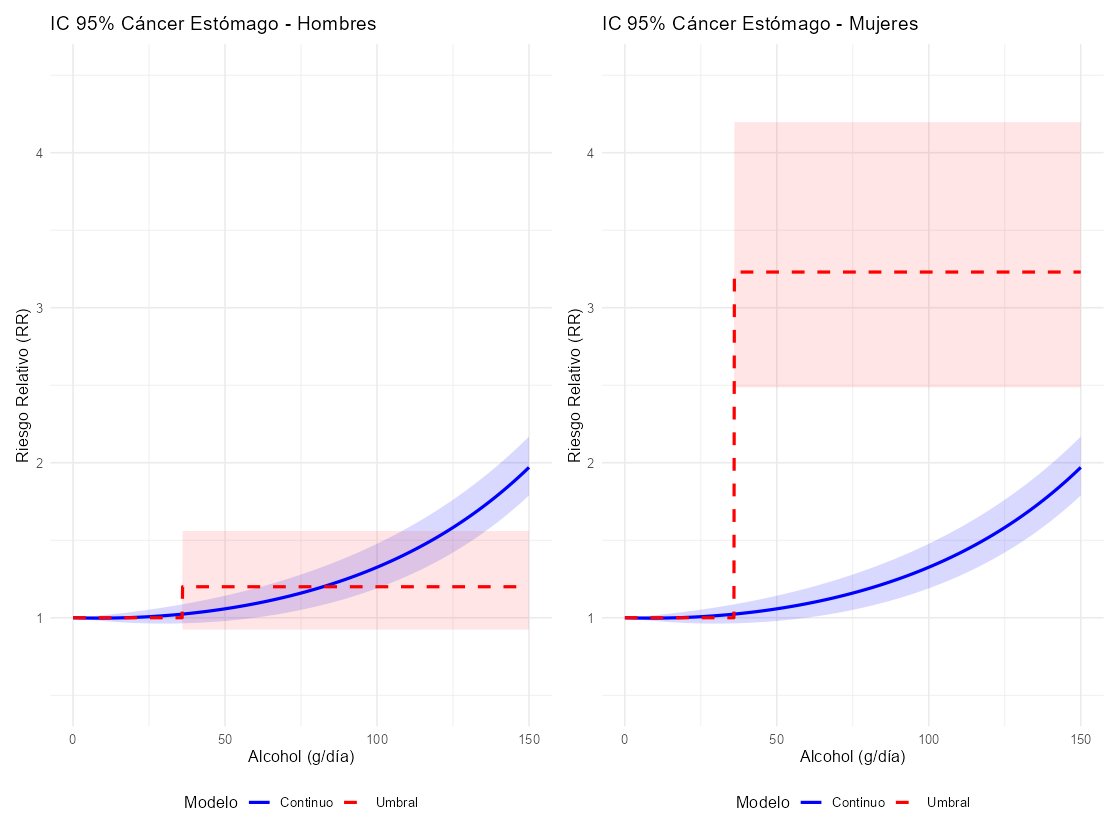

In [23]:
#| label: mort-trends-age-sex-chile27
#| results: "hold"

source(paste0(getwd(),"/stomach_stomach_diffs.R"))

plot_male + plot_female

### Results

We replicate the results of JRT [@ruiztagle2026sex] but with WHO 2024's AAFs [@who2025alcohol]. We also compared them with Sherk's 2016 report on cancer [@sherk2017intermahp].

#### Pop est

In [25]:
#| label: mort-trends-age-sex-chile16-std-pop-pre
#| results: "hold"

if(!file.exists(file.path(paste0(gsub("/__andres_control","",getwd())),
    "__andres_control",
    "ine_proyecciones_2012_2024.xlsx"))){
  # 2026-07-02= Build ine_proyecciones_2012-2024.xlsx
  # Replicates the structure of the project's ine_proyecciones.xlsx using
  # INE Chile proyeccion base 2024 data, but restricted to years 2012-2024.
  #
  # Source: INE Estimaciones y Proyecciones de Poblacion 1992-2070, base 2024
  # Useful tab: base-de-datos.xlsx -> "BBDD_EEPP-2024_0101"
  # Reference date used: 30 June (Poblacion al 30 de junio), demographically
  # conventional for rate denominators. Set reference_date = "01-01" for
  # January 1 stocks if preferred.
  # -----------------------------------------------------------------------------
  # 1. Settings
  # -----------------------------------------------------------------------------
  url_ine <- paste0(
    "https://www.ine.gob.cl/docs/default-source/proyecciones-de-poblacion/",
    "cuadros-estadisticos/proyecci%C3%B3n-base-2024/",
    "estimaciones-y-proyecciones-de-poblaci%C3%B3n-1992-2070_base-2024_base-de-datos.xlsx",
    "?sfvrsn=8e7df320_6"
  )
  src_file      <- "ine_basedatos.xlsx"    # downloaded INE file
  out_file      <- "ine_proyecciones_2012_2024.xlsx"
  first_year    <- 2012L
  last_year     <- 2024L
  reference_date <- "30-06"                # "30-06" (mid-year) or "01-01"
  # -----------------------------------------------------------------------------
  # 2. Download source if missing
  # -----------------------------------------------------------------------------
  if (!file.exists(src_file)) {
    message("Downloading INE base-de-datos file...")
    utils::download.file(url_ine, destfile = src_file, mode = "wb")
  }
  # -----------------------------------------------------------------------------
  # 3. Read long-format database
  # -----------------------------------------------------------------------------
  raw <- readxl::read_xlsx(src_file, sheet = "BBDD_EEPP-2024_0101")

  raw$year <- as.numeric(format(as.Date(raw$FECHA, format = "%d/%m/%Y"), "%Y"))
  raw$day_month <- format(as.Date(raw$FECHA, format = "%d/%m/%Y"), "%d-%m")
  # -----------------------------------------------------------------------------
  # 4. Filter reference date, years, and national level
  # -----------------------------------------------------------------------------
  df <- raw |>
    dplyr::filter(
      .data$NIVEL == "PAÍS",
      .data$day_month == reference_date,
      .data$year >= first_year,
      .data$year <= last_year
    )
  # -----------------------------------------------------------------------------
  # 5. Build one sex sheet
  # -----------------------------------------------------------------------------
  make_sex_sheet <- function(df_long, sex_code, sex_label) {
    out <- df_long |>
      dplyr::filter(.data$SEXO == sex_code) |>
      dplyr::select(edad = "EDAD", year = "year", poblacion = "POBLACION") |>
      tidyr::pivot_wider(
        names_from = "year",
        names_prefix = "ano_",
        values_from = "poblacion"
      ) |>
      dplyr::arrange(.data$edad)
    # Match the original file age labels: "0.0", "1.0", ..., "99.0", "100+"
    out <- out |>
      dplyr::mutate(
        edad = dplyr::if_else(.data$edad == 100L, "100+", paste0(.data$edad, ".0"))
      ) |>
      dplyr::relocate("edad")
    message("Built sheet '", sex_label, "': ", nrow(out), " rows x ", ncol(out), " cols")
    out
  }
  sheet_hombres <- make_sex_sheet(df, "H", "Hombres")
  sheet_mujeres <- make_sex_sheet(df, "M", "Mujeres")
  # -----------------------------------------------------------------------------
  # 6. Write Excel with same sheet names as the original
  # -----------------------------------------------------------------------------
  writexl::write_xlsx(
    list(Hombres = sheet_hombres, Mujeres = sheet_mujeres),
    path = out_file
  )
  message("Wrote ", out_file)
} else {
  message("Already created\n")
  # 2026-07-02= Import directly statistics from 2012-2024
  sheet_hombres <- readxl::read_xlsx(
    file.path(paste0(gsub("/__andres_control","",getwd())),
    "__andres_control",
    "ine_proyecciones_2012_2024.xlsx"), sheet = "Hombres") # male
    sheet_mujeres <- readxl::read_xlsx(
    file.path(paste0(gsub("/__andres_control","",getwd())),
    "__andres_control",
    "ine_proyecciones_2012_2024.xlsx"), sheet = "Mujeres") # female
}
# -----------------------------------------------------------------------------
# 7. Quick validation against original structure
# -----------------------------------------------------------------------------
orig <- readxl::read_xlsx(
  (paste0(gsub("/__andres_control","",getwd()),"/","ACC1240138-Potentially-Avoidable-Injury-Mortality-in-Chile--bc6359e/ine_proyecciones.xlsx")),
  sheet = 1
)
cat("\n**Validation:**\n")
cat("Original Hombres dimensions:", nrow(orig), "x", ncol(orig), "\n")
cat("New Hombres dimensions:", nrow(sheet_hombres), "x", ncol(sheet_mujeres), "\n")
cat("Expected rows (0-99 + 100+):", 101L, "\n")
cat("Years in new file:", paste(names(sheet_hombres)[-1], collapse = ", "), "\n")

Already created


**Validation:**
Original Hombres dimensions: 101 x 10 
New Hombres dimensions: 101 x 14 
Expected rows (0-99 + 100+): 101 
Years in new file: ano_2012, ano_2013, ano_2014, ano_2015, ano_2016, ano_2017, ano_2018, ano_2019, ano_2020, ano_2021, ano_2022, ano_2023, ano_2024 


In [26]:
#| label: mort-trends-age-sex-chile16-std-pop
#| results: "hold"

# 2026-06-01= spw_male & spw_fem: calculate pop = sum(tot) antes de filter(age_group > 0), 
# so pop includes <15 years old and adult weights of 4 groups sum ~0.74. 
# spw_tot: make bind_rows of spw_male/spw_fem 
# that have been already filtered >0, then pop = sum(tot): weights sum 1.
# So, it is corrected.
prep_pop_age <- function(dat) {
  dat |>
    dplyr::mutate(
      edad = as.numeric(ifelse(edad == "100+", 100, edad))) |> 
    # 2026-07-02 = Exclude population >=65
    dplyr::filter(edad <65) |> 
    dplyr::mutate(  
      age_group = dplyr::case_when(
        edad < 15 ~ 0L,
        dplyr::between(edad, 15, 29) ~ 1L,
        dplyr::between(edad, 30, 44) ~ 2L,
        dplyr::between(edad, 45, 59) ~ 3L,
        edad >= 60 ~ 4L
      )
    ) |>
    tidyr::pivot_longer(
      cols = tidyselect::starts_with("ano_"),
      names_to = "year",
      values_to = "value"
    ) |>
    dplyr::mutate(year = as.numeric(gsub("ano_", "", year))) |>
    dplyr::group_by(year, age_group) |>
    dplyr::summarise(tot = sum(value, na.rm = TRUE), .groups = "drop")
}
pop_male <- prep_pop_age(sheet_hombres)
pop_fem <- prep_pop_age(sheet_mujeres)
pop_tot <- dplyr::bind_rows(pop_male, pop_fem) |>
  dplyr::group_by(year, age_group) |>
  dplyr::summarise(tot = sum(tot, na.rm = TRUE), .groups = "drop")
make_chile2018_std <- function(pop_tot, adult_denominator = TRUE) {
  std0 <- pop_tot |> dplyr::filter(year == 2018)
  denom <- if (adult_denominator) {
    std0 |> dplyr::filter(age_group > 0) |> dplyr::summarise(n = sum(tot)) |> dplyr::pull(n)
  } else {
    std0 |> dplyr::summarise(n = sum(tot)) |> dplyr::pull(n)
  }
  std0 |>
    dplyr::filter(age_group > 0) |>
    dplyr::transmute(age_group, spw = tot / denom)
}

std_chile2018_15plus <- make_chile2018_std(pop_tot, adult_denominator = TRUE)
std_chile2018_all_age <- make_chile2018_std(pop_tot, adult_denominator = FALSE)
std_who_world_all_age <- tibble::tribble(
  ~age_group, ~spw,
  1L, (8.47 + 8.22 + 7.93) / 100,
  2L, (7.61 + 7.15 + 6.59) / 100,
  3L, (6.04 + 5.37 + 4.55) / 100,
  4L, 3.72 / 100   # 2026-07-02: 60-64 only (pipeline now capped edad_cant<65, not 60+)
)
# STANDARD POPULATION
# Choose ONE:
std_age <- std_chile2018_15plus      # 15+
# std_age <- std_chile2018_all_age   # all-ages Chile 2018
# std_age <- std_who_world_all_age   # comparison w/ WHO GHO all-ages
spw_male <- pop_male |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")
spw_fem <- pop_fem |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")
spw_tot <- pop_tot |>
  dplyr::filter(age_group > 0) |>
  dplyr::left_join(std_age, by = "age_group")

# 2026-07-02: population source (sheet_hombres/sheet_mujeres) only covers 2012-2024.
# Years present in mortality_results but absent from the population source are dropped
# from the standardized rate below (no denominator to standardize against for them).
discarded_years <- sort(setdiff(unique(mortality_results$year), unique(spw_tot$year)))
if (length(discarded_years) > 0) {
  message(
    "Standardized rates: discarding year(s) ", paste(discarded_years, collapse = ", "),
    " - no population data available (source covers 2012-2024 only)."
  )
}
# 2026-06-02= GPT complete version (w/ IC + NAs guard). Keep it as is.
# 2026-07-02= stop() on missing tot/spw replaced with a silent drop; the years this
# affects (2008, 2010) are already reported once above via `discarded_years`.
make_std_rate <- function(dat, pop_df, group_label) {
  joined <- dat |>
    dplyr::group_by(year, age_group) |>
    dplyr::summarise(
      mort = sum(mort, na.rm = TRUE),
      ll_mort = sum(ll_mort, na.rm = TRUE),
      up_mort = sum(up_mort, na.rm = TRUE),
      .groups = "drop"
    ) |>
    dplyr::left_join(
      pop_df |> dplyr::ungroup() |> dplyr::select(year, age_group, tot, spw),
      by = c("year", "age_group")
    ) |>
    dplyr::filter(!is.na(tot), !is.na(spw))

  joined |>
    dplyr::mutate(
      mort_rate    = mort    / tot * 100000,
      ll_mort_rate = ll_mort / tot * 100000,
      up_mort_rate = up_mort / tot * 100000
    ) |>
    dplyr::group_by(year) |>
    dplyr::summarise(
      std_mort_rate    = sum(mort_rate * spw),
      ll_std_mort_rate = sum(ll_mort_rate * spw),
      up_std_mort_rate = sum(up_mort_rate * spw),
      .groups = "drop"
    ) |>
    dplyr::mutate(gender = group_label) # to match Figure 1 ENG labels
}
# Watch out for the labels: Figure 1 keys are in "Male"/"Female"/"Total".
# Filter is in spanish (mortality gender = "Hombre"/"Mujer"),
# but output label should be in english so they can match.
std_rates <- dplyr::bind_rows(
  make_std_rate(mortality_results,                                    spw_tot,  "Total"),
  make_std_rate(mortality_results |> dplyr::filter(gender == "Hombre"), spw_male, "Male"),
  make_std_rate(mortality_results |> dplyr::filter(gender == "Mujer"),  spw_fem,  "Female")
)
# to avoid touching figure 1. use the same expected name 
combined_results <- std_rates |> dplyr::filter(year%%2==0)
combined_results |> 
knitr::kable("markdown", caption= "Standardized population")

Standardized rates: discarding year(s) 2008, 2009, 2010, 2011 - no population data available (source covers 2012-2024 only).




Table: Standardized population

| year| std_mort_rate| ll_std_mort_rate| up_std_mort_rate|gender |
|----:|-------------:|----------------:|----------------:|:------|
| 2012|     25.794404|        14.043654|         38.30623|Total  |
| 2014|     25.562772|        13.648296|         38.02246|Total  |
| 2016|     24.897943|        12.772874|         37.56841|Total  |
| 2018|     23.437460|        12.015396|         35.05601|Total  |
| 2020|     24.358321|        13.407497|         35.59148|Total  |
| 2022|     24.821901|        13.329674|         36.98252|Total  |
| 2024|     19.182476|         9.669946|         29.75852|Total  |
| 2012|     44.690141|        25.288835|         64.84576|Male   |
| 2014|     43.895347|        24.460051|         63.70725|Male   |
| 2016|     41.560094|        22.319565|         61.35103|Male   |
| 2018|     38.953618|        20.978354|         56.86140|Male   |
| 2020|     40.867558|        23.362877|         58.37575|Male   |
| 2022|     42.495436|      

In [27]:
#| label: mort-trends-age-sex-chile16b-std-pop
#| results: "hold"
dplyr::bind_rows(
  spw_tot |> dplyr::group_by(year) |> dplyr::summarise(group = "Total", sum_spw = sum(spw), .groups = "drop"),
  spw_male |> dplyr::group_by(year) |> dplyr::summarise(group = "Hombre", sum_spw = sum(spw), .groups = "drop"),
  spw_fem |> dplyr::group_by(year) |> dplyr::summarise(group = "Mujer", sum_spw = sum(spw), .groups = "drop")
) |>
  dplyr::group_by(group) |>
  dplyr::summarise(min_sum = min(sum_spw), max_sum = max(sum_spw), .groups = "drop") |> 
  print()
# --- VALIDATE the standard (not only min==max: expected value) ---
expected_sum <- 1.0   # std_chile2018_15plus sum 1.0 through 15+
                      # (if we change to all-ages/WHO, use 0.4183, as of 2026-07-02, restricting >=65)
check_spw <- dplyr::bind_rows(
  spw_tot  |> dplyr::group_by(year) |> dplyr::summarise(group = "Total",  sum_spw = sum(spw), .groups = "drop"),
  spw_male |> dplyr::group_by(year) |> dplyr::summarise(group = "Hombre", sum_spw = sum(spw), .groups = "drop"),
  spw_fem  |> dplyr::group_by(year) |> dplyr::summarise(group = "Mujer",  sum_spw = sum(spw), .groups = "drop")
)
# 1) no NA (left_join(std_age) doesnt fail and no age_group is missing)
if (any(is.na(check_spw$sum_spw)))
  stop("spw with NA: left_join(std_age) failed or an age group was missing in pop_* database.")
# 2) all three groups, every year, sum exactly the chosen standard
if (!all(abs(check_spw$sum_spw - expected_sum) < 1e-6))
  stop(sprintf("spw does not sum %.5f in an age.group (observed range [%.5f, %.5f]). Check std_age.",
               expected_sum, min(check_spw$sum_spw), max(check_spw$sum_spw)))
# 3) confirmed that std_age is the one im using
if (abs(sum(std_age$spw) - expected_sum) >= 1e-6)
  stop(sprintf("std_age sums %.5f, and expected %.5f. Did you take std_chile2018_15plus?",
               sum(std_age$spw), expected_sum))
cat(sprintf("OK standardization: spw = %.4f in %d age group (std_age = std_chile2018_15plus).\n",
            expected_sum, nrow(check_spw)))

# A tibble: 3 × 3
  group  min_sum max_sum
  <chr>    <dbl>   <dbl>
1 Hombre       1       1
2 Mujer        1       1
3 Total        1       1
OK standardization: spw = 1.0000 in 39 age group (std_age = std_chile2018_15plus).


### Comparison with Cancer AAF (JRT)

We built a comparable table, by including Pancreatic and Stomach cancer, that I included once, but then I ended leaving them out because Shield et al 2025 did not consider them in their pipeline. Then, we aggregated data by year, gender and age group to obtain the alcohol attributable for each cancer.

In [52]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-1pre
#| results: "hold"

cancer_name_map <- c(
  "Breast Cancer" = "Breast Cancer",
  "Colon and rectum Cancer" = "Colorectal Cancer",   # naming differs between the two sources
  "Larynx Cancer" = "Larynx Cancer",
  "Liver Cancer" = "Liver Cancer",
  "Oesophagus Cancer" = "Oesophagus Cancer",
  "Oral Cavity and Pharynx Cancer" = "Oral Cavity and Pharynx Cancer",
  "Pancreatic Cancer" = "Pancreatic Cancer",
  "Stomach Cancer" = "Stomach Cancer"
)
age_group_lbl <- c(`1` = "15-29", `2` = "30-44", `3` = "45-59", `4` = "60+")
sex_lbl <- c(Mujer = "Female", Hombre = "Male")

pipeline_cancer <- purrr::imap_dfr(disease_filters[names(cancer_name_map)], function(filter_info, disease_name) {
  filter_col <- filter_info$filter_col
  purrr::map_dfr(filter_info$genders, function(gender_i) {
    def |>
      dplyr::filter(gender == gender_i, year %in% unique(aaf_long$year)) |>
      dplyr::group_by(year, gender, age_group) |>
      dplyr::summarise(n = sum(.data[[filter_col]] == 1, na.rm = TRUE), .groups = "drop") |>
      dplyr::left_join(
        aaf_long |>
          dplyr::filter(disease == disease_name, gender == gender_i) |>
          dplyr::distinct(year, age_group, gender, disease, .keep_all = TRUE),
        by = c("year", "age_group", "gender")
      ) |>
      dplyr::transmute(
        Year = year,
        disease = cancer_name_map[[disease_name]],
        sex = sex_lbl[gender],
        age_group = age_group_lbl[as.character(age_group)],
        AAF = point, LL = lower, UL = upper,
        muertes = n,
        att_mort = round(point * n),
        att_mort_low = round(lower * n),
        att_mort_up = round(upper * n)
      )
  })
}) |>
  dplyr::filter(!is.na(AAF))

In [53]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-1
#| results: "hold"

pipeline_cancer_rounded <- pipeline_cancer |>
  #round to 4 decimals
  dplyr::mutate(dplyr::across(dplyr::matches("AAF|LL|UL"), ~ round(.x, 4)))
html_table <- tags$div(
  style = "max-height: 350px; overflow-y: auto;",
  tags$style(HTML("
    .simple-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
    .simple-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.3em; }
    .simple-table th, .simple-table td { padding: 0.1em 0.3em; text-align: left; border-bottom: 1px solid #ccc; }
    .simple-table th { border-bottom: 1.5px solid #333; }
    .simple-table .num { text-align: right; }
    /* scroll box */
    .scroll-box { max-height: 350px; overflow-y: auto; }
  ")),
  tags$table(
    class = "simple-table",
    tags$caption("Pipeline cancer estimates"),
    tags$thead(
      tags$tr(lapply(names(pipeline_cancer_rounded), tags$th))
    ),
    tags$tbody(
      lapply(seq_len(nrow(pipeline_cancer_rounded)), function(i) {
        row <- pipeline_cancer_rounded[i, ]
        tags$tr(
          lapply(seq_along(row), function(j) {
            val <- row[[j]]
            if (is.numeric(val)) {
              tags$td(class = "num", format(val, trim = TRUE))
            } else {
              tags$td(as.character(val))
            }
          })
        )
      })
    )
  )
)
htmltools::browsable(html_table)

Year,disease,sex,age_group,AAF,LL,UL,muertes,att_mort,att_mort_low,att_mort_up
2012,Breast Cancer,Female,15-29,0.0326,0.0267,0.0389,3,0,0,0
2012,Breast Cancer,Female,30-44,0.0238,0.0194,0.0285,116,3,2,3
2012,Breast Cancer,Female,45-59,0.0217,0.0177,0.0263,372,8,7,10
2012,Breast Cancer,Female,60+,0.017,0.0127,0.0218,142,2,2,3
2014,Breast Cancer,Female,15-29,0.0416,0.0344,0.0488,6,0,0,0
2014,Breast Cancer,Female,30-44,0.0375,0.0311,0.0442,122,5,4,5
2014,Breast Cancer,Female,45-59,0.0338,0.0277,0.0404,393,13,11,16
2014,Breast Cancer,Female,60+,0.0263,0.0201,0.0331,126,3,3,4
2016,Breast Cancer,Female,15-29,0.0388,0.032,0.0458,4,0,0,0
2016,Breast Cancer,Female,30-44,0.0322,0.0265,0.0383,114,4,3,4


In [ ]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-2-aaf's
#| results: "hold"

ref_cancer <- readr::read_tsv(
    file.path(gsub("__andres_control","",getwd()),
    #"__andres_control",
    "JRT_20260702_cancer",
    "Alcohol Attributable mortality (CANCER).txt"),
  locale = readr::locale(decimal_mark = ","),   # file uses comma decimals
  col_types = readr::cols()
)
cancer_compare <- pipeline_cancer |>
  dplyr::full_join(
    ref_cancer,
    by = c("Year", "disease", "sex", "age_group"),
    suffix = c("_pipeline", "_jrt")
  ) |>
  dplyr::mutate(
    diff_AAF      = AAF_pipeline - AAF_jrt,
    diff_muertes  = muertes_pipeline - muertes_jrt,
    diff_att_mort = att_mort_pipeline - att_mort_jrt
  ) |>
  dplyr::arrange(disease, Year, sex, age_group)

# rows present on only one side (full_join, so NA marks a gap on either side)
only_one_side <- cancer_compare |> 
  dplyr::filter(is.na(AAF_pipeline) | is.na(AAF_jrt)) |>
  dplyr::select(Year, disease, sex, age_group, AAF_pipeline, AAF_jrt, diff_AAF) |>
  dplyr::mutate(dplyr::across(dplyr::everything(), ~ tidyr::replace_na(as.character(.x), "NA")))
caption_html <- htmltools::tags$p(
  style = "font-family: Arial, sans-serif; font-size: 0.95em; font-weight: bold; margin-bottom: 0.3em;",
  "Rows present on only one side",
  htmltools::tags$br(),
  htmltools::tags$span(
    style = "font-weight: normal; font-size: 0.9em;",
    "NA indicates a missing match after the full_join between pipeline and JRT estimates."
  )
)
tbl <- knitr::kable(
  only_one_side,
  format = "html",
  table.attr = "style='border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; border: 1px solid #ccc;'"
)
htmltools::browsable(
  htmltools::tags$div(
    caption_html,
    htmltools::HTML(tbl)
  )
)

Year,disease,sex,age_group,AAF_pipeline,AAF_jrt,diff_AAF


In [66]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-2-aaf-2
#| results: "hold"

# where AAF diverges most - expected to be nonzero everywhere: different RR source
top_aaf <- cancer_compare |>
  dplyr::arrange(dplyr::desc(abs(diff_AAF))) |>
  # dplyr::mutate(
  #   AAF_pipeline_fmt = sprintf("%.3f", AAF_pipeline),
  #   AAF_jrt_fmt      = sprintf("%.3f", AAF_jrt),
  #   diff_AAF_fmt     = sprintf("%.3f", diff_AAF)
  # ) |>
  dplyr::mutate(dplyr::across(dplyr::matches("AAF_pipeline|AAF_jrt|diff_AAF"), ~ round(.x, 4))) |> 
  dplyr::select(Year, disease, sex, age_group, AAF_pipeline, AAF_jrt, diff_AAF) |>
  head(30)
caption <- tags$caption(
  "Top 30 AAF divergences between pipeline and JRT estimates",
  tags$br(),
  tags$span("AAF differences are expected because the two estimates use different RR sources.")
)
# helper to build a row from a vector of cell contents
make_row <- function(cells, tag = tags$td) {
  tags$tr(lapply(cells, function(x) tag(x)))
}
aaf_table <- tags$div(
  style = "max-height: 350px; overflow-y: auto;",
  tags$style(HTML("
    .aaf-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
    .aaf-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.5em; }
    .aaf-table caption span { font-weight: normal; font-size: 0.9em; }
    .aaf-table th, .aaf-table td { padding: 0.3em 0.6em; text-align: left; }
    .aaf-table th { border-bottom: 1px solid black; }
    .aaf-table .num { text-align: right; }
    /* scroll box */
    .scroll-box { max-height: 350px; overflow-y: auto; }      
  ")),
  tags$table(
    class = "aaf-table",
    caption,
    tags$thead(
      tags$tr(
        tags$th("Year"),
        tags$th("Disease"),
        tags$th("Sex"),
        tags$th("Age group"),
        tags$th(class = "num", "AAF pipeline"),
        tags$th(class = "num", "AAF JRT"),
        tags$th(class = "num", "Difference")
      )
    ),
    tags$tbody(
      lapply(seq_len(nrow(top_aaf)), function(i) {
        tags$tr(
          tags$td(top_aaf$Year[i]),
          tags$td(top_aaf$disease[i]),
          tags$td(top_aaf$sex[i]),
          tags$td(top_aaf$age_group[i]),
          tags$td(class = "num", top_aaf$AAF_pipeline[i]),
          tags$td(class = "num", top_aaf$AAF_jrt[i]),
          tags$td(class = "num", top_aaf$diff_AAF[i])
        )
      })
    )
  )
)
htmltools::browsable(aaf_table)

Year,Disease,Sex,Age group,AAF pipeline,AAF JRT,Difference
2024,Liver Cancer,Female,60+,0.2572,0.438,-0.1808
2022,Liver Cancer,Female,60+,0.2597,0.438,-0.1783
2020,Liver Cancer,Female,60+,0.2711,0.449,-0.1779
2022,Liver Cancer,Female,45-59,0.2714,0.439,-0.1676
2022,Liver Cancer,Male,60+,0.2116,0.369,-0.1574
2020,Liver Cancer,Female,30-44,0.2529,0.407,-0.1541
2024,Liver Cancer,Male,60+,0.2301,0.382,-0.1519
2012,Liver Cancer,Female,60+,0.2072,0.359,-0.1518
2016,Liver Cancer,Female,60+,0.2703,0.421,-0.1507
2020,Liver Cancer,Female,45-59,0.2823,0.429,-0.1467


In [61]:
diseases_not_available <- cancer_compare |>
  dplyr::filter(is.na(AAF_pipeline) | is.na(AAF_jrt)) |>
  dplyr::distinct(disease) |>
  dplyr::pull()
paste0("Diseases with at least one unmatched row: ", paste(diseases_not_available, collapse = ", "))


[1] "Diseases with at least one unmatched row: "

In [62]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-3-deaths
#| results: "hold"

# raw mortality COUNT check - this is the more diagnostic one: both sides should be
# counting the same national ICD-coded deaths, so muertes shouldn't diverge much
# unless there's an ICD-range or de-duplication mismatch (see the paper-duplication
# bug found earlier for this same project)
top_diffs <- cancer_compare |>
  dplyr::filter(abs(diff_muertes) > 0) |>
  dplyr::select(
    Year, disease, sex, age_group,
    muertes_pipeline, muertes_jrt, diff_muertes
  ) |>
  dplyr::arrange(dplyr::desc(abs(diff_muertes)))

html_table <- tags$div(
  style = "max-height: 350px; overflow-y: auto;",
  tags$style(HTML("
    .cmp-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
    .cmp-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.5em; }
    .cmp-table caption span { font-weight: normal; font-size: 0.9em; }
    .cmp-table th, .cmp-table td { padding: 0.3em 0.6em; text-align: left; border-bottom: 1px solid #ccc; }
    .cmp-table th { border-bottom: 2px solid #333; }
    .cmp-table .num { text-align: right; }
    /* scroll box */
    .scroll-box { max-height: 350px; overflow-y: auto; }  
  ")),
  tags$table(
    class = "cmp-table",
    tags$caption(
      "Cancer mortality count discrepancies between pipeline and JRT estimates",
      tags$br(),
      tags$span(
        "Rows with non-zero differences in attributable deaths; ordered by absolute difference. ",
        "Diagnostic check: both sides should be counting the same national ICD-coded deaths. ",
        "Large divergences point to ICD-range or de-duplication mismatches."
      )
    ),
    tags$thead(
      tags$tr(
        tags$th("Year"),
        tags$th("Disease"),
        tags$th("Sex"),
        tags$th("Age group"),
        tags$th(class = "num", "Pipeline deaths"),
        tags$th(class = "num", "JRT deaths"),
        tags$th(class = "num", "Difference")
      )
    ),
    tags$tbody(
      lapply(seq_len(nrow(top_diffs)), function(i) {
        row <- top_diffs[i, ]
        tags$tr(
          tags$td(row$Year),
          tags$td(row$disease),
          tags$td(row$sex),
          tags$td(row$age_group),
          tags$td(class = "num", row$muertes_pipeline),
          tags$td(class = "num", row$muertes_jrt),
          tags$td(class = "num", row$diff_muertes)
        )
      })
    )
  )
)
htmltools::browsable(html_table)

Year,Disease,Sex,Age group,Pipeline deaths,JRT deaths,Difference
2014,Stomach Cancer,Male,60+,243,1790,-1547
2012,Stomach Cancer,Male,60+,236,1777,-1541
2022,Stomach Cancer,Male,60+,237,1751,-1514
2020,Stomach Cancer,Male,60+,248,1758,-1510
2018,Stomach Cancer,Male,60+,270,1760,-1490
2016,Stomach Cancer,Male,60+,267,1754,-1487
2024,Stomach Cancer,Male,60+,235,1721,-1486
2024,Colorectal Cancer,Female,60+,154,1590,-1436
2024,Colorectal Cancer,Male,60+,245,1657,-1412
2022,Colorectal Cancer,Male,60+,205,1457,-1252



The cancer comparison was rebuilt using a JRT-compatible mortality table generated by `__andres_control/make_jrt_compatible_cancer_table_ge60.R`.

The script does not modify the notebook or the original pipeline objects. It reads JRT's reference file, uses its row structure as the comparison template, and rebuilds our cancer mortality table from the raw DEIS mortality files. The main correction is that the `60+` age group is defined as all deaths occurring at age 60 or older, rather than the restricted `60-64` subset that had entered the shared notebook mortality object after the `edad_cant < 65` filter.
To make the mortality counts comparable with JRT, the script also harmonizes the ICD grouping used in the reference table. `Colorectal Cancer` is counted as `C18-C21`, which matches JRT's counts. `Oral Cavity and Pharynx Cancer` combines the local oral-cavity and other-pharyngeal components into one JRT-compatible category. Attributable deaths are then recomputed using our WHO 2024 AAF estimates and the harmonized mortality counts.
After this rebuild, the raw mortality counts match JRT exactly across the comparable cancer table, including the `60+` age group. Remaining differences in attributable deaths reflect differences in the AAF estimates, not differences in the underlying mortality counts.

In [2]:
cancer_compare_comparable

# A tibble: 105 × 21
    Year disease           sex    age_group AAF_pipeline LL_pipeline UL_pipeline muertes_pipeline att_mort_pipeline att_mort_low_pipeline att_mort_up_pipeline AAF_jrt LL_jrt UL_jrt muertes_jrt att_mort_jrt
   <dbl> <chr>             <chr>  <chr>            <dbl>       <dbl>       <dbl>            <dbl>             <dbl>                 <dbl>                <dbl>   <dbl>  <dbl>  <dbl>       <dbl>        <dbl>
 1  2012 Breast Cancer     Female 60+               0.02        0.01        0.02              876                18                     9                   18   0.014  0.01   0.017         876           12
 2  2014 Breast Cancer     Female 60+               0.03        0.02        0.03              901                27                    18                   27   0.021  0.017  0.026         901           19
 3  2016 Breast Cancer     Female 60+               0.02        0.02        0.03              957                19                    19                  

In [ ]:
#| label: mort-trends-age-sex-chile17-cancer-4-comparable-comparison
#| results: "hold"

.t0 <- Sys.time()

cancer_compare_comparable <- readr::read_csv(
      file.path(gsub("__andres_control","",getwd()),
    #"__andres_control",
    "JRT_20260702_cancer",
    "pipeline_vs_jrt_cancer_60plus.csv"),
  show_col_types = FALSE
)
top_diffs <- cancer_compare_comparable |>
  dplyr::filter(abs(diff_muertes) > 0) |>
  dplyr::select(
    Year, disease, sex, age_group,
    muertes_pipeline, muertes_jrt, diff_muertes
  ) |>
  dplyr::arrange(dplyr::desc(abs(diff_muertes)))

if (nrow(top_diffs) == 0) {
  html_table <- htmltools::tags$div(
    htmltools::tags$style(htmltools::HTML("
      .cmp-note { font-family: Arial, sans-serif; font-size: 0.95em; }
      .cmp-note strong { font-weight: bold; }
    ")),
    htmltools::tags$p(
      class = "cmp-note",
      htmltools::tags$strong("Cancer mortality count check: PASS. "),
      "After rebuilding the JRT-compatible table with age 60+ defined as age >= 60, ",
      "pipeline and JRT mortality counts match exactly for all comparable 60+ cancer rows. ",
      "Remaining attributable-mortality differences therefore reflect AAF differences, not mortality-count mismatches."
    )
  )
} else {
  html_table <- htmltools::tags$div(
    htmltools::tags$style(htmltools::HTML("
      .cmp-table { border-collapse: collapse; font-family: Arial, sans-serif; font-size: 0.9em; }
      .cmp-table caption { caption-side: top; text-align: left; font-weight: bold; margin-bottom: 0.5em; }
      .cmp-table caption span { font-weight: normal; font-size: 0.9em; }
      .cmp-table th, .cmp-table td { padding: 0.3em 0.6em; text-align: left; border-bottom: 1px solid #ccc; }
      .cmp-table th { border-bottom: 2px solid #333; }
      .cmp-table .num { text-align: right; }
    ")),
    htmltools::tags$table(
      class = "cmp-table",
      htmltools::tags$caption(
        "Cancer mortality count discrepancies between pipeline and JRT estimates",
        htmltools::tags$br(),
        htmltools::tags$span(
          "Rows with non-zero differences in raw mortality counts; ordered by absolute difference. ",
          "Diagnostic check: both sides should count the same national ICD-coded deaths."
        )
      ),
      htmltools::tags$thead(
        htmltools::tags$tr(
          htmltools::tags$th("Year"),
          htmltools::tags$th("Disease"),
          htmltools::tags$th("Sex"),
          htmltools::tags$th("Age group"),
          htmltools::tags$th(class = "num", "Pipeline deaths"),
          htmltools::tags$th(class = "num", "JRT deaths"),
          htmltools::tags$th(class = "num", "Difference")
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(top_diffs)), function(i) {
          row <- top_diffs[i, ]
          htmltools::tags$tr(
            htmltools::tags$td(row$Year),
            htmltools::tags$td(row$disease),
            htmltools::tags$td(row$sex),
            htmltools::tags$td(row$age_group),
            htmltools::tags$td(class = "num", row$muertes_pipeline),
            htmltools::tags$td(class = "num", row$muertes_jrt),
            htmltools::tags$td(class = "num", row$diff_muertes)
          )
        })
      )
    )
  )
}
htmltools::browsable(html_table)

message(sprintf(
  "[%.2f min] Reading JRT-compatible cancer comparison outputs.",
  as.numeric(difftime(Sys.time(), .t0, units = "mins"))
))

<R HTML widget HTML Widget>

[0.01 min] Reading JRT-compatible cancer comparison outputs.


#### Figure 1

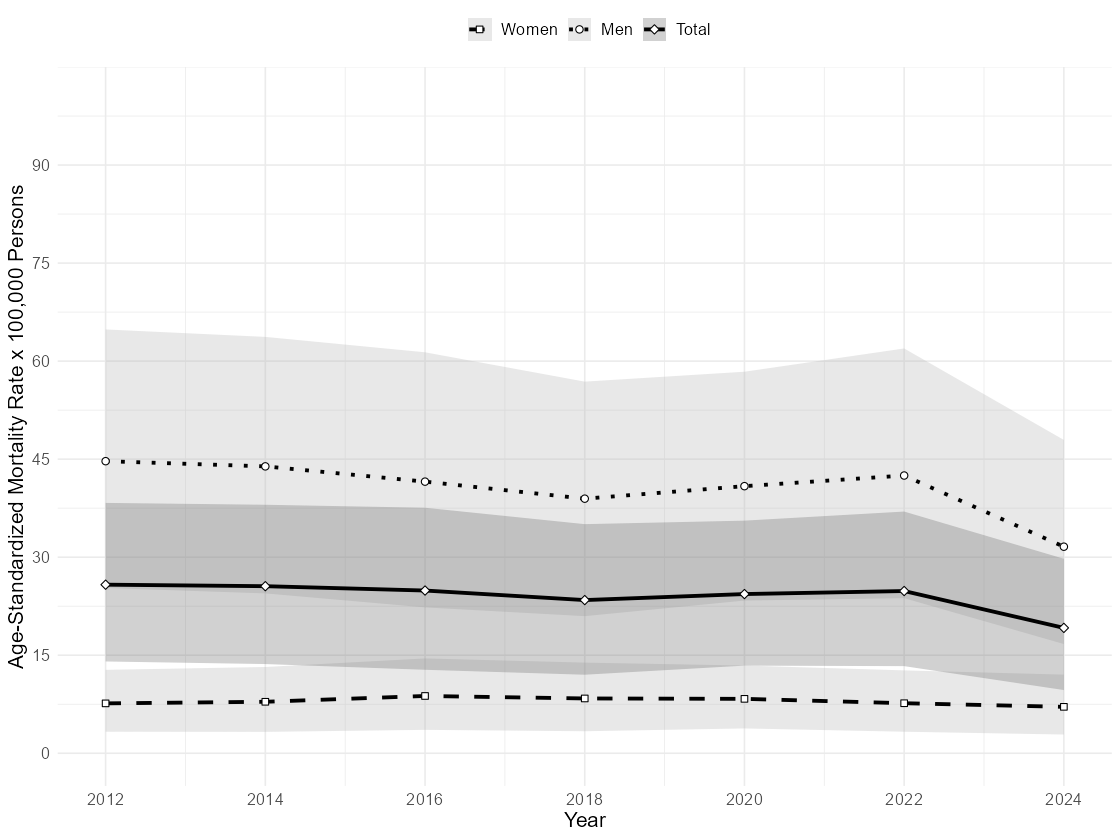

In [71]:
#| label: mort-trends-age-sex-chile17-fig1
#| results: "hold"

# Plot the unified figure
ggplot(combined_results, aes(x = year, y = std_mort_rate, linetype = gender, fill = gender)) +
  # Confidence interval ribbons
  geom_ribbon(
    aes(ymin = ll_std_mort_rate, ymax = up_std_mort_rate, fill = gender),
    alpha = 0.3, color = NA
  ) +
  # Lines for age-standardized mortality
  geom_line(
    aes(linetype = gender),
    linewidth = 1.2, color = "black"
  ) +
  # Points for age-standardized mortality
  geom_point(
    aes(shape = gender),
    size = 2, color = "black", fill = "white"
  ) +
  # Customize scales and labels
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    labels = c(2012, 2014, 2016, 2018, 2020, 2022, 2024)
  ) +
  scale_y_continuous(breaks = seq(0, 100, 15)) +
  coord_cartesian(ylim = c(0, 100)) +
  labs(
    x = "Year",
    y = "Age-Standardized Mortality Rate x 100,000 Persons",
    linetype = "",
    fill = "",
    shape = ""
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top",
    legend.key = element_blank()  # Remove background in legend
  ) +
  # Customize linetypes, fill colors, and shapes for Total and genders
  scale_linetype_manual(
    values = c("Male" = "dotted", "Female" = "dashed", "Total" = "solid"),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Male" = "gray70", "Female" = "gray70", "Total" = "gray40"),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Male" = 21, "Female" = 22, "Total" = 23),
    labels = c("Male" = "Men", "Female" = "Women", "Total" = "Total")
  )

fig1 <-
  ggplot(combined_results, aes(x = year, group = gender)) +
  geom_ribbon(
    aes(ymin = ll_std_mort_rate, ymax = up_std_mort_rate, fill = gender),
    alpha = 0.38,
    color = NA
  ) +
  geom_line(
    aes(y = std_mort_rate, linetype = gender),
    linewidth = 1.15,
    color = "black"
  ) +
  geom_point(
    aes(y = std_mort_rate, shape = gender),
    size = 2.6,
    color = "black",
    fill = "white",
    stroke = 0.85
  ) +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    expand = expansion(mult = c(0.01, 0.03))
  ) +
  scale_y_continuous(
    breaks = seq(0, 100, 15),
    expand = expansion(mult = c(0.01, 0.04))
  ) +
  coord_cartesian(ylim = c(0, 100)) +
  scale_linetype_manual(
    values = c("Female" = "dashed", "Male" = "dotted", "Total" = "solid"),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Female" = 22, "Male" = 21, "Total" = 23),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Female" = "grey82", "Male" = "grey82", "Total" = "grey55"),
    labels = c("Female" = "Women", "Male" = "Men", "Total" = "Total")
  ) +
  labs(
    x = "Year",
    y = "Age-Standardized Mortality Rate x 100,000 Persons",
    linetype = NULL,
    shape = NULL,
    fill = NULL
  ) +
  guides(
    fill = "none",
    linetype = guide_legend(nrow = 1),
    shape = guide_legend(nrow = 1)
  ) +
  theme_minimal(base_size = 17) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.text = element_text(size = 16),
    legend.key = element_rect(fill = "grey82", color = NA),
    legend.key.width = unit(0.95, "cm"),
    legend.spacing.x = unit(0.25, "cm"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 15),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3),
    plot.margin = margin(8, 12, 8, 12)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 1.png"
  ),
  plot = fig1,
  width = 5.52,
  height = 7.11,
  units = "in",
  dpi = 300,
  bg = "white"
)

In [72]:
#| label: mort-trends-age-sex-chile18-fig2-pre
#| results: "hold"

death_sex <- def %>%
  group_by(year, gender) %>%
  summarise(n = n(), .groups = "drop")

tot_death <- def %>%
  group_by(year) %>%
  summarise(n = n(), .groups = "drop")

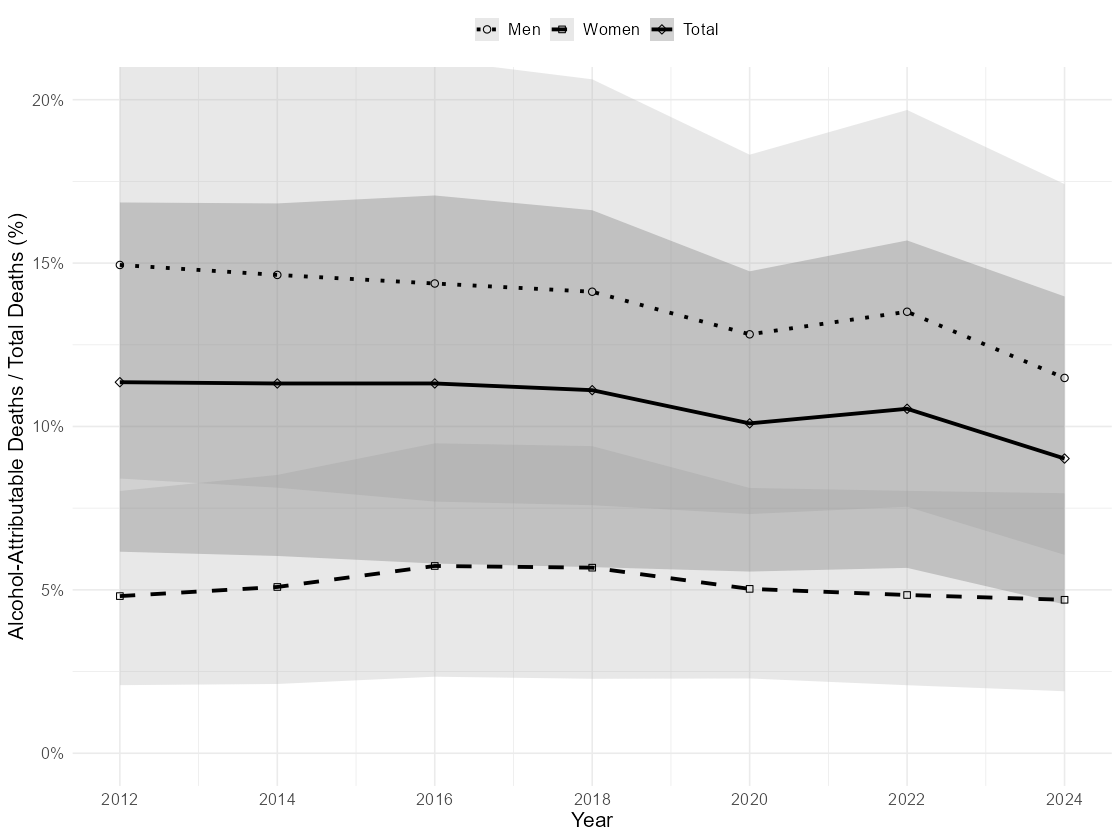

In [ ]:
#| label: mort-trends-age-sex-chile18-fig2
#| results: "hold"

# 1. Ajustar los cÃ¡lculos para convertir a porcentaje (multiplicar por 100)
gender_data <- mortality_results %>% 
  group_by(year, gender) %>% 
  summarise(
    mort = sum(mort),
    ll_mort = sum(ll_mort),
    up_mort = sum(up_mort),
    .groups = "drop"
  ) %>% 
  left_join(death_sex, by = c("year", "gender")) %>% 
  mutate(
    prop = (mort / n) * 100,      # Multiplicado por 100
    ll_prop = (ll_mort / n) * 100,
    up_prop = (up_mort / n) * 100
  )
total_data <- mortality_results %>% 
  group_by(year) %>% 
  summarise(
    mort = sum(mort),
    ll_mort = sum(ll_mort),
    up_mort = sum(up_mort),
    .groups = "drop"
  ) %>% 
  left_join(tot_death, by = "year") %>% 
  mutate(
    prop = (mort / n) * 100,      # Multiplicado por 100
    ll_prop = (ll_mort / n) * 100,
    up_prop = (up_mort / n) * 100
  ) %>% 
  mutate(gender = "Total")
combined_data <- bind_rows(gender_data, total_data) |>
        dplyr::filter(year %% 2==0, year>=2012)

# 2. Ajustar el grÃ¡fico
ggplot(combined_data) +
  geom_ribbon(
    aes(x = year, ymin = ll_prop, ymax = up_prop, fill = gender),
    alpha = 0.3, color = NA
  ) +
  geom_line(
    aes(x = year, y = prop, linetype = gender),
    color = "black", linewidth = 1.2 # Se recomienda usar linewidth en versiones recientes
  ) +
  geom_point(
    aes(x = year, y = prop, shape = gender),
    color = "black", size = 2
  ) +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2)
  ) +
  # Ajustar escala Y de 0 a 20 (que representa 0% a 20%)
  scale_y_continuous(
    breaks = seq(0, 20, 5),
    labels = function(x) paste0(x, "%")
  ) +
  coord_cartesian(ylim = c(0, 20)) +
  labs(
    x = "Year",
    y = "Alcohol-Attributable Deaths / Total Deaths (%)",
    linetype = "",
    shape = "",
    fill = ""
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top"
  ) +
  scale_linetype_manual(
    values = c("Hombre" = "dotted", "Mujer" = "dashed", "Total" = "solid"),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Hombre" = "gray70", "Mujer" = "gray70", "Total" = "gray40"),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Hombre" = 21, "Mujer" = 22, "Total" = 23),
    labels = c("Hombre" = "Men", "Mujer" = "Women", "Total" = "Total")
  )

combined_data <- bind_rows(gender_data, total_data) |> 
  dplyr::filter(year %% 2==0, year>=2012) |> 
  dplyr::mutate(gender = factor(gender, levels = c("Mujer", "Hombre", "Total")))

fig2 <- ggplot(combined_data, aes(x = year, group = gender)) +
  geom_ribbon(
    aes(ymin = ll_prop, ymax = up_prop, fill = gender),
    alpha = 0.38,
    color = NA
  ) +
  geom_line(
    aes(y = prop, linetype = gender),
    color = "black",
    linewidth = 1.15
  ) +
  geom_point(
    aes(y = prop, shape = gender),
    color = "black",
    fill = "white",
    size = 2.6,
    stroke = 0.85
  ) +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2),
    expand = expansion(mult = c(0.01, 0.03))
  ) +
  scale_y_continuous(
    breaks = seq(5, 25, 5),
    labels = function(x) paste0(x, "%"),
    expand = expansion(mult = c(0.01, 0.04))
  ) +
  #coord_cartesian(ylim = c(5, 25.8)) +
  scale_linetype_manual(
    values = c("Mujer" = "dashed", "Hombre" = "dotted", "Total" = "solid"),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  scale_shape_manual(
    values = c("Mujer" = 22, "Hombre" = 21, "Total" = 23),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  scale_fill_manual(
    values = c("Mujer" = "grey82", "Hombre" = "grey82", "Total" = "grey55"),
    labels = c("Mujer" = "Women", "Hombre" = "Men", "Total" = "Total")
  ) +
  labs(
    x = "Year",
    y = "Alcohol-Attributable Deaths / Total Deaths",
    linetype = NULL,
    shape = NULL,
    fill = NULL
  ) +
  guides(
    fill = "none",
    linetype = guide_legend(nrow = 1),
    shape = guide_legend(nrow = 1)
  ) +
  theme_minimal(base_size = 17) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.text = element_text(size = 16),
    legend.key = element_rect(fill = "grey82", color = NA),
    legend.key.width = unit(0.95, "cm"),
    legend.spacing.x = unit(0.25, "cm"),
    axis.title = element_text(size = 20),
    axis.text = element_text(size = 15),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3),
    plot.margin = margin(8, 12, 8, 12)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 2.png"
  ),
  plot = fig2,
  width = 5.52,
  height = 7.11,
  units = "in",
  dpi = 300,
  bg = "white"
)


#### Figure 3

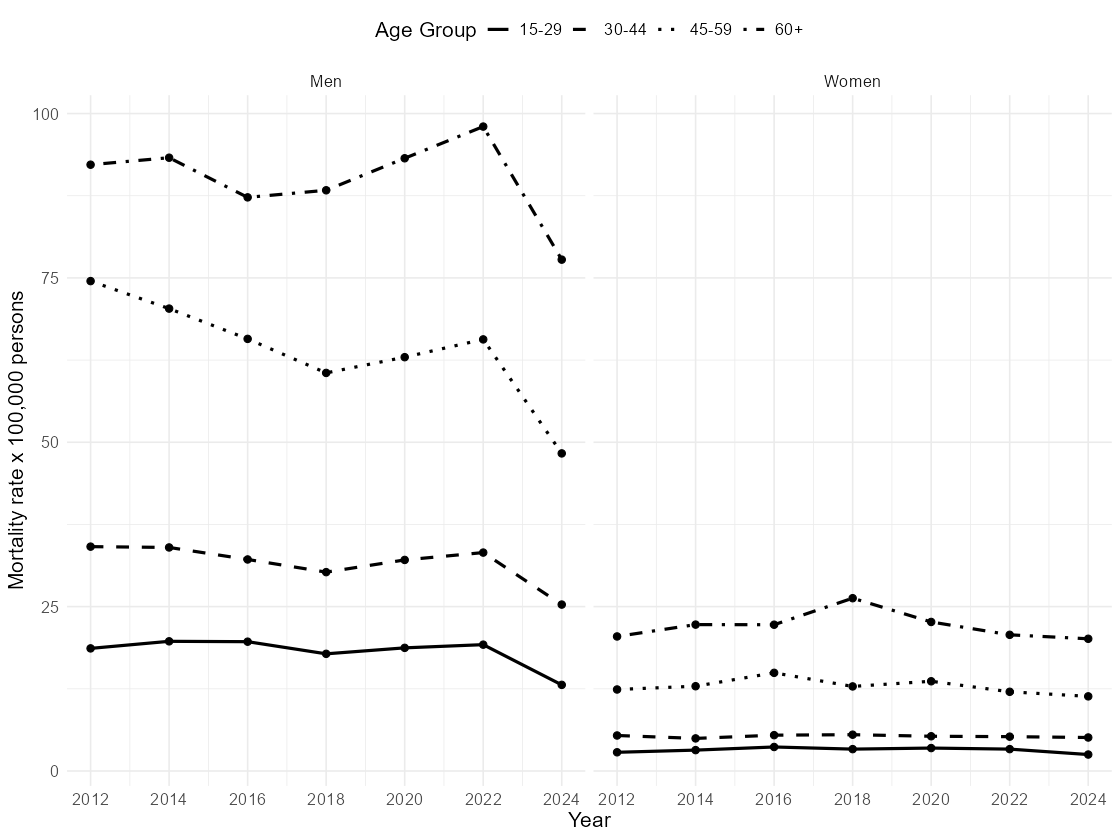

Warning messages:
1: Removed 32 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 77 rows containing missing values or values outside the scale range (`geom_point()`). 


In [74]:
#| label: mort-trends-age-sex-chile19-fig3
#| results: "hold"

# 2026-06-02: stop dividing deaths by sex by the total population
spw_by_sex <- dplyr::bind_rows(
  spw_male |> dplyr::mutate(gender = "Hombre"),
  spw_fem  |> dplyr::mutate(gender = "Mujer")
) |> dplyr::select(year, age_group, gender, tot, spw) |> 
  dplyr::filter(year %% 2==0, year>=2012)


mortality_results |> 
  dplyr::filter(year %% 2==0, year>=2012) |> 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group) # Se eliminÃ³ .groups
  ) %>% 
  # 2026-06-02: divide deaths by sex by the total population
    left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>%
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000
  ) %>% 
  ggplot(aes(x = year, y = mort_rate, linetype = factor(age_group))) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = seq(2012, 2024, 2)
  ) +
  scale_linetype_manual(
    values = c("1" = "solid", "2" = "dashed", "3" = "dotted", "4" = "dotdash"),
    labels = c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+")
  ) +
  facet_wrap(~ gender, labeller = as_labeller(c("Mujer" = "Women", "Hombre" = "Men"))) +
  labs(
    x = "Year",
    y = "Mortality rate x 100,000 persons",
    linetype = "Age Group"
  ) +
  theme_minimal() +
  theme(
    text = element_text(size = 14),
    legend.position = "top"
  )

fig3 <- mortality_results %>% 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group)
  ) %>% 
  # 2026-06-02: divide deaths by sex by the total population
  left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>%
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000,
    gender = factor(gender, levels = c("Hombre", "Mujer")),
    age_group = factor(age_group, levels = c("1", "2", "3", "4"))
  ) %>% 
  ggplot(aes(x = year, y = mort_rate, linetype = age_group)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.4, color = "black") +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 200, 400),
    limits = c(0, 600)
  ) +
  scale_linetype_manual(
    values = c("1" = "solid", "2" = "dashed", "3" = "dotted", "4" = "dotdash"),
    labels = c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+")
  ) +
  facet_wrap(
    ~ gender,
    labeller = as_labeller(c("Hombre" = "Men", "Mujer" = "Women"))
  ) +
  labs(
    x = "Year",
    y = "Mortality rate x 100,000 persons",
    linetype = "Age Group"
  ) +
  guides(
    linetype = guide_legend(
      title.position = "left",
      nrow = 1
    )
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(size = 18),
    legend.text = element_text(size = 14),
    legend.key.width = unit(1.2, "cm"),
    strip.text = element_text(size = 14),
    axis.title = element_text(size = 18),
    axis.text = element_text(size = 13),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 3.png"
  ),
  plot = fig3,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

In [88]:
mortality_results |> 
  filter(grepl("Injuries",disease)) |> 
  group_by(disease) |> 
  summarise(mean= mean(mort))

# A tibble: 3 × 2
  disease                 mean
  <chr>                  <dbl>
1 Intentional Injuries    60.6
2 Road Injuries           67.4
3 Unintentional Injuries  54.0

In [94]:
#| label: mort-trends-age-sex-chile19b-fig3-2022
#| results: "hold"

mortality_results %>% 
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE), 
    .by = c(year, gender, age_group)
  ) %>% 
  left_join(spw_by_sex, by = c("year", "age_group", "gender")) %>% 
  mutate(
    mort_rate = (mort / tot) * 100000,
    ll_mort_rate = (ll_mort / tot) * 100000,
    up_mort_rate = (up_mort / tot) * 100000,
    gender = factor(gender, levels = c("Hombre", "Mujer")),
    age_group = factor(age_group, levels = c("1", "2", "3", "4"))
  ) |> 
  dplyr::filter(year==2022) |> 
  knitr::kable("markdown", caption="Total deaths by gender and age group, 2022")

# A tibble: 8 × 11
   year gender age_group   mort ll_mort up_mort     tot    spw mort_rate ll_mort_rate up_mort_rate
  <dbl> <fct>  <fct>      <dbl>   <dbl>   <dbl>   <dbl>  <dbl>     <dbl>        <dbl>        <dbl>
1  2022 Hombre 1          404.    169.     650. 2032040 0.324      19.9          8.31        32.0 
2  2022 Mujer  1           67.6    25.0    116. 2032040 0.324       3.33         1.23         5.72
3  2022 Hombre 2          739.    367.    1099. 2192631 0.310      33.7         16.7         50.1 
4  2022 Mujer  2          114.     51.3    184. 2192631 0.310       5.22         2.34         8.41
5  2022 Hombre 3         1210.    750.    1699. 1934694 0.291      62.5         38.8         87.8 
6  2022 Mujer  3          233.    108.     379. 1934694 0.291      12.0          5.57        19.6 
7  2022 Hombre 4          511.    313.     725.  578158 0.0757     88.4         54.2        125.  
8  2022 Mujer  4          120.     45.8    208.  578158 0.0757     20.7          7.93     

In [98]:
#| label: mort-trends-age-sex-chile19b-fig3-2022-group1
#| results: "hold"

att_15_29_2022 <- mortality_results |>
  dplyr::filter(year == 2022, age_group == 1) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

den_15_29_2022 <- def |>
  dplyr::filter(year == 2022, age_group == 1) |>
  dplyr::summarise(deaths = dplyr::n())

print(paste0("Percentage of attributed mortality of total, 15-29 yrs. :", round(att_15_29_2022$att / den_15_29_2022$deaths * 100,2)))

[1] "Percentage of attributed mortality of total, 15-29 yrs. :16.05"


In [99]:
att_60_2022 <- mortality_results |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(att = sum(mort, na.rm = TRUE))

den_60_2022 <- def |>
  dplyr::filter(year == 2022, age_group == 4) |>
  dplyr::summarise(deaths = dplyr::n())

print(paste0("Percentage of attributed mortality of total, 60-64 yrs. :", 
    round(att_60_2022$att / den_60_2022$deaths * 100)
  ))

[1] "Percentage of attributed mortality of total, 60-64 yrs. :7"


#### Figure 5

Check missing categories

In [67]:
cats_106 <- c("Breast Cancer","Colon and rectum Cancer","Larynx Cancer",
  "Oral Cavity and Pharynx Cancer","Other Pharyngeal Cancer","Liver Cancer",
  "Oesophagus Cancer","Stomach Cancer","Pancreatic Cancer",
  "Intentional Injuries","Road Injuries","Unintentional Injuries",
  "Hypertensive Heart Disease","Intracerebral Haemorrhage","Ischaemic Heart Disease",
  "Ischaemic Stroke","DM2","Liver Cirrhosis","Lower Respiratory Infection",
  "Tuberculosis","Acute Pancreatitis","HIV","Epilepsy")
setdiff(unique(mortality_results$disease), cats_106)   # lo que cae en NA en Fig 4/5

[1] "Fully attributable to alcohol"

In [68]:
#| label: mort-trends-age-sex-chile17-cancer-comparison-categories
#| results: "asis"

# 2026-06-02= Many categories bad defined or twice. Check consistency
mortality_results_cat <- mortality_results %>%
  mutate(category = case_when(
    disease %in% c("Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
                   "Lip and Oral Cavity Cancer", "Liver Cancer", "Oesophagus Cancer",
                   "Other Pharyngeal Cancer", "Oral Cavity and Pharynx Cancer", 
                   # 2026-06-02= added Stomach and Pancreatic cancer
                   "Stomach Cancer", "Pancreatic Cancer") ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage", 
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection", 
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    disease == "Fully attributable to alcohol" ~ "Fully Attributable",
    TRUE ~ "Uncategorized" #This will show if a disease escapes
  ))

table(mortality_results_cat$category, mortality_results_cat$disease) |>  
  knitr::kable("markdown", caption = "Categories and groupings")



Table: Categories and groupings

|                   | Acute Pancreatitis| Breast Cancer| Colon and rectum Cancer| DM2| Epilepsy| Fully attributable to alcohol| HIV| Hypertensive Heart Disease| Intentional Injuries| Intracerebral Haemorrhage| Ischaemic Heart Disease| Ischaemic Stroke| Larynx Cancer| Liver Cancer| Liver Cirrhosis| Lower Respiratory Infection| Oesophagus Cancer| Oral Cavity and Pharynx Cancer| Other Pharyngeal Cancer| Pancreatic Cancer| Road Injuries| Stomach Cancer| Tuberculosis| Unintentional Injuries|
|:------------------|------------------:|-------------:|-----------------------:|---:|--------:|-----------------------------:|---:|--------------------------:|--------------------:|-------------------------:|-----------------------:|----------------:|-------------:|------------:|---------------:|---------------------------:|-----------------:|------------------------------:|-----------------------:|-----------------:|-------------:|--------------:|------------:|------

In [75]:
mortality_results_cat

# A tibble: 1,317 × 8
    year age_group gender disease              mort ll_mort up_mort category    
   <int>     <dbl> <chr>  <chr>               <dbl>   <dbl>   <dbl> <chr>       
 1  2012         1 Hombre Acute Pancreatitis  0.289  0.193    0.393 Other Causes
 2  2012         1 Mujer  Acute Pancreatitis  0.546  0.114    0.994 Other Causes
 3  2012         2 Hombre Acute Pancreatitis  5.90   4.04     7.95  Other Causes
 4  2012         2 Mujer  Acute Pancreatitis  1.93   0.486    3.43  Other Causes
 5  2012         3 Hombre Acute Pancreatitis 15.1   10.1     20.4   Other Causes
 6  2012         3 Mujer  Acute Pancreatitis  1.08   0.240    2.03  Other Causes
 7  2012         4 Hombre Acute Pancreatitis  2.59   1.67     3.60  Other Causes
 8  2012         4 Mujer  Acute Pancreatitis  1.65   0.336    3.26  Other Causes
 9  2014         1 Hombre Acute Pancreatitis  2.29   1.52     3.09  Other Causes
10  2014         1 Mujer  Acute Pancreatitis  0.814  0.0816   1.57  Other Causes
# ℹ 1,

Warning messages:
1: No shared levels found between `names(values)` of the manual scale and the data's colour values. 
2: Removed 68 rows containing missing values or values outside the scale range (`geom_line()`). 
3: Removed 68 rows containing missing values or values outside the scale range (`geom_point()`). 


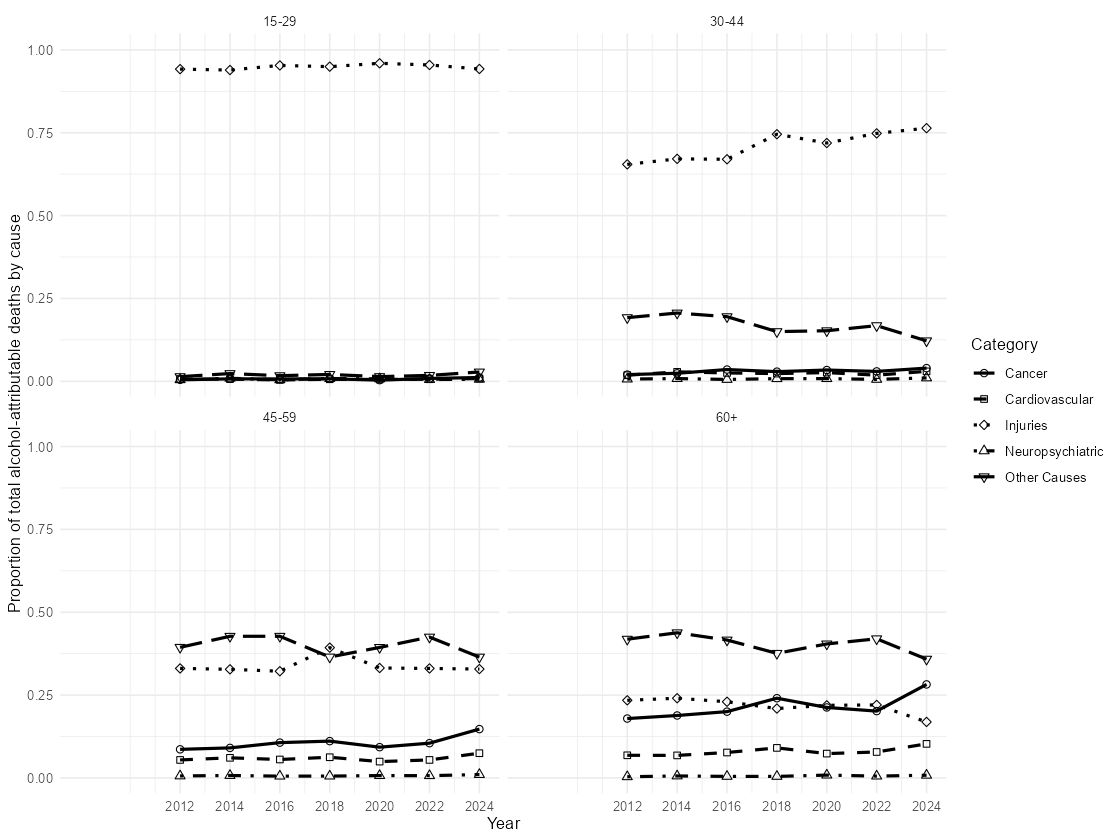

Warning messages:
1: Removed 68 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 68 rows containing missing values or values outside the scale range (`geom_point()`). 


In [76]:
#| label: mort-trends-age-sex-chile20-fig5
#| results: "hold"

mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category, col = category)) +  # Map shape to category
  geom_line(size = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = c(2012, 2014, 2016, 2018, 2020, 2022, 2024),
    labels = c(2012, 2014, 2016, 2018, 2020, 2022, 2024)
  ) +
  scale_color_manual(
    values = c(
      "Cancer" = "black", 
      "Cardiovascular" = "darkgray", 
      "Injuries" = "gray", 
      "Neuropsychiatric" = "lightgray", 
      "Other Causes" = "dimgray"
    )
  ) +
  scale_shape_manual(
    values = c(
      "Cancer" = 21,  # Circle
      "Cardiovascular" = 22,  # Square
      "Injuries" = 23,  # Diamond
      "Neuropsychiatric" = 24,  # Triangle-up
      "Other Causes" = 25  # Triangle-down
    )
  ) +
  scale_linetype_manual(
    values = c(
      "Cancer" = "solid", 
      "Cardiovascular" = "dashed", 
      "Injuries" = "dotted", 
      "Neuropsychiatric" = "dotdash", 
      "Other Causes" = "longdash"
    )
  ) +
  facet_wrap(~ age_group, labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"  # Add shape legend title
  ) +
  theme_minimal()

fig4 <- mortality_results_cat %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.2, 0.4, 0.6, 0.8),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 5.png"
  ),
  plot = fig4,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

[1] "Without pancreatic and stomach cancer, men"


Warning messages:
1: Removed 68 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 68 rows containing missing values or values outside the scale range (`geom_point()`). 


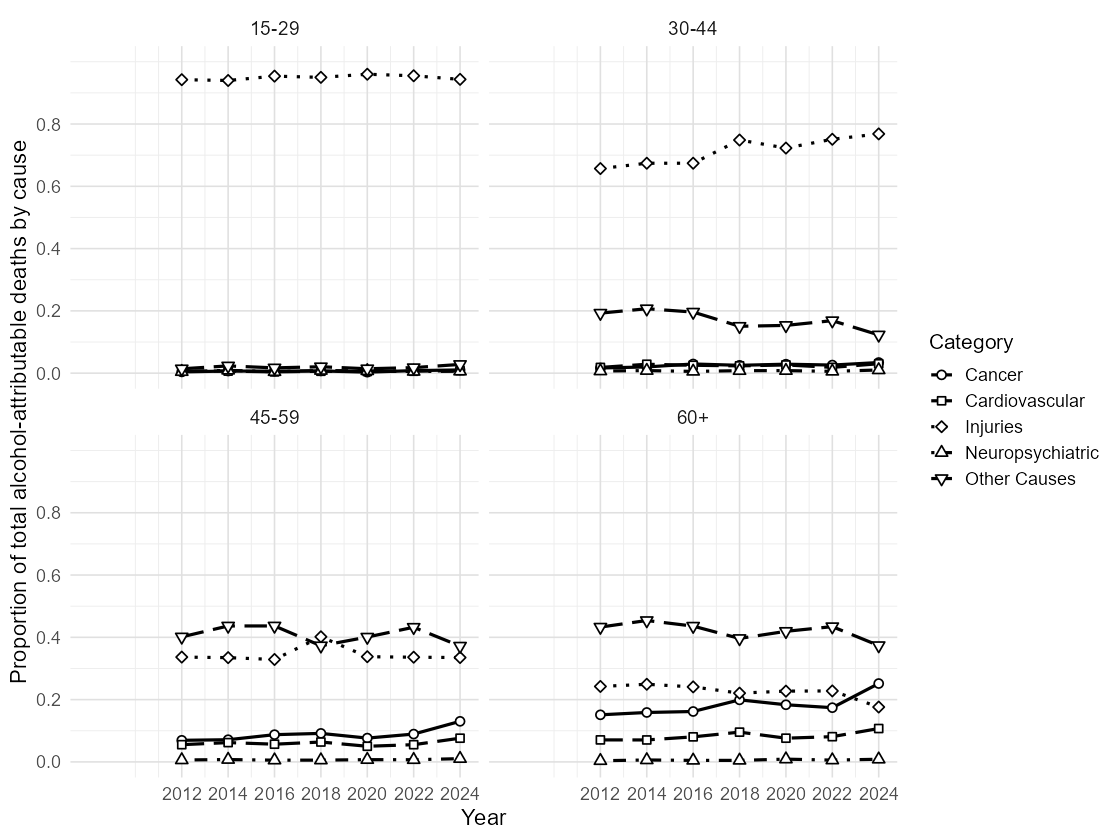

Warning messages:
1: Removed 68 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 68 rows containing missing values or values outside the scale range (`geom_point()`). 


In [77]:
#| label: mort-trends-age-sex-chile20b-fig5
#| results: "hold"

print("Without pancreatic and stomach cancer, men")

mortality_results_cat_not_stomach_pancreas_cancer <- mortality_results %>%
  dplyr::filter(!disease %in% c("Stomach Cancer", "Pancreatic Cancer")) %>%   # <- scope IARC
  dplyr::mutate(category = dplyr::case_when(
    disease %in% c(
      "Breast Cancer", "Colon and rectum Cancer", "Larynx Cancer",
      "Oral Cavity and Pharynx Cancer", "Other Pharyngeal Cancer",
      "Liver Cancer", "Oesophagus Cancer"
      # Stomach/Pancreatic ya quedaron fuera por el filter de arriba
    ) ~ "Cancer",
    disease %in% c("Intentional Injuries", "Road Injuries", "Unintentional Injuries") ~ "Injuries",
    disease %in% c("Hypertensive Heart Disease", "Intracerebral Haemorrhage",
                   "Ischaemic Heart Disease", "Ischaemic Stroke") ~ "Cardiovascular",
    disease %in% c("DM2", "Liver Cirrhosis", "Lower Respiratory Infection",
                   "Tuberculosis", "Acute Pancreatitis", "HIV") ~ "Other Causes",
    disease == "Epilepsy" ~ "Neuropsychiatric",
    TRUE ~ "Uncategorized"   # red de seguridad
  ))

 mortality_results_cat_not_stomach_pancreas_cancer %>%
  filter(gender == "Hombre") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.2, 0.4, 0.6, 0.8),
    limits = c(0, 1)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 5_not_panc_stomach.png"
  ),
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

#### Figure 4

Warning messages:
1: Removed 61 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 61 rows containing missing values or values outside the scale range (`geom_point()`). 


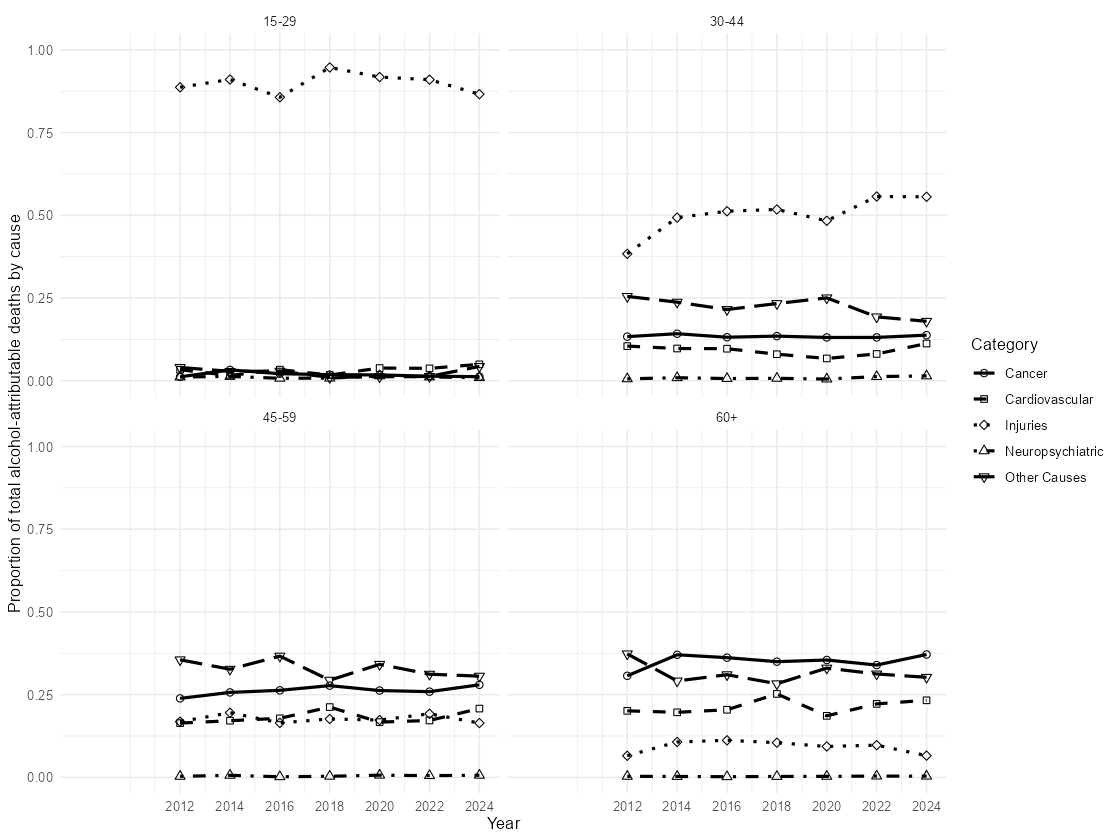

Warning messages:
1: Removed 61 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 62 rows containing missing values or values outside the scale range (`geom_point()`). 


In [79]:
#| label: mort-trends-age-sex-chile21-fig
#| results: "hold"

mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(size = 1, color = "black") +
  geom_point(size = 2, color = "black") +
  scale_x_continuous(
    breaks = c(2012, 2014, 2016, 2018, 2020, 2022, 2024),
    labels = c(2012, 2014, 2016, 2018, 2020, 2022, 2024)
  ) +
  scale_shape_manual(
    values = c(
      "Cancer" = 21,
      "Cardiovascular" = 22,
      "Injuries" = 23,
      "Neuropsychiatric" = 24,
      "Other Causes" = 25
    )
  ) +
  scale_linetype_manual(
    values = c(
      "Cancer" = "solid",
      "Cardiovascular" = "dashed",
      "Injuries" = "dotted",
      "Neuropsychiatric" = "dotdash",
      "Other Causes" = "longdash"
    )
  ) +
  facet_wrap(~ age_group, labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal()

fig5 <- mortality_results_cat %>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75),
    limits = c(0, 0.93)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 4.png"
  ),
  plot = fig5,
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)

[1] "Without pancreatic and stomach cancer, women"


Warning messages:
1: Removed 61 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 62 rows containing missing values or values outside the scale range (`geom_point()`). 


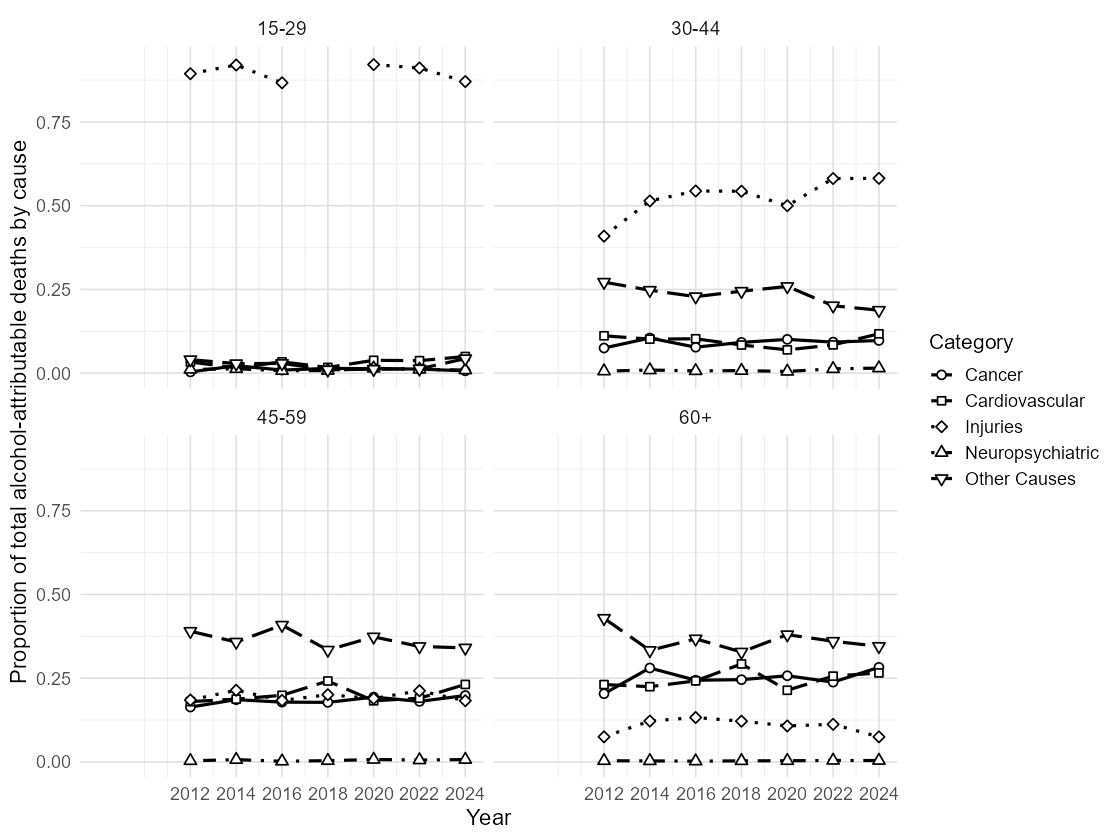

Warning messages:
1: Removed 61 rows containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 62 rows containing missing values or values outside the scale range (`geom_point()`). 


In [80]:
#| label: mort-trends-age-sex-chile21b-fig-fitlered
#| results: "hold"

print("Without pancreatic and stomach cancer, women")

mortality_results_cat_not_stomach_pancreas_cancer%>%
  filter(gender == "Mujer") %>%
  group_by(year, age_group, category) %>%
  summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  group_by(age_group, year) %>%
  mutate(prop_mort = mort / sum(mort, na.rm = TRUE)) %>%
  ungroup() %>%
  ggplot(aes(x = year, y = prop_mort, linetype = category, shape = category)) +
  geom_line(linewidth = 1, color = "black") +
  geom_point(size = 2.3, color = "black", fill = "white", stroke = 0.8) +
  scale_x_continuous(breaks = seq(2012, 2024, 2)) +
  scale_y_continuous(
    breaks = c(0, 0.25, 0.50, 0.75),
    limits = c(0, 0.93)
  ) +
  scale_shape_manual(values = c(
    "Cancer" = 21,
    "Cardiovascular" = 22,
    "Injuries" = 23,
    "Neuropsychiatric" = 24,
    "Other Causes" = 25
  )) +
  scale_linetype_manual(values = c(
    "Cancer" = "solid",
    "Cardiovascular" = "longdash",
    "Injuries" = "dotted",
    "Neuropsychiatric" = "dotdash",
    "Other Causes" = "longdash"
  )) +
  facet_wrap(
    ~ age_group,
    labeller = as_labeller(c("1" = "15-29", "2" = "30-44", "3" = "45-59", "4" = "60+"))
  ) +
  labs(
    x = "Year",
    y = "Proportion of total alcohol-attributable deaths by cause",
    linetype = "Category",
    shape = "Category"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 12),
    strip.text = element_text(size = 13),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 12),
    panel.grid.major = element_line(color = "grey88", linewidth = 0.5),
    panel.grid.minor = element_line(color = "grey93", linewidth = 0.3)
  )

ggsave(
  filename = file.path(
  gsub("__andres_control","",getwd()),
  "__andres_control",
  "Figure 4_not_pancreas_stomach.png"
  ),
  width = 9,
  height = 7,
  units = "in",
  dpi = 300,
  bg = "white"
)


#### Tables

In [83]:
mortality_results

# A tibble: 1,317 × 7
    year age_group gender disease              mort ll_mort up_mort
   <int>     <dbl> <chr>  <chr>               <dbl>   <dbl>   <dbl>
 1  2012         1 Hombre Acute Pancreatitis  0.289  0.193    0.393
 2  2012         1 Mujer  Acute Pancreatitis  0.546  0.114    0.994
 3  2012         2 Hombre Acute Pancreatitis  5.90   4.04     7.95 
 4  2012         2 Mujer  Acute Pancreatitis  1.93   0.486    3.43 
 5  2012         3 Hombre Acute Pancreatitis 15.1   10.1     20.4  
 6  2012         3 Mujer  Acute Pancreatitis  1.08   0.240    2.03 
 7  2012         4 Hombre Acute Pancreatitis  2.59   1.67     3.60 
 8  2012         4 Mujer  Acute Pancreatitis  1.65   0.336    3.26 
 9  2014         1 Hombre Acute Pancreatitis  2.29   1.52     3.09 
10  2014         1 Mujer  Acute Pancreatitis  0.814  0.0816   1.57 
# ℹ 1,307 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
#| label: mort-trends-age-sex-chile22-tab1-women
#| results: "hold"

cols <- as.vector(rbind(paste0("mort_", "20", c(12,14,16,18,20,22,24)),
                        paste0("ci_",   "20", c(12,14,16,18,20,22,24))))
mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  # Filter for "Mujer"
  filter(gender == "Mujer") |> 
  # Group by year and disease (exclude age_group)
  group_by(year, disease) |> 
  # Summarize values across age groups
  summarise(
    mort = sum(round(mort,0), na.rm = TRUE),
    ci = paste0("[", sum(round(ll_mort,0), na.rm = TRUE), "-", sum(round(up_mort,0), na.rm = TRUE), "]"),
    .groups = "drop"
  ) |> 
  # Pivot years into columns
  pivot_wider(
    names_from = year,
    values_from = c(mort, ci)
  )  |> 
  dplyr::select("disease", all_of(cols)) |> 
  knitr::kable("markdown", caption= "Table, women")



Table: Table, women

|disease                        | mort_2012|ci_2012  | mort_2014|ci_2014   | mort_2016|ci_2016   | mort_2018|ci_2018  | mort_2020|ci_2020   | mort_2022|ci_2022  | mort_2024|ci_2024  |
|:------------------------------|---------:|:--------|---------:|:---------|---------:|:---------|---------:|:--------|---------:|:---------|---------:|:--------|---------:|:--------|
|Acute Pancreatitis             |         6|[0-9]    |         6|[0-11]    |         9|[2-15]    |         8|[2-13]   |         6|[0-11]    |         7|[2-13]   |         7|[2-12]   |
|Breast Cancer                  |        13|[11-16]  |        21|[18-25]   |        17|[13-20]   |        16|[13-20]  |        24|[19-28]   |        20|[16-25]  |        20|[16-24]  |
|Colon and rectum Cancer        |         7|[-7-23]  |        12|[-6-32]   |        10|[-11-33]  |        12|[-17-44] |        16|[-9-46]   |        15|[-10-45] |        15|[-12-46] |
|DM2                            |        -9|[-18-1]  |   

In [ ]:
#| label: mort-trends-age-sex-chile23-tab2-men
#| results: "hold"

 mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  # Filter for "Mujer"
  filter(gender == "Hombre") %>% 
  # Group by year and disease (exclude age_group)
  group_by(year, disease) |> 
  # Summarize values across age groups
  summarise(
    mort = sum(round(mort,0), na.rm = TRUE),
    ci = paste0("[", sum(round(ll_mort,0), na.rm = TRUE), "-", sum(round(up_mort,0), na.rm = TRUE), "]"),
    .groups = "drop"
  ) |> 
  # Pivot years into columns
  pivot_wider(
    names_from = year,
    values_from = c(mort, ci)
  ) |>  
   dplyr::select("disease", all_of(cols)) |>
   knitr::kable("markdown", caption= "Table, men")



Table: Table, men

|disease                        | mort_2012|ci_2012   | mort_2014|ci_2014   | mort_2016|ci_2016   | mort_2018|ci_2018   | mort_2020|ci_2020   | mort_2022|ci_2022   | mort_2024|ci_2024   |
|:------------------------------|---------:|:---------|---------:|:---------|---------:|:---------|---------:|:---------|---------:|:---------|---------:|:---------|---------:|:---------|
|Acute Pancreatitis             |        24|[16-32]   |        33|[24-45]   |        26|[17-34]   |        27|[18-35]   |        36|[24-49]   |        31|[20-41]   |        23|[16-31]   |
|Colon and rectum Cancer        |        61|[50-71]   |        78|[65-90]   |        92|[77-107]  |       102|[86-117]  |       107|[88-126]  |       128|[110-147] |       147|[125-169] |
|DM2                            |        14|[-2-35]   |        11|[-1-28]   |        13|[-2-35]   |        12|[-2-28]   |        13|[-2-33]   |        18|[-2-41]   |        16|[-2-39]   |
|Epilepsy                       |      

In [98]:
#| label: mort-trends-age-sex-chile24
#| results: "hold"

# 1. Total attributable deaths by year 
# Suma mort sobre todas las enfermedades, grupos de edad y sexo
# Nota: IHD/IS/DM2 pueden ser negativos. se incluyen (no clipear)

attr_by_year <- mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  )
# 2. Total observed deaths by year (de def, only >= 15 anios) 
total_by_year <- def |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group)) |>          # age >= 15 ya filtrado en chile11
  dplyr::group_by(year) |>
  dplyr::summarise(total_deaths = dplyr::n(), .groups = "drop")

total_by_year_sex <- def |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, gender, name = "total_deaths")
# 3. Burden (%) 
burden <- attr_by_year |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_m <-  mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::filter(gender =="Hombre") |> 
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |> 
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_f <-  mortality_results |> 
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths       = sum(mort,     na.rm = TRUE),
    attr_deaths_ll    = sum(ll_mort,  na.rm = TRUE),
    attr_deaths_ul    = sum(up_mort,  na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::filter(gender =="Mujer") |> 
  dplyr::left_join(total_by_year_sex, by = c("year", "gender")) |> 
  dplyr::mutate(
    burden_pct    = attr_deaths    / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
# 4. Rate of decline 2008 
b2012 <- burden$burden_pct[burden$year == 2012]
b2024 <- burden$burden_pct[burden$year == 2024]
print(cat(sprintf("2008: %.2f%%\n2022: %.2f%%\nChange: %.1f%%\n",
            b2012, b2024, (b2024 - b2012) / b2012 * 100)))

2008: 11.35%
2022: 9.02%
Change: -20.6%
NULL


In [96]:
#| label: mort-trends-age-sex-chile25
#| results: "hold"

burden |> knitr::kable("markdown", caption= "Burden by year") |>  print()
burden_m|> knitr::kable("markdown", caption= "Burden by year, Male population") |>  print()
burden_f|> knitr::kable("markdown", caption= "Burden by year, Female population") |>  print()



Table: Burden by year

| year| attr_deaths| attr_deaths_ll| attr_deaths_ul| total_deaths| burden_pct| burden_pct_ll| burden_pct_ul|
|----:|-----------:|--------------:|--------------:|------------:|----------:|-------------:|-------------:|
| 2012|    3002.886|       1631.144|       4457.445|        26446|   11.35478|      6.167828|      16.85489|
| 2014|    3075.008|       1640.631|       4572.437|        27175|   11.31558|      6.037279|      16.82589|
| 2016|    3095.024|       1587.884|       4668.359|        27350|   11.31636|      5.805790|      17.06895|
| 2018|    3024.431|       1550.498|       4523.718|        27221|   11.11065|      5.695962|      16.61849|
| 2020|    3250.292|       1790.143|       4748.668|        32198|   10.09470|      5.559795|      14.74833|
| 2022|    3398.495|       1828.988|       5059.191|        32240|   10.54124|      5.673041|      15.69228|
| 2024|    2693.441|       1360.530|       4175.164|        29866|    9.01842|      4.555448|      13.9

In [100]:
#| label: mort-trends-age-sex-chile26-major-results
#| results: "hold"

#Helpers
fmt_pct <- function(x, digits = 2) {
  paste0(formatC(x, format = "f", digits = digits), "%")
}
fmt_change <- function(x) {
  paste0(ifelse(x < 0, "\u2212", ""), formatC(abs(x), format = "f", digits = 1), "%")
}
fmt_ci <- function(x, lo, hi) {
  sprintf("%.2f%% (95%% CI: %.2f\u2013%.2f%%)", x, lo, hi)
}

#:#:#:#:#:#:#:#:
total_by_year <- def |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group)) |>
  dplyr::count(year, name = "total_deaths")
burden <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year) |>
  dplyr::summarise(
    attr_deaths    = sum(mort, na.rm = TRUE),
    attr_deaths_ll = sum(ll_mort, na.rm = TRUE),
    attr_deaths_ul = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
burden_by_sex <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    attr_deaths    = sum(mort, na.rm = TRUE),
    attr_deaths_ll = sum(ll_mort, na.rm = TRUE),
    attr_deaths_ul = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(total_by_year, by = "year") |>
  dplyr::mutate(
    burden_pct    = attr_deaths / total_deaths * 100,
    burden_pct_ll = attr_deaths_ll / total_deaths * 100,
    burden_pct_ul = attr_deaths_ul / total_deaths * 100
  )
b2012 <- burden |>
  dplyr::filter(year == 2012) |>
  dplyr::slice(1)
b2024 <- burden |>
  dplyr::filter(year == 2024) |>
  dplyr::slice(1)
decline_2012_2024 <-
  (b2024$burden_pct - b2012$burden_pct) / b2012$burden_pct * 100
male_2012 <- burden_by_sex |>
  dplyr::filter(year == 2012, gender == "Hombre") |>
  dplyr::pull(burden_pct)
female_2012 <- burden_by_sex |>
  dplyr::filter(year == 2012, gender == "Mujer") |>
  dplyr::pull(burden_pct)
ihd_male <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(disease == "Ischaemic Heart Disease", gender == "Hombre") |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll   = sum(ll_mort, na.rm = TRUE),
    ul   = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  )
ihd_male_text <- if (
  all(ihd_male$mort > 0, na.rm = TRUE) &&
    any(ihd_male$ll < 0 & ihd_male$ul > 0, na.rm = TRUE)
) {
  "Positive, very wide CI (straddles null)"
} else {
  "Review IHD male estimates"
}
hhd <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(disease == "Hypertensive Heart Disease") |>
  dplyr::group_by(year) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::arrange(year)
hhd_text <- if (
  all(hhd$mort > 0, na.rm = TRUE) &&
    dplyr::last(hhd$mort) > dplyr::first(hhd$mort)
) {
  "Positive and growing"
} else {
  "Review HHD estimates"
}
dominant_cause <- mortality_results |>
  dplyr::group_by(disease) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE), .groups = "drop") |>
  dplyr::slice_max(order_by = mort, n = 1, with_ties = FALSE) |>
  dplyr::pull(disease)
lc_text <- if (dominant_cause == "Liver Cirrhosis") {
  "Yes (unchanged)"
} else {
  paste("No:", dominant_cause)
}
young_male_injuries <- mortality_results |>
  dplyr::filter(
    gender == "Hombre",
    age_group == 1,
    stringr::str_detect(disease, stringr::regex("injur|road", ignore_case = TRUE))
  ) |>
  dplyr::summarise(mort = sum(mort, na.rm = TRUE)) |>
  dplyr::pull(mort)

injury_text <- if (young_male_injuries > 0) {
  "Yes (unchanged)"
} else {
  "Review injuries in young men"
}
comparison_table <- tibble::tibble(
  Aspect = c(
    "Total burden 2012",
    "Total burden 2022",
    "Rate of decline 2012\u20132024",
    "Males burden 2012",
    "Females burden 2012",
    "IHD males",
    "HHD",
    "Liver cirrhosis dominance",
    "Injuries in young men"
  ),
  `Published paper` = c(
    "14.6%",
    "9.6%",
    "\u221234%",
    "\u2014",
    "\u2014",
    "Major positive",
    "Not highlighted",
    "Yes",
    "Yes"
  ),
  `Recent analysis` = c(
    fmt_ci(b2012$burden_pct, b2012$burden_pct_ll, b2012$burden_pct_ul),
    fmt_ci(b2024$burden_pct, b2024$burden_pct_ll, b2024$burden_pct_ul),
    fmt_change(decline_2012_2024),
    fmt_pct(male_2012),
    fmt_pct(female_2012),
    ihd_male_text,
    hhd_text,
    lc_text,
    injury_text
  )
)
comparison_table |>
  knitr::kable("markdown")



|Aspect                    |Published paper |Recent analysis                         |
|:-------------------------|:---------------|:---------------------------------------|
|Total burden 2012         |14.6%           |11.35% (95% CI: 6.17–16.85%)            |
|Total burden 2022         |9.6%            |9.02% (95% CI: 4.56–13.98%)             |
|Rate of decline 2012–2024 |−34%            |−20.6%                                  |
|Males burden 2012         |—               |9.65%                                   |
|Females burden 2012       |—               |1.70%                                   |
|IHD males                 |Major positive  |Positive, very wide CI (straddles null) |
|HHD                       |Not highlighted |Positive and growing                    |
|Liver cirrhosis dominance |Yes             |Yes (unchanged)                         |
|Injuries in young men     |Yes             |Yes (unchanged)                         |

In [101]:
#| label: mort-trends-age-sex-chile27-major-results2
#| results: "hold"

fmt_pct <- function(x, digits = 1) {
  paste0(formatC(x, format = "f", digits = digits), "%")
}
fmt_pct_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f%% (95%% CI: %.", digits, "f\u{2013}%.", digits, "f%%)"),
    x, lo, hi
  )
}
fmt_rate_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f per 100,000 (95%% CI: %.", digits, "f\u{2013}%.", digits, "f)"),
    x, lo, hi
  )
}
fmt_change <- function(x, digits = 1) {
  paste0(
    ifelse(x < 0, "\u{2212}", ""),
    formatC(abs(x), format = "f", digits = digits),
    "%"
  )
}

def_analysis <- def |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!is.na(age_group))

deaths_total <- def_analysis |>
  dplyr::count(year, name = "n")

deaths_sex <- def_analysis |>
  dplyr::count(year, gender, name = "n")

burden_total <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_total, by = "year") |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

burden_sex <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

total_2012 <- burden_total |> dplyr::filter(year == 2012)
total_2024 <- burden_total |> dplyr::filter(year == 2024)
male_2024 <- burden_sex |> dplyr::filter(year == 2024, gender == "Hombre")
female_2024 <- burden_sex |> dplyr::filter(year == 2024, gender == "Mujer")

decline_total <- (total_2024$prop - total_2012$prop) / total_2012$prop * 100

lowest_total_rate <- std_rates |>
  dplyr::filter(gender == "Total") |>
  dplyr::slice_min(order_by = std_mort_rate, n = 1, with_ties = FALSE)

post_2012_peak_total_rate <- std_rates |>
  dplyr::filter(gender == "Total", year > 2012) |>
  dplyr::slice_max(order_by = std_mort_rate, n = 1, with_ties = FALSE)

total_rate_2024 <- std_rates |> dplyr::filter(year == 2024, gender == "Total")
male_rate_2024 <- std_rates |> dplyr::filter(year == 2024, gender == "Male")
female_rate_2024 <- std_rates |> dplyr::filter(year == 2024, gender == "Female")

extended_comparison <- tibble::tibble(
  Aspect = c(
    "Total burden 2012",
    "Total burden 2024",
    "Rate of decline 2012-2024",
    "Lowest total mortality rate",
    "Post-2012 peak total mortality rate",
    "Total mortality rate 2024",
    "Male burden 2024",
    "Female burden 2024",
    "Male mortality rate 2024",
    "Female mortality rate 2024"
  ),
  `Published paper` = c(
    "14.6% (95% CI: 10.9-18.4%)",
    "9.6% (95% CI: 7.2-12.2%)",
    "\u{2212}34%",
    "2012: 62 per 100,000",
    "2018 peak",
    "65.4 per 100,000",
    "12.4%",
    "6.4%",
    "84.4 per 100,000",
    "38.4 per 100,000"
  ),
  `Recent analysis` = c(
    fmt_pct_ci(total_2012$prop, total_2012$ll_prop, total_2012$up_prop),
    fmt_pct_ci(total_2024$prop, total_2024$ll_prop, total_2024$up_prop),
    
    fmt_change(decline_total),
    paste0(lowest_total_rate$year, ": ", fmt_rate_ci(
      lowest_total_rate$std_mort_rate,
      lowest_total_rate$ll_std_mort_rate,
      lowest_total_rate$up_std_mort_rate
    )),
    paste0(post_2012_peak_total_rate$year, ": ", fmt_rate_ci(
      post_2012_peak_total_rate$std_mort_rate,
      post_2012_peak_total_rate$ll_std_mort_rate,
      post_2012_peak_total_rate$up_std_mort_rate
    )),
    fmt_rate_ci(
      total_rate_2024$std_mort_rate,
      total_rate_2024$ll_std_mort_rate,
      total_rate_2024$up_std_mort_rate
    ),
    fmt_pct_ci(male_2024$prop, male_2024$ll_prop, male_2024$up_prop),
    fmt_pct_ci(female_2024$prop, female_2024$ll_prop, female_2024$up_prop),
    fmt_rate_ci(
      male_rate_2024$std_mort_rate,
      male_rate_2024$ll_std_mort_rate,
      male_rate_2024$up_std_mort_rate
    ),
    fmt_rate_ci(
      female_rate_2024$std_mort_rate,
      female_rate_2024$ll_std_mort_rate,
      female_rate_2024$up_std_mort_rate
    )
  )
)

extended_comparison |>
  knitr::kable("markdown")



|Aspect                              |Published paper            |Recent analysis                            |
|:-----------------------------------|:--------------------------|:------------------------------------------|
|Total burden 2012                   |14.6% (95% CI: 10.9-18.4%) |11.4% (95% CI: 6.2–16.9%)                  |
|Total burden 2024                   |9.6% (95% CI: 7.2-12.2%)   |9.0% (95% CI: 4.6–14.0%)                   |
|Rate of decline 2012-2024           |−34%                       |−20.6%                                     |
|Lowest total mortality rate         |2012: 62 per 100,000       |2023: 1.0 per 100,000 (95% CI: 1.0–1.0)    |
|Post-2012 peak total mortality rate |2018 peak                  |2014: 25.6 per 100,000 (95% CI: 13.6–38.0) |
|Total mortality rate 2024           |65.4 per 100,000           |19.2 per 100,000 (95% CI: 9.7–29.8)        |
|Male burden 2024                    |12.4%                      |11.5% (95% CI: 6.1–17.4%)                  |

In [109]:
#| label: mort-trends-age-sex-chile27b-major-results2-who-scope
#| results: "hold"
mortality_results_who_scope <- mortality_results |>
  dplyr::filter(year %% 2 ==0, year>=2012) |> 
  dplyr::filter(!disease %in% c("Stomach Cancer", "Pancreatic Cancer"))

burden_total_who_scope <- mortality_results_who_scope |>
  dplyr::group_by(year) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_total, by = "year") |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )
burden_sex_who_scope <- mortality_results_who_scope |>
  dplyr::group_by(year, gender) |>
  dplyr::summarise(
    mort = sum(mort, na.rm = TRUE),
    ll_mort = sum(ll_mort, na.rm = TRUE),
    up_mort = sum(up_mort, na.rm = TRUE),
    .groups = "drop"
  ) |>
  dplyr::left_join(deaths_sex, by = c("year", "gender")) |>
  dplyr::mutate(
    prop = mort / n * 100,
    ll_prop = ll_mort / n * 100,
    up_prop = up_mort / n * 100
  )

std_rates_who_scope <- dplyr::bind_rows(
  make_std_rate(mortality_results_who_scope, spw_tot, "Total"),
  make_std_rate(
    mortality_results_who_scope |> dplyr::filter(gender == "Hombre"),
    spw_male,
    "Hombre"
  ),
  make_std_rate(
    mortality_results_who_scope |> dplyr::filter(gender == "Mujer"),
    spw_fem,
    "Mujer"
  )
)

fmt_rate_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f (95%% CI: %.", digits, "f, %.", digits, "f)"),
    x, lo, hi
  )
}
fmt_pct_ci <- function(x, lo, hi, digits = 1) {
  sprintf(
    paste0("%.", digits, "f (95%% CI: %.", digits, "f, %.", digits, "f)"),
    x, lo, hi
  )
}

print(paste0("std. mortality rate w/o stomach & pancreatic cancer: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2024 & std_rates_who_scope$gender=="Total"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("std. mortality rate w/o stomach & pancreatic cancer, men: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2024 & std_rates_who_scope$gender=="Hombre"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("std. mortality rate w/o stomach & pancreatic cancer, women: ", 
with(std_rates_who_scope[which(std_rates_who_scope$year==2024 & std_rates_who_scope$gender=="Mujer"),], 
fmt_rate_ci(std_mort_rate, ll_std_mort_rate, up_std_mort_rate))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer: ", 
with(burden_total_who_scope[which(burden_total_who_scope$year==2024),], 
fmt_pct_ci(prop, ll_prop, up_prop))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer, men: ", 
with(burden_sex_who_scope[which(burden_sex_who_scope$year==2024 & burden_sex_who_scope$gender=="Hombre"),], 
fmt_pct_ci(prop, ll_prop, up_prop))))

print(paste0("alcohol burden w/o stomach & pancreatic cancer, women: ", 
with(burden_sex_who_scope[which(burden_sex_who_scope$year==2024 & burden_sex_who_scope$gender=="Mujer"),], 
fmt_pct_ci(prop, ll_prop, up_prop))))


[1] "std. mortality rate w/o stomach & pancreatic cancer: 18.6 (95% CI: 9.3, 28.9)"
[1] "std. mortality rate w/o stomach & pancreatic cancer, men: 31.1 (95% CI: 16.4, 47.1)"
[1] "std. mortality rate w/o stomach & pancreatic cancer, women: 6.5 (95% CI: 2.5, 11.2)"
[1] "alcohol burden w/o stomach & pancreatic cancer: 8.7 (95% CI: 4.4, 13.6)"
[1] "alcohol burden w/o stomach & pancreatic cancer, men: 11.3 (95% CI: 6.0, 17.1)"
[1] "alcohol burden w/o stomach & pancreatic cancer, women: 4.3 (95% CI: 1.6, 7.4)"


In [106]:
cats_106 <- c("Breast Cancer","Colon and rectum Cancer","Larynx Cancer",
  "Oral Cavity and Pharynx Cancer","Other Pharyngeal Cancer","Liver Cancer",
  "Oesophagus Cancer","Stomach Cancer","Pancreatic Cancer",
  "Intentional Injuries","Road Injuries","Unintentional Injuries",
  "Hypertensive Heart Disease","Intracerebral Haemorrhage","Ischaemic Heart Disease",
  "Ischaemic Stroke","DM2","Liver Cirrhosis","Lower Respiratory Infection",
  "Tuberculosis","Acute Pancreatitis","HIV","Epilepsy")
setdiff(unique(mortality_results$disease), cats_106)   # lo que cae en NA en Fig 4/5


[1] "Fully attributable to alcohol"

# Session info

In [107]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true

message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", getwd()))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

tabla_pkg <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  package,
  loadedversion,
  source
)

tabla_pkg <- tibble::rowid_to_column(tabla_pkg, var = "row_number")

names(tabla_pkg) <- c("Row number", "Package", "Version", "Source")

htmltools::browsable(
  htmltools::tags$div(
    style = "
      max-height: 420px;
      overflow: auto;
      border: 1px solid #ddd;
      font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
      font-size: 70%;
      line-height: 0.75em;
      width: 100%;
    ",
    htmltools::tags$caption(
      style = "
        caption-side: top;
        text-align: left;
        display: block;
        padding: 6px 4px;
        font-size: 120%;
        line-height: 1.2em;
      ",
      htmltools::em("R packages")
    ),
    htmltools::tags$table(
      style = "
        border-collapse: collapse;
        width: max-content;
        min-width: 100%;
        white-space: nowrap;
      ",
      htmltools::tags$thead(
        htmltools::tags$tr(
          lapply(names(tabla_pkg), function(nm) {
            htmltools::tags$th(
              style = "
                position: sticky;
                top: 0;
                z-index: 2;
                background: #f3f3f3;
                border-bottom: 1px solid #ccc;
                padding: 4px 8px;
                text-align: left;
                white-space: nowrap;
              ",
              nm
            )
          })
        )
      ),
      htmltools::tags$tbody(
        lapply(seq_len(nrow(tabla_pkg)), function(i) {
          htmltools::tags$tr(
            lapply(tabla_pkg[i, ], function(x) {
              htmltools::tags$td(
                style = "
                  border-bottom: 1px solid #eee;
                  padding: 3px 8px;
                  white-space: nowrap;
                ",
                as.character(x)
              )
            })
          )
        })
      )
    )
  )
)

R library: C:\Users\nDP\AppData\Local/R/win-library/4.4
Date: 2026-07-02 20:01:37.387542
Editor context: c:/Users/nDP/Desktop/ACC1240138_private/__andres_control
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE, env = paste0("TMPDIR=",  :
  running command '"quarto" TMPDIR=C:/Users/nDP/AppData/Local/Temp/RtmpeaJ75G/file18883781121b -V' had status 1


1,bit,4.6.0,CRAN (R 4.4.3)
2,bit64,4.6.0-1,CRAN (R 4.4.3)
3,bslib,0.10.0,CRAN (R 4.4.3)
4,cachem,1.1.0,CRAN (R 4.4.3)
5,cellranger,1.1.0,CRAN (R 4.4.3)
6,cli,3.6.5,CRAN (R 4.4.3)
7,crayon,1.5.3,CRAN (R 4.4.3)
8,crosstalk,1.2.2,CRAN (R 4.4.3)
9,data.table,1.18.2.1,CRAN (R 4.4.3)
10,DBI,1.3.0,CRAN (R 4.4.3)
11,devtools,2.5.0,CRAN (R 4.4.3)


## References

::: {#refs}
:::